# **데이터 불러오기**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Patch
import re
from scipy.stats import chi2_contingency, binomtest, fisher_exact, chisquare
from collections import Counter
from itertools import product

pd.set_option('display.max_columns', None)

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'NanumGothic'

In [3]:
# ============================================================
# 한글 폰트 설치 및 적용
# ============================================================

!apt-get -qq install -y fonts-nanum > /dev/null
!pip -q install scipy pandas matplotlib

import matplotlib.font_manager as fm
for f in fm.findSystemFonts():
    if 'Nanum' in f:
        fm.fontManager.addfont(f)
print("폰트 설치 완료 → 런타임을 한 번 다시 시작하세요.")


plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

폰트 설치 완료 → 런타임을 한 번 다시 시작하세요.


In [4]:
#파일 불러오기
df = pd.read_csv('FDA_adverse_events_final_참조표병합.csv')
df.shape

(18273, 37)

In [5]:
df['WHO_ATC'].value_counts(dropna=False)

,count
WHO_ATC,
A,9622
N,4324
M,1975
R,1562
D,641
B,94
S,55


# **R(호흡기) : 총 1562건**   

##   
*   **A. 항히스타민제(단일)  |  967건**   |  61.9%  |  세티리진(Zyrtec), 펙소페나딘(Allegra), 디펜히드라민, 레보세티리진, 로라타딘(Claritin)

*   **D. 수면유도복합제(PM류)  |  202건**  |  12.9%  |  Motrin PM(이부프로펜+디펜히드라민), Advil PM, Aleve PM, Tylenol PM, Unisom

*   **B. 진해거담제  |  124건**  |  7.9%  |  구아이페네신, 덱스트로메토르판, 멘톨

*   **C. 비충혈제거제(단일)  |  120건**  |  7.7%  |  슈도에페드린(Sudafed), 페닐레프린, 옥시메타졸린

*   **F. 흡인형 스테로이드  |  53건**  |  3.4%  |  플루티카손, 부데소니드, 크로모글리케이트, 트리암시놀론


*   **G. 소아 감기약 복합제  |  33건**  |  2.1%  |  Children's Tylenol Cold/Flu/Cough류


*   **E. 항히스타민+비충혈제거제복합감기약  |  25건**  |  1.6%  |  Allegra-D, Zyrtec-D, Claritin-D류


*   **H. 수면유도복합제(PM류)  |  38건**  |  2.4%  |  단일 진통제(아세트아미노펜·이부프로펜·아스피린 등, R분류 잔여)


---

---



`A. 항히스타민(단일)`이지만 `G. 소아 감기약 복합제`으로 분류되어 있던 의약품 대거 `A. 항히스타민(단일)`로 분류

---

---
    


`알레르기 반응을 유발하는 체내 화학 물질인 '히스타민' 작용을 차단하는 약물`   
주로 재채기, 콧물, 가려움증, 두드러기 등의 증상을 완화에 사용

*   **1세대** : 효과가 빠르지만 **뇌혈관장벽을 통과**해 졸음, 무기력증, 입 마름 등의 부작용이 흔하게 나타남
*   **2세대** : 뇌혈관장벽을 거의 통과하지 않아 1세대보다 졸음 등 **중추신경계 부작용이 적고 약효가 오래 지속**

*   **주요 효능** : 알레르기성 비염 및 결막염, 급·만성 두드러기, 아토피성 피부염, 곤충에 물렸을 때의 가려움증 치료에 널리 쓰임.   
또한 일부 성분은 멀미약이나 감기약의 콧물 억제 및 수면 유도 목적으로도 사용
*   **복용 시 주의사항**
1.   **졸음 및 집중력 저하** : 특히 1세대 복용 시, 졸음 위험이 있어 운전이나 기계 조작을 피해야 함.2세대도 개인에 따라 졸음 발생할 수 있음  

2.   **알코올 및 중추신경계 억제제 금기** : 술이나 수면제, 진정제와 함께 복용하면 **졸음과 진정 작용이 과도**해질 수 있으므로 주의해야 합니다.  

3.   **증상 발현 전 복용** : 이미 알레르기 증상이 심해진 후보다, 증상이 나타나기 시작할 때나 알레르기 유발 물질에 노출되기 전에 복용하는 것이 효과적입니다


In [6]:

C_A    = '#2563eb'   # 항히스타민(단일)
C_BASE = '#94a3b8'   # baseline (회색 — baseline 전용)
C_FEMALE = '#db2777'  # 여성 (핑크)
C_MALE   = '#0891b2'  # 남성 (하늘색)
C_G1   = '#dc2626'   # 1세대(진정성)
C_G2   = '#16a34a'   # 2세대(비진정성)

# ----------------------------------------------------------------------------
# ★ 한글 라벨 매핑 (그래프 표기용 / 원본 데이터 값은 보존)
# ----------------------------------------------------------------------------
KOR_AGE = {
    'Infant(0-2)': '영아(0-2)', 'Child(3-12)': '아동(3-12)', 'Teen(13-18)': '청소년(13-18)',
    'Adult(19-40)': '성인(19-40)', 'Middle-Aged(41-65)': '중년(41-65)',
    'Senior(66-80)': '고령(66-80)', 'Elderly(81+)': '초고령(81+)',
}
KOR_SEX = {'Female': '여성', 'Male': '남성', 'Unknown': '미상'}
KOR_DRUG = {
    'Single': '단일(1종)', '2-3 Drugs': '2-3종', '4-5 Drugs': '4-5종',
    'Polypharmacy(6+)': '다약제(6종+)', 'Unknown': '미상',
}
KOR_FLAG = {
    'Death': '사망', 'Hospitalization': '입원', 'Life-Threatening': '생명위협',
    'Disability': '장애', 'Congenital Anomaly': '선천이상',
}
# 성분 영문 → 국문 (데이터의 참조_국문성분명 활용)
KOR_ING = (df.dropna(subset=['참조_영문성분명', '참조_국문성분명'])
             .drop_duplicates('참조_영문성분명')
             .set_index('참조_영문성분명')['참조_국문성분명'].to_dict())
def kor_ing(name):
    return KOR_ING.get(name, name)

# 이상반응(reactions) 영문 → 국문 (MedDRA 기준, 영어 밑 괄호 병기용)
KOR_RX = {
    'Drug ineffective': '약효 없음', 'Off label use': '허가 외 사용',
    'Somnolence': '졸림', 'Insomnia': '불면', 'Headache': '두통',
    'Condition aggravated': '증상 악화', 'No adverse event': '이상반응 없음',
    'Fatigue': '피로', 'Drug hypersensitivity': '약물 과민반응',
    'Pruritus': '가려움', 'Dizziness': '어지럼', 'Toxicity to various agents': '다제 독성',
    'Product use in unapproved indication': '미승인 적응증 사용', 'Nausea': '오심',
    'Drug interaction': '약물 상호작용', 'Intentional overdose': '고의적 과량투여',
    'Overdose': '과량투여', 'Urticaria': '두드러기', 'Hypersensitivity': '과민반응',
    'Malaise': '권태감', 'Vomiting': '구토', 'Rash': '발진',
    'Dyspnoea': '호흡곤란', 'Diarrhoea': '설사', 'Pyrexia': '발열',
    'Abdominal pain': '복통', 'Death': '사망', 'Palpitations': '심계항진',
    'Anxiety': '불안', 'Tremor': '떨림', 'Dry mouth': '입마름',
    'Feeling abnormal': '이상 감각', 'Product quality issue': '제품 품질 문제',
    'Tachycardia': '빈맥', 'Confusional state': '착란',
}
def kor_rx(term):
    """영어(한국어) 병기. 매핑 없으면 영어 그대로."""
    k = KOR_RX.get(term)
    return f'{term}\n({k})' if k else term

# 이상반응 → 계통군(SOC 유사) 매핑 (키워드 규칙, 소문자 부분일치)
# 순서 중요: 위에서부터 먼저 매칭. 구체/특이 계통을 앞에 배치.
SOC_RULES = [
    ('과민/면역',  r'hypersensitiv|anaphyla|allerg|angioedema|drug reaction with eosinophil|pemphigus|intoleran'),
    ('피부',       r'pruritus|urticaria|rash|erythema|alopecia|dermat|\bskin\b|hyperhidros|photosensit|blister|acne|eczema|swelling face|nail'),
    ('신경/정신',  r'somnolen|insomnia|headache|dizz|migraine|tremor|seizure|convuls|paraesth|anxiety|depress|confus|hallucinat|agitat|nervous|sleep|drowsi|sedation|memory|cognit|panic|suicid|withdrawal|dyskinesia|syncope|coma|lethargy|disorient|restless|dependence|mania|consciousness|haemorrhage|neuralg|dysgeusia|dystonia|psychosis'),
    ('심혈관/혈압', r'palpitat|tachycard|hypertens|hypotens|arrhythm|cardiac|chest pain|bradycard|qt prolong|myocard|flushing|pallor|blood pressure|thrombo|embol|heart rate|torsade'),
    ('호흡기',     r'dyspnoea|asthma|cough|respirat|nasal|throat|rhinitis|rhinorrho|epistaxis|wheez|bronch|pharyng|sinus|sneez|pneumonia|oropharyng|choking'),
    ('소화기/간',  r'nausea|vomit|diarrho|abdominal|dyspep|constipat|gastr|dry mouth|hepat|liver|stomach|dysphagia|flatulen|salivary|glossitis|glossodynia|pancreatitis|\bmouth|colitis'),
    ('근골격',     r'arthralg|myalg|muscle|musculoskeletal|joint|back pain|spasm|stiffness|\bbone'),
    ('비뇨/신장',  r'kidney|renal|urin|micturition|dysuria|bladder|nephro'),
    ('안/이',      r'vision|\beye|ocular|tinnitus|\bear\b|hearing|vertigo|lacrimat|conjunctiv|visual|mydriasis'),
    ('전신/일반',  r'fatigue|malaise|feeling abnormal|pyrexia|pain\b|asthenia|chills|oedema|feeling|discomfort|weakness|\bfall|thirst|illness|condition aggravated|\bdeath|weight|temperature|swelling|hyponatra'),
    ('임신/생식',  r'pregnan|abortion|foetal|maternal|lactation|menstru'),
    ('감염',       r'infection|sepsis|influenza|viral|bacterial'),
    ('상해/중독',  r'overdose|toxicity|poisoning|contusion|injury'),
    ('약물/사용',  r'drug ineffective|off label|misuse|interaction|unapproved|extra dose|\bwrong|product use|therapeutic response|\bdose|expired|administration|no adverse event|maternal exposure|exposure|quality|abuse|self-medication|incorrect|inappropriate|drug effect|unevaluable|adverse drug reaction|product odour|product taste|product packaging|prescription|contraindicated'),
]
def soc_of(term):
    t = str(term).lower()
    for name, pat in SOC_RULES:
        if re.search(pat, t):
            return name
    return '기타/미분류'

# ----------------------------------------------------------------------------
# ★ 확정본 A~H 분류 재현 + 항히스타민(단일) 서브분할
# ----------------------------------------------------------------------------
R = df[df['WHO_ATC'] == 'R'].copy()
_c = R['참조_영문성분명'].fillna('').str.lower()
_b = R['brand_name'].fillna('').str.upper()
_analg = _c.str.contains('ibuprofen|naproxen|acetaminophen|paracetamol|aspirin|acetylsalicylic')
_ah    = _c.str.contains('cetirizine|fexofenadine|loratadine|levocetirizine|'
                         'diphenhydramine|doxylamine|chlorphen|meclizine|dimenhydrinate')
_dec   = _c.str.contains('pseudoephedrine|phenylephrine|oxymetazoline|xylometazoline')
_cough = _c.str.contains('guaifenesin|dextromethorphan|codeine|menthol')
_inh   = _c.str.contains('fluticasone|budesonide|triamcinolone|mometasone|beclomethasone|cromoglic')
_dbr   = _b.str.contains(r'-D\b')
_child = _b.str.contains('CHILDREN') & _b.str.contains('COLD|FLU|COUGH|CONGEST|SINUS')

grp = pd.Series(['H. 기타'] * len(R), index=R.index)
grp[_child] = 'G. 소아 감기약 복합제'
grp[(grp == 'H. 기타') & ((_analg & _b.str.contains(r'\bPM\b')) |
                          (_analg & _c.str.contains('diphenhydramine|doxylamine')))] = 'D. 수면유도 복합제(PM류)'
grp[(grp == 'H. 기타') & (_dbr | (_ah & _dec))] = 'E. 항히스타민+비충혈 복합감기약'
grp[(grp == 'H. 기타') & _inh]   = 'F. 흡입형 스테로이드'
grp[(grp == 'H. 기타') & _ah]    = 'A. 항히스타민제(단일성분)'
grp[(grp == 'H. 기타') & _cough] = 'B. 진해거담제'
grp[(grp == 'H. 기타') & _dec]   = 'C. 비충혈제거제(단일성분)'
R['R_그룹'] = grp

# ─── R 전체 그룹별 건수 확인 (분류 검증용) ───
print("=== R 전체 그룹별 건수 ===")
_vc = R['R_그룹'].value_counts().sort_index()
for k, v in _vc.items():
    print(f"{k:<28} {v:>5}건 ({v/len(R)*100:5.1f}%)")
print(f"{'합계':<28} {len(R):>5}건 (100.0%)")

A_mask_in_df = R.index[R['R_그룹'] == 'A. 항히스타민제(단일성분)']
A    = df.loc[A_mask_in_df].copy()             # 항히스타민(단일) (967)
REST = df.drop(index=A_mask_in_df).copy()      # baseline = 전체에서 A 제외

# 서브분할
GEN1 = ['Diphenhydramine', 'Doxylamine', 'Chlorphenamine', 'Meclizine', 'Dimenhydrinate']
A['서브'] = np.where(A['참조_영문성분명'].fillna('').str.contains('|'.join(GEN1)),
                    '1세대(진정성)', '2세대(비진정성)')

print(f"항히스타민(단일) A = {len(A)}  |  baseline(제외) = {len(REST)}")
print(A['서브'].value_counts())
print("※ 모든 수치는 FAERS '신고 경향성'이며 발생확률·인과관계가 아님(선택편향)")

# 공통 유틸: 세미콜론 다중값 토큰 카운터
def explode_counter(series):
    c = Counter()
    for v in series.dropna():
        for tok in str(v).split(';'):
            tok = tok.strip()
            if tok and tok.lower() != 'unknown' and tok != '-':
                c[tok] += 1
    return c

# 오즈비 + 95% CI (Haldane 0.5 보정)
def odds_ratio(a, b, c, d):
    a, b, c, d = a + .5, b + .5, c + .5, d + .5
    OR = (a * d) / (b * c)
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    return OR, np.exp(np.log(OR) - 1.96*se), np.exp(np.log(OR) + 1.96*se)

def cramers_v(cont):
    chi2, p, dof, _ = chi2_contingency(cont)
    n = cont.sum()
    V = np.sqrt(chi2 / (n * (min(cont.shape) - 1)))
    return chi2, p, dof, V

def v_label(V):
    return ('무시가능' if V < .1 else '약함' if V < .3 else '중간' if V < .5 else '강함')

def insight(*lines):
    """인사이트 카드 출력: 통계값의 '해석'을 서술."""
    print("\n┌─ [인사이트 카드] " + "─"*40)
    for ln in lines:
        print("│ " + ln)
    print("└" + "─"*57)

# ----------------------------------------------------------------------------
# ★ [규칙 9] 주의 블록 = 참조 라벨 컬럼에서 '이 셀의 검정·인사이트와 연결된
#   성분·항목만' 자동 발췌. 성분당 참조값은 1개(검증 완료).
# ----------------------------------------------------------------------------
CAUTION_COLS = {
    '최대용량_기간제한': '참조_최대용량_기간제한',
    '절대금기':          '참조_절대금기(do_not_use)',
    '즉시중단_신호':     '참조_즉시중단_신호(stop_use)',
    '임부_수유부_주의':  '참조_임부_수유부_주의',
    '기타주의사항':      '참조_기타주의사항',
}
_REF = A.drop_duplicates('참조_국문성분명').set_index('참조_국문성분명')

def caution_note(ingredients, fields, maxlen=100):
    """지정 성분(국문명)의 지정 주의필드 값을 참조 라벨에서 발췌 출력."""
    print("[주의] (참조 라벨 근거 — 이 셀 검정·인사이트와 연결된 항목만 발췌)")
    for ing in ingredients:
        if ing not in _REF.index:
            continue
        for f in fields:
            val = str(_REF.loc[ing, CAUTION_COLS[f]]).strip()
            if val and val.lower() != 'nan':
                print(f"  · {ing} [{f}]: {val[:maxlen]}")



=== R 전체 그룹별 건수 ===
A. 항히스타민제(단일성분)                967건 ( 61.9%)
B. 진해거담제                       124건 (  7.9%)
C. 비충혈제거제(단일성분)                120건 (  7.7%)
D. 수면유도 복합제(PM류)               202건 ( 12.9%)
E. 항히스타민+비충혈 복합감기약              25건 (  1.6%)
F. 흡입형 스테로이드                    53건 (  3.4%)
G. 소아 감기약 복합제                   33건 (  2.1%)
H. 기타                           38건 (  2.4%)
합계                            1562건 (100.0%)
항히스타민(단일) A = 967  |  baseline(제외) = 17306
서브
2세대(비진정성)    751
1세대(진정성)     216
Name: count, dtype: int64
※ 모든 수치는 FAERS '신고 경향성'이며 발생확률·인과관계가 아님(선택편향)


# **0. 항히스타민-단일 그룹 정의**

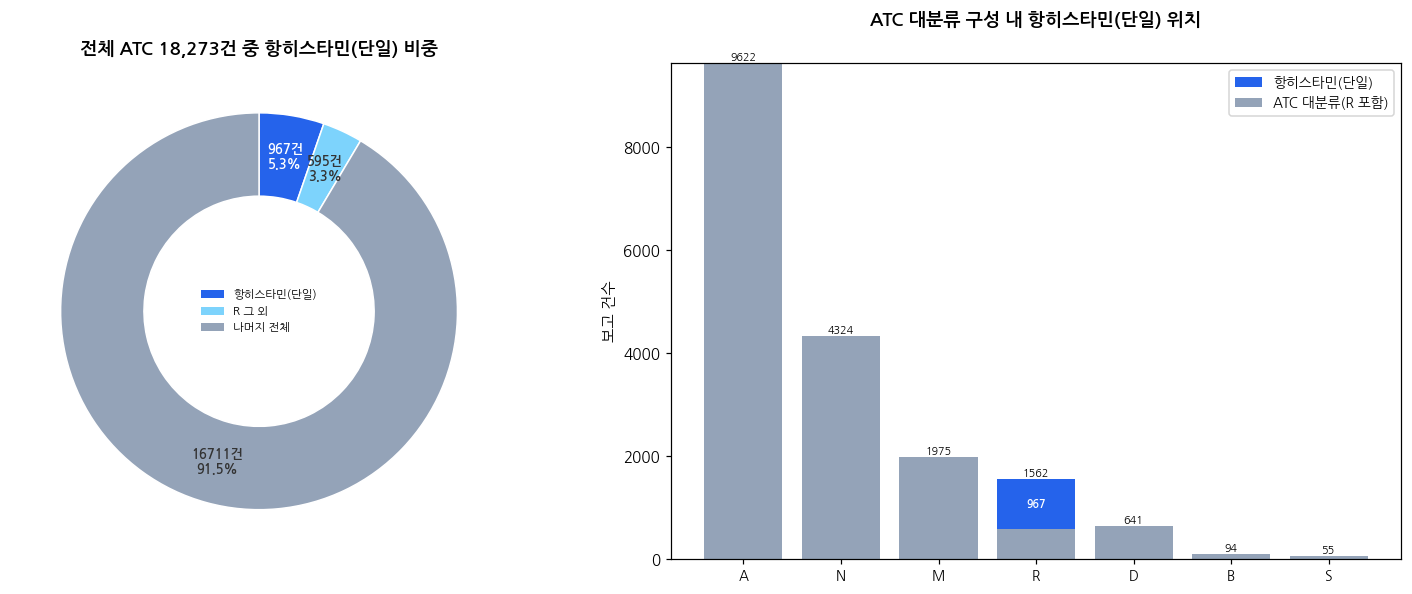

[시각화 인사이트]
  전체 ATC 18,273건 중 항히스타민(단일)은 967건 = 5.29% → 전체의 약 1/19 규모.
  R 호흡기 그룹(1562건, 8.5%) 안에서 항히스타민(단일)이 61.9%를 차지 → R의 최대 축.
  소화기(A)·진통(N)·소염(M)이 대부분을 차지하는 구조에서 호흡기(R) 소속의 소수 그룹.

[통계검정] 이항 비율 + Wilson 95% CI (전체 중 항히스타민(단일) 비율)
  p̂ = 967/18273 = 5.29%, 95% CI [4.98%, 5.63%]

[검정 인사이트]
  전체 신고의 5.3%가 항히스타민(단일)이며 CI 폭이 좁아(0.65%p) 추정이 안정적.
  이는 '전체 신고에서 항히스타민(단일)이 관찰될 신고 비중'이며, 처방·사용량이나 위험도가 아님(신고 경향).

  ※ 분모=전체 18,273건(모든 ATC). '전체 baseline' 대비 규모 비중이지 발생률·인과 아님.


In [7]:

# ============================================================================
# 0-1. 전체 ATC 코드에서 '항히스타민(단일)'이 차지하는 비율
# ============================================================================

n_A     = len(A)            # 항히스타민(단일)
n_total = len(df)           # 전체 ATC (baseline 전체)
n_R     = (df['WHO_ATC'] == 'R').sum()   # R 호흡기 전체
share   = n_A / n_total * 100

C_RGRP = '#7dd3fc'          # R그룹(호흡기) 하늘색 — 항히스타민(단일)을 품는 상위 계통

# ATC 대분류별 구성(맥락 제공: 항히스타민(단일)이 전체에서 어느 정도 규모인지)
atc_cnt = df['WHO_ATC'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (좌) 도넛: 항히스타민(단일)=파란색 / R 그 외=하늘색 / 나머지 전체=회색
#   → 하늘색(R그룹) 안에 파란색(항히스타민)이 자리한 계층 관계. 세 조각 모두 비율 표기.
seg_vals   = [n_A, n_R - n_A, n_total - n_R]
seg_colors = [C_A, C_RGRP, C_BASE]
seg_labels = ['항히스타민(단일)', 'R 그 외', '나머지 전체']
wedges, _ = axes[0].pie(
    seg_vals, radius=1.0, colors=seg_colors,
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.42, edgecolor='w'))
# 각 조각 중앙에 건수·비율 라벨 (항히스타민은 흰 글씨, 나머지는 검정)
cum = 0
for val, col in zip(seg_vals, seg_colors):
    ang = 90 - (cum + val/2) / n_total * 360   # 조각 중앙 각도
    xt, yt = 0.79 * np.cos(np.radians(ang)), 0.79 * np.sin(np.radians(ang))
    txt_col = 'white' if col == C_A else '#333333'
    axes[0].text(xt, yt, f'{val}건\n{val/n_total*100:.1f}%', ha='center', va='center',
                 fontsize=8.5, weight='bold', color=txt_col)
    cum += val
axes[0].set_title(f'전체 ATC {n_total:,}건 중 항히스타민(단일) 비중', fontsize=12, weight='bold')
# 범례를 도넛 중앙(빈 공간)에 배치
axes[0].legend(handles=[Patch(facecolor=c, label=l)
                        for c, l in zip(seg_colors, seg_labels)],
               loc='center', fontsize=7.5, frameon=False)

# (우) ATC 대분류 막대: R 막대는 회색, 그 위에 항히스타민(단일)을 파란색으로 쌓아 계층 표현
order = atc_cnt.sort_values(ascending=False).index.tolist()   # 원래 ATC 대분류 순서
base_h = [atc_cnt[k] - (n_A if k == 'R' else 0) for k in order]  # R은 항히스타민 제외분
ah_h   = [n_A if k == 'R' else 0 for k in order]                 # R에만 항히스타민 조각
x = range(len(order))
axes[1].bar(x, base_h, color=C_BASE)                          # R 포함 전 대분류=회색
axes[1].bar(x, ah_h, bottom=base_h, color=C_A)               # R 위에 항히스타민=파란색
for i, k in enumerate(order):
    total_h = atc_cnt[k]
    axes[1].text(i, total_h, f'{int(total_h)}', ha='center', va='bottom', fontsize=7)
    if k == 'R':
        axes[1].text(i, base_h[i] + ah_h[i]/2, f'{n_A}', ha='center', va='center',
                     fontsize=7, color='white', weight='bold')
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(order, fontsize=9)
axes[1].set_ylabel('보고 건수')
axes[1].set_title('ATC 대분류 구성 내 항히스타민(단일) 위치', fontsize=12, weight='bold', pad=25)
axes[1].legend(handles=[Patch(facecolor=C_A, label='항히스타민(단일)'),
                        Patch(facecolor=C_BASE, label='ATC 대분류(R 포함)')],
               loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()

print("[시각화 인사이트]")
print(f"  전체 ATC {n_total:,}건 중 항히스타민(단일)은 {n_A}건 = {share:.2f}% → 전체의 약 1/19 규모.")
print(f"  R 호흡기 그룹({n_R}건, {n_R/n_total*100:.1f}%) 안에서 항히스타민(단일)이 {n_A/n_R*100:.1f}%를 차지 → R의 최대 축.")
print(f"  소화기(A)·진통(N)·소염(M)이 대부분을 차지하는 구조에서 호흡기(R) 소속의 소수 그룹.")
print()

# [통계검정] 모비율 추정 (Wilson 95% CI)
from statsmodels.stats.proportion import proportion_confint
lo, hi = proportion_confint(n_A, n_total, alpha=0.05, method='wilson')
print("[통계검정] 이항 비율 + Wilson 95% CI (전체 중 항히스타민(단일) 비율)")
print(f"  p̂ = {n_A}/{n_total} = {share:.2f}%, 95% CI [{lo*100:.2f}%, {hi*100:.2f}%]")
print()
print("[검정 인사이트]")
print(f"  전체 신고의 {share:.1f}%가 항히스타민(단일)이며 CI 폭이 좁아({(hi-lo)*100:.2f}%p) 추정이 안정적.")
print("  이는 '전체 신고에서 항히스타민(단일)이 관찰될 신고 비중'이며, 처방·사용량이나 위험도가 아님(신고 경향).")
print()
print(f"  ※ 분모=전체 {n_total:,}건(모든 ATC). '전체 baseline' 대비 규모 비중이지 발생률·인과 아님.")

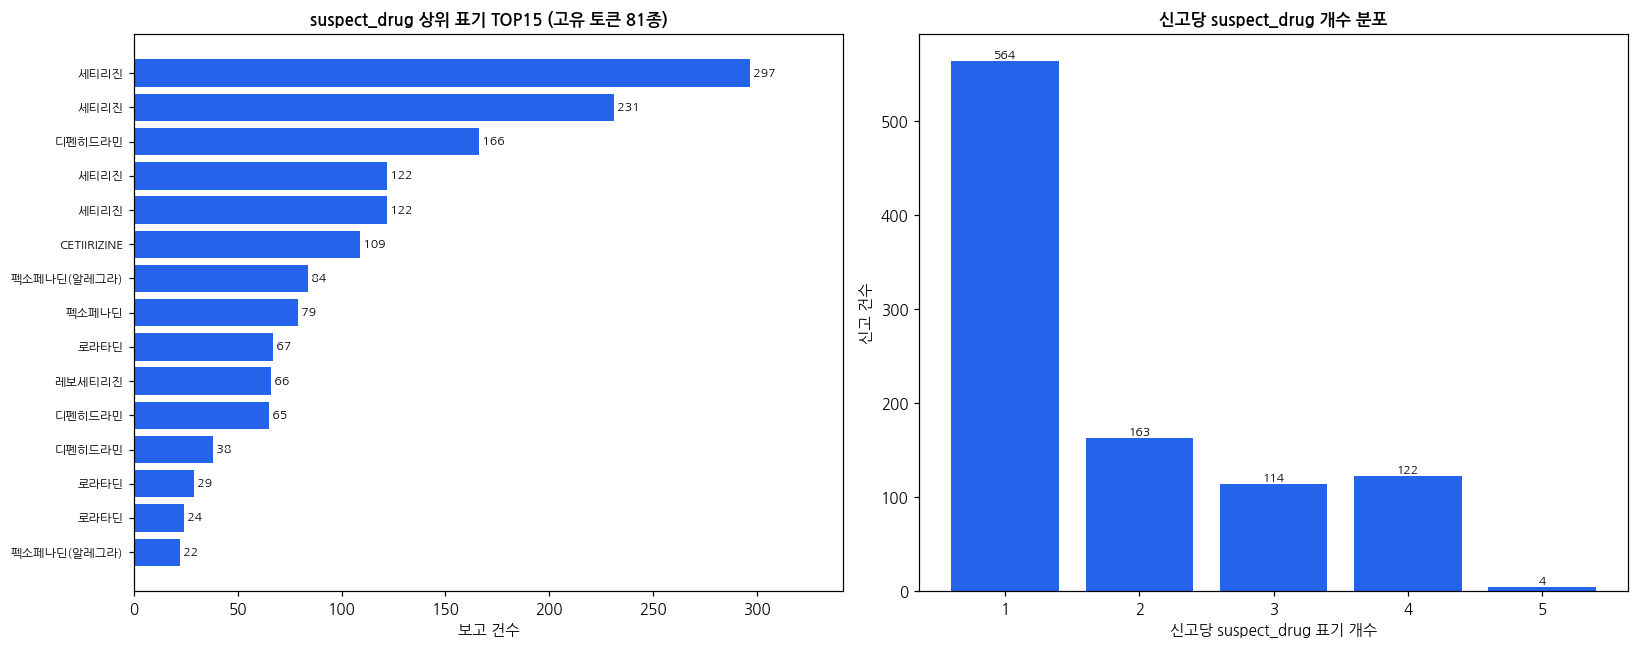

[시각화 인사이트]
  항히스타민(단일) 967건의 suspect_drug은 원문 고유 문자열 74종,
  세미콜론 분해 시 고유 표기 81종(원료명·브랜드·제형·오탈자 변형 포함).
  대부분 신고가 1~2개 표기를 가지며, 세티리진·펙소페나딘 계열 표기가 상위.

[통계검정] 적합도 카이제곱 (신고당 suspect_drug 개수 균등성)
  chi2=959.4, dof=4, p=2.27e-206
  평균 표기수=1.80, 최빈=1, 최대=5

[검정 인사이트]
  p<0.05로 균등 아님 → 소수 개수(1~2개)에 집중. 표기 변형이 많아 '고유 문자열 수'(74)는
  실제 성분 종류(9종, 0-3 참조)보다 크게 부풀려짐 → 성분 집계는 참조_영문성분명 사용 권장.

  ※ suspect_drug는 원자료 표기 그대로라 표준화 안 됨. '개수' 해석 시 표기변형 주의(신고 경향, 인과 아님).


In [8]:
# ============================================================================
# 0-2. 항히스타민(단일)이 가지고 있는 suspect_drug 개수
# ============================================================================

# suspect_drug 원문 표기 → 한국어 성분명 매핑 (표기변형 흡수용 키워드 규칙)
SUSP_KOR = [
    ('cetirizine',    '세티리진'),
    ('levocetirizine','레보세티리진'),   # cetirizine보다 먼저 매칭되게 위에 배치
    ('fexofenadine',  '펙소페나딘'),
    ('allegra',       '펙소페나딘(알레그라)'),
    ('loratadine',    '로라타딘'),
    ('claritin',      '로라타딘(클라리틴)'),
    ('diphenhydramine','디펜히드라민'),
    ('doxylamine',    '독시라민'),
    ('chlorphen',     '클로르페니라민'),
    ('meclizine',     '메클리진'),
    ('dimenhydrinate','디멘히드리네이트'),
    ('zyrtec',        '세티리진(지르텍)'),
]
def kor_susp(raw):
    """suspect_drug 원문 표기를 한국어 성분명으로. 매칭 없으면 원문 축약."""
    s = str(raw).lower()
    # levocetirizine을 cetirizine보다 먼저 잡기 위해 특이 키워드 우선 처리
    if 'levocetirizine' in s:
        return '레보세티리진'
    for kw, kor in SUSP_KOR:
        if kw in s:
            return kor
    return str(raw)[:24]   # 미매칭 원문 축약

# (1) 원문 고유 문자열 개수
n_raw_unique = A['suspect_drug'].nunique(dropna=True)
n_missing    = A['suspect_drug'].isna().sum()

# (2) 세미콜론 분해 후 고유 토큰 개수
tok_counter = Counter()
per_report_ntok = []          # 신고당 토큰 개수
for v in A['suspect_drug'].dropna():
    toks = [t.strip() for t in str(v).split(';') if t.strip()]
    per_report_ntok.append(len(toks))
    for t in toks:
        tok_counter[t] += 1
n_tok_unique = len(tok_counter)
per_report_ntok = pd.Series(per_report_ntok)

# 상위 토큰 TOP15
top_tok = pd.Series(dict(tok_counter)).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# (좌) suspect_drug 상위 토큰 (y축 한국어 성분명)
axes[0].barh(range(len(top_tok)), top_tok.values[::-1], color=C_A)
axes[0].set_yticks(range(len(top_tok)))
axes[0].set_yticklabels([kor_susp(t) for t in top_tok.index[::-1]], fontsize=8)
for i, v in enumerate(top_tok.values[::-1]):
    axes[0].text(v, i, f' {v}', va='center', fontsize=8)
axes[0].set_xlabel('보고 건수')
axes[0].set_xlim(0, top_tok.max()*1.15)
axes[0].set_title(f'suspect_drug 상위 표기 TOP15 (고유 토큰 {n_tok_unique}종)', fontsize=11, weight='bold')

# (우) 신고당 suspect_drug 개수 분포
vc = per_report_ntok.value_counts().sort_index()
axes[1].bar(vc.index.astype(str), vc.values, color=C_A)
for i, v in enumerate(vc.values):
    axes[1].text(i, v, f'{v}', ha='center', va='bottom', fontsize=8)
axes[1].set_xlabel('신고당 suspect_drug 표기 개수')
axes[1].set_ylabel('신고 건수')
axes[1].set_title('신고당 suspect_drug 개수 분포', fontsize=11, weight='bold')
plt.tight_layout(); plt.show()

print("[시각화 인사이트]")
print(f"  항히스타민(단일) {len(A)}건의 suspect_drug은 원문 고유 문자열 {n_raw_unique}종,")
print(f"  세미콜론 분해 시 고유 표기 {n_tok_unique}종(원료명·브랜드·제형·오탈자 변형 포함).")
print(f"  대부분 신고가 1~2개 표기를 가지며, 세티리진·펙소페나딘 계열 표기가 상위.")
print()

# [통계검정] 신고당 표기 개수가 균등한가 (적합도 카이제곱)
obs = vc.values
chi2, p = chisquare(obs)
print("[통계검정] 적합도 카이제곱 (신고당 suspect_drug 개수 균등성)")
print(f"  chi2={chi2:.1f}, dof={len(obs)-1}, p={p:.2e}")
print(f"  평균 표기수={per_report_ntok.mean():.2f}, 최빈={per_report_ntok.mode().iloc[0]}, 최대={per_report_ntok.max()}")
print()
print("[검정 인사이트]")
print(f"  p<0.05로 균등 아님 → 소수 개수(1~2개)에 집중. 표기 변형이 많아 '고유 문자열 수'({n_raw_unique})는")
print(f"  실제 성분 종류({A['참조_영문성분명'].nunique()}종, 0-3 참조)보다 크게 부풀려짐 → 성분 집계는 참조_영문성분명 사용 권장.")
print()
print("  ※ suspect_drug는 원자료 표기 그대로라 표준화 안 됨. '개수' 해석 시 표기변형 주의(신고 경향, 인과 아님).")


# **1. 이상반응 = 부작용**

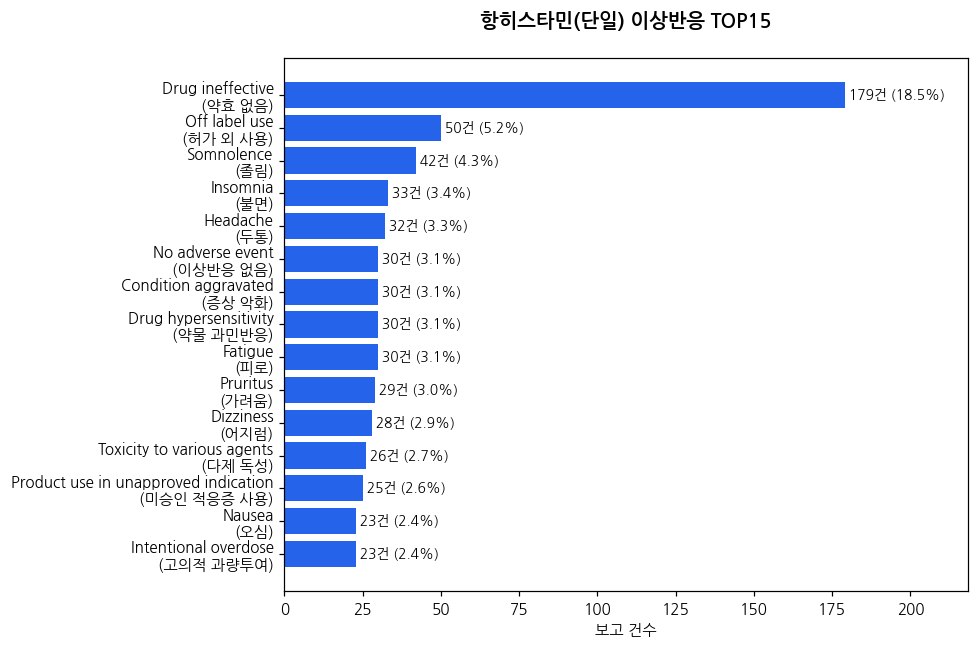

[시각화 인사이트]
  약효없음이 179건(18.5%)으로 압도적 1위 — TOP15 합계의 29%를 혼자 차지.
  이상반응이라기보다 '기대만큼 안 들었다'는 효능 불충족 신고가 최상위(OTC 알레르기약 특성).
  졸림·불면·두통 등 신경계 증상은 그 뒤이며 약효없음에 비하면 소수.

[통계검정] 적합도 카이제곱 (TOP15가 균등분포인가)
  chi2=521.2, dof=14, p=2.97e-102

[검정 인사이트]
  p<0.05로 균등분포 기각 → 반응이 소수에 극심하게 쏠림(고른 분포 아님).
  상위 3개가 TOP15의 44%를 차지 → '집중형' 신고. 효능 눈높이 이슈가 핵심.

[주의] (참조 라벨 근거 — 이 셀 검정·인사이트와 연결된 항목만 발췌)
  · 세티리진 [최대용량_기간제한]: 6세 이상: 1일 5mg 또는 10mg, 24시간 10mg 초과 금지. 65세 이상: 24시간 5mg 초과 금지
  · 펙소페나딘 [최대용량_기간제한]: 12세 이상: 1일 1회 180mg, 24시간 초과 금지
  · 로라타딘 [최대용량_기간제한]: 성인/6세 이상 1일 1회 10mg, 24시간 1정 초과 금지
  ※ 총 967건·고유 반응어 809종 중 상위 15개. 반응은 신고당 복수 기재(중복 집계), 발생률 아님.


In [9]:
# ============================================================================
# 1-1. 이상반응 TOP15
# ============================================================================

rx_A  = explode_counter(A['reactions'])
top15 = pd.Series(dict(rx_A)).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh([kor_rx(t) for t in top15.index[::-1]], top15.values[::-1], color=C_A)
for i, v in enumerate(top15.values[::-1]):
    ax.text(v, i, f' {v}건 ({v/len(A)*100:.1f}%)', va='center', fontsize=9)
ax.set_title('항히스타민(단일) 이상반응 TOP15', fontsize=13, weight='bold', pad=20)
ax.set_xlabel('보고 건수'); ax.set_xlim(0, top15.values[0] * 1.22)
plt.tight_layout(); plt.show()

print("[시각화 인사이트]")
print(f"  약효없음이 {top15.values[0]}건({top15.values[0]/len(A)*100:.1f}%)으로 압도적 1위 — "
      f"TOP15 합계의 {top15.values[0]/top15.sum()*100:.0f}%를 혼자 차지.")
print("  이상반응이라기보다 '기대만큼 안 들었다'는 효능 불충족 신고가 최상위(OTC 알레르기약 특성).")
print("  졸림·불면·두통 등 신경계 증상은 그 뒤이며 약효없음에 비하면 소수.")
print()
chi2, p = chisquare(top15.values)
top3 = top15.values[:3].sum() / top15.sum() * 100
print("[통계검정] 적합도 카이제곱 (TOP15가 균등분포인가)")
print(f"  chi2={chi2:.1f}, dof={len(top15)-1}, p={p:.2e}")
print()
print("[검정 인사이트]")
print("  p<0.05로 균등분포 기각 → 반응이 소수에 극심하게 쏠림(고른 분포 아님).")
print(f"  상위 3개가 TOP15의 {top3:.0f}%를 차지 → '집중형' 신고. 효능 눈높이 이슈가 핵심.")
print()
# [주의] 검정=약효없음 쏠림 → 효능/기간 관련 참조(최대용량·기간제한) 발췌
caution_note(['세티리진', '펙소페나딘', '로라타딘'], ['최대용량_기간제한'])
print(f"  ※ 총 {len(A)}건·고유 반응어 {len(rx_A)}종 중 상위 15개. 반응은 신고당 복수 기재(중복 집계), 발생률 아님.")


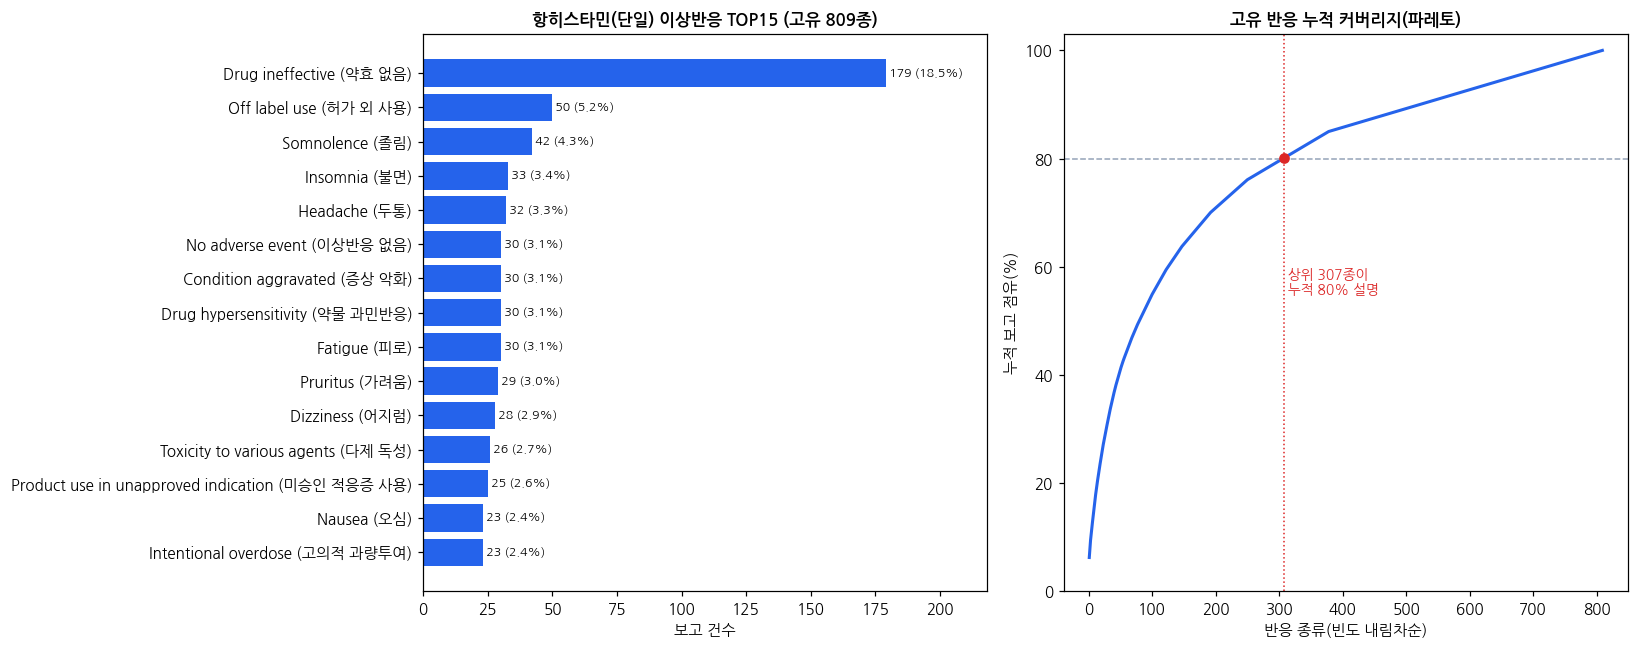

[시각화 인사이트]
  항히스타민(단일)의 고유 이상반응은 809종(총 반응 토큰 2873건, 신고당 복수 기재).
  최다는 'Drug ineffective' 179건(18.5%).
  단, 80% 커버에 상위 307종(38%)이 필요 → 반응 종류는 넓게 퍼진 롱테일.
  반면 TOP15만으로 전체 반응의 21%를 차지 → '최상위 소수 + 긴 꼬리' 구조.

[통계검정] 적합도 카이제곱(TOP15 균등성) + 집중도(Gini)
  chi2=521.2, dof=14, p=2.97e-102
  Gini 집중도=0.582 (0=완전균등 ~ 1=완전집중), 상위 307/809종이 80% 커버

[검정 인사이트]
  TOP15 p<0.05로 최상위 반응들끼리도 불균등(약효없음이 압도). Gini 0.58는 '중간 이상' 집중.
  즉 '고유 809종'의 다양성과 '최상위 소수 쏠림'이 공존 → 꼬리는 길지만 머리가 무거움.
  대시보드 TOP 반응은 상위 15종 중심으로 충분(전체의 21% 설명), 꼬리는 '기타'로 묶기 권장(신고 경향, 인과 아님).

  ※ reactions는 MedDRA 용어로 신고당 복수 기재(중복 집계). '고유 종수'는 반응어 다양성이며 발생률 아님.


In [10]:

# ============================================================================
# 1-2. 항히스타민(단일)에 나타나는 고유 부작용(이상반응) 증상
# ============================================================================

rx_counter = explode_counter(A['reactions'])
rx_series  = pd.Series(dict(rx_counter)).sort_values(ascending=False)
n_unique_rx = len(rx_series)
n_total_tok = int(rx_series.sum())
top15 = rx_series.head(15)

# 누적 커버리지(파레토)
cum = rx_series.cumsum() / n_total_tok * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# (좌) TOP15 반응
axes[0].barh([kor_rx(t).replace(chr(10), ' ') for t in top15.index[::-1]],
             top15.values[::-1], color=C_A)
for i, v in enumerate(top15.values[::-1]):
    axes[0].text(v, i, f' {v} ({v/len(A)*100:.1f}%)', va='center', fontsize=8)
axes[0].set_xlabel('보고 건수'); axes[0].set_xlim(0, top15.max()*1.22)
axes[0].set_title(f'항히스타민(단일) 이상반응 TOP15 (고유 {n_unique_rx}종)', fontsize=11, weight='bold')

# (우) 누적 커버리지 곡선(파레토)
axes[1].plot(range(1, len(cum)+1), cum.values, color=C_A, lw=2)
axes[1].axhline(80, ls='--', color=C_BASE, lw=1)
# 80% 도달 지점
idx80 = int((cum <= 80).sum()) + 1
axes[1].axvline(idx80, ls=':', color='#dc2626', lw=1)
axes[1].scatter([idx80], [cum.iloc[idx80-1]], color='#dc2626', zorder=5)
axes[1].text(idx80, 55, f' 상위 {idx80}종이\n 누적 80% 설명', fontsize=9, color='#dc2626')
axes[1].set_xlabel('반응 종류(빈도 내림차순)'); axes[1].set_ylabel('누적 보고 점유(%)')
axes[1].set_title('고유 반응 누적 커버리지(파레토)', fontsize=11, weight='bold')
axes[1].set_ylim(0, 103)
plt.tight_layout(); plt.show()

# 집중도(Gini)
def gini(vals):
    v = np.sort(np.array(vals, dtype=float)); n = len(v)
    if n == 0 or v.sum() == 0: return np.nan
    cumv = np.cumsum(v)
    return (n + 1 - 2*np.sum(cumv)/cumv[-1]) / n

g = gini(rx_series.values)
print("[시각화 인사이트]")
print(f"  항히스타민(단일)의 고유 이상반응은 {n_unique_rx}종(총 반응 토큰 {n_total_tok}건, 신고당 복수 기재).")
print(f"  최다는 '{kor_rx(top15.index[0]).splitlines()[0]}' {int(top15.iloc[0])}건({top15.iloc[0]/len(A)*100:.1f}%).")
top15_share = top15.sum()/n_total_tok*100
print(f"  단, 80% 커버에 상위 {idx80}종({idx80/n_unique_rx*100:.0f}%)이 필요 → 반응 종류는 넓게 퍼진 롱테일.")
print(f"  반면 TOP15만으로 전체 반응의 {top15_share:.0f}%를 차지 → '최상위 소수 + 긴 꼬리' 구조.")
print()

# [통계검정] TOP15 균등성 + 집중도
chi2, p = chisquare(top15.values)
print("[통계검정] 적합도 카이제곱(TOP15 균등성) + 집중도(Gini)")
print(f"  chi2={chi2:.1f}, dof={len(top15)-1}, p={p:.2e}")
print(f"  Gini 집중도={g:.3f} (0=완전균등 ~ 1=완전집중), 상위 {idx80}/{n_unique_rx}종이 80% 커버")
print()
print("[검정 인사이트]")
print(f"  TOP15 p<0.05로 최상위 반응들끼리도 불균등(약효없음이 압도). Gini {g:.2f}는 '중간 이상' 집중.")
print(f"  즉 '고유 {n_unique_rx}종'의 다양성과 '최상위 소수 쏠림'이 공존 → 꼬리는 길지만 머리가 무거움.")
print(f"  대시보드 TOP 반응은 상위 15종 중심으로 충분(전체의 {top15_share:.0f}% 설명), 꼬리는 '기타'로 묶기 권장(신고 경향, 인과 아님).")
print()
print(f"  ※ reactions는 MedDRA 용어로 신고당 복수 기재(중복 집계). '고유 종수'는 반응어 다양성이며 발생률 아님.")

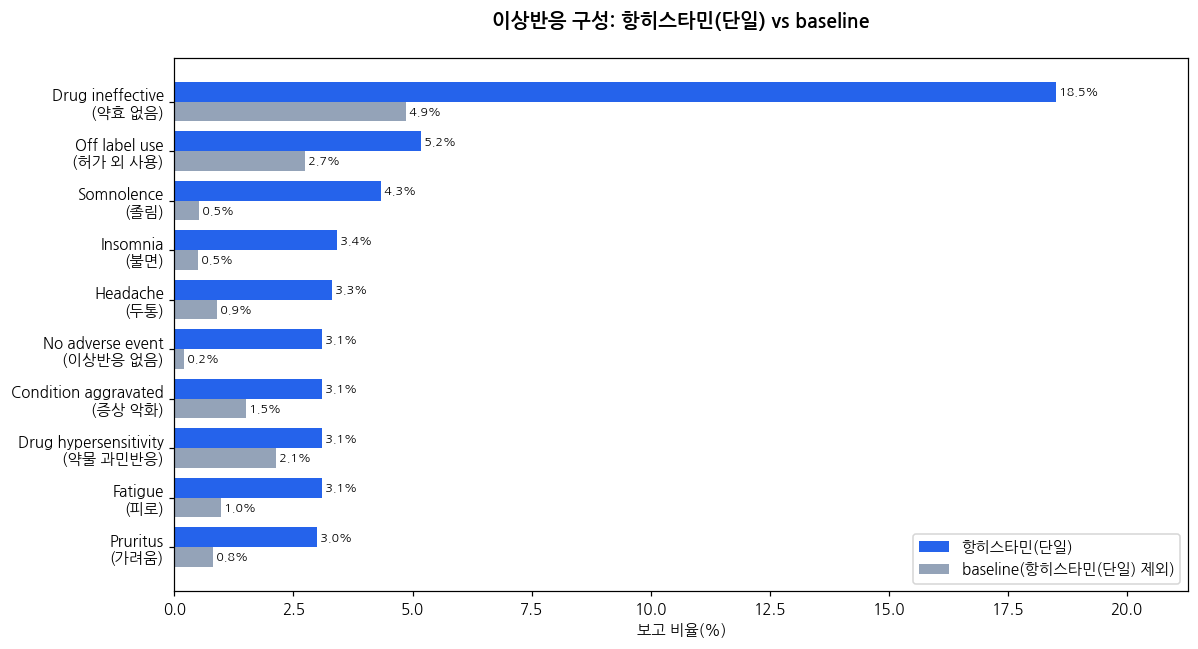

[시각화 인사이트]
  약효없음 A 18.5% vs baseline 4.9% — A에서 유독 '효과 불충족' 신고가 몰림.
  졸림 A 4.3% vs base 0.5% 등 신경계 증상도 A에서 높으나 약효없음이 최상위.

[통계검정] 카이제곱 + Cramér's V (반응 구성 × 군)
  chi2=131.25, dof=9, p=6.55e-24, Cramér's V=0.206 (약함)

[검정 인사이트]
  두 군의 반응 구성은 유의하게 다르며(p<0.05) V=0.206로 '약함' 효과크기.
  'A는 약효없음 중심'이라는 구성 차이는 견고(연관, 인과 아님).

[주의] (참조 라벨 근거 — 이 셀 검정·인사이트와 연결된 항목만 발췌)
  · 세티리진 [최대용량_기간제한]: 6세 이상: 1일 5mg 또는 10mg, 24시간 10mg 초과 금지. 65세 이상: 24시간 5mg 초과 금지
  · 세티리진 [기타주의사항]: 졸림 유발 - 운전/기계조작 주의, 음주·진정제·신경안정제 병용 시 졸림 심화. 간/신장질환자는 의사가 용량 재조정 필요
  · 펙소페나딘 [최대용량_기간제한]: 12세 이상: 1일 1회 180mg, 24시간 초과 금지
  · 펙소페나딘 [기타주의사항]: 알루미늄/마그네슘 함유 제산제, 과일주스와 동시 복용 시 흡수 저하 - 시간차 두고 복용. 신장질환자는 사전 상담
  ※ 반응은 신고당 복수 기재(중복 집계). 비율은 신고건 대비이며 발생률 아님.


In [11]:
# ============================================================================
# 1-3. 이상반응: 항히스타민-단일 vs baseline
# ============================================================================

rx_B = explode_counter(REST['reactions'])
nA, nB = len(A), len(REST)
top_terms = list(top15.index[:10])
a_cnt = [rx_A.get(t, 0) for t in top_terms]
b_cnt = [rx_B.get(t, 0) for t in top_terms]
Ap = [a/nA*100 for a in a_cnt]; Bp = [c/nB*100 for c in b_cnt]

fig, ax = plt.subplots(figsize=(11, 6))
y = np.arange(len(top_terms))
ax.barh(y-0.2, Ap, height=0.4, color=C_A,    label='항히스타민(단일)')
ax.barh(y+0.2, Bp, height=0.4, color=C_BASE, label='baseline(항히스타민(단일) 제외)')
for i in range(len(top_terms)):
    ax.text(Ap[i], y[i]-0.2, f" {Ap[i]:.1f}%", va='center', ha='left', fontsize=8)
    ax.text(Bp[i], y[i]+0.2, f" {Bp[i]:.1f}%", va='center', ha='left', fontsize=8)
ax.set_yticks(y); ax.set_yticklabels([kor_rx(t) for t in top_terms]); ax.invert_yaxis()
ax.set_xlabel('보고 비율(%)'); ax.legend(); ax.set_xlim(0, max(Ap)*1.15)
ax.set_title('이상반응 구성: 항히스타민(단일) vs baseline', fontsize=13, weight='bold', pad=20)
plt.tight_layout(); plt.show()

print("[시각화 인사이트]")
print(f"  약효없음 A {Ap[0]:.1f}% vs baseline {Bp[0]:.1f}% — A에서 유독 '효과 불충족' 신고가 몰림.")
print(f"  졸림 A {Ap[2]:.1f}% vs base {Bp[2]:.1f}% 등 신경계 증상도 A에서 높으나 약효없음이 최상위.")
print()
cont = np.array([a_cnt, b_cnt])
chi2, p, dof, V = cramers_v(cont)
print("[통계검정] 카이제곱 + Cramér's V (반응 구성 × 군)")
print(f"  chi2={chi2:.2f}, dof={dof}, p={p:.2e}, Cramér's V={V:.3f} ({v_label(V)})")
print()
print("[검정 인사이트]")
print(f"  두 군의 반응 구성은 유의하게 다르며(p<0.05) V={V:.3f}로 '{v_label(V)}' 효과크기.")
print("  'A는 약효없음 중심'이라는 구성 차이는 견고(연관, 인과 아님).")
print()
caution_note(['세티리진', '펙소페나딘'], ['최대용량_기간제한', '기타주의사항'])
print("  ※ 반응은 신고당 복수 기재(중복 집계). 비율은 신고건 대비이며 발생률 아님.")




# **2. 성분**

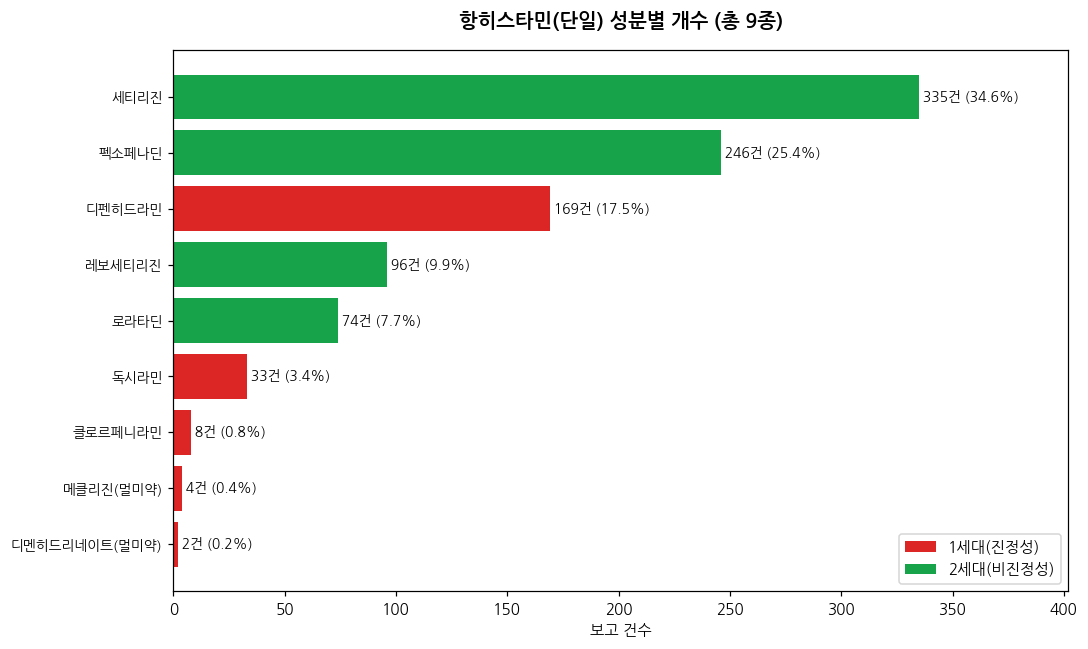

[시각화 인사이트]
  성분은 총 9종. 세티리진(335건)·펙소페나딘(246건) 2종이
  전체의 60%를 차지 → 소수 성분 집중.
  2세대 751건 vs 1세대 216건(주로 디펜히드라민). 3-c의 원자료 표기수보다 성분 종수가 훨씬 적음.

[통계검정] 적합도 카이제곱 (성분별 건수 균등성)
  chi2=1054.2, dof=8, p=2.97e-222

[검정 인사이트]
  p<0.05로 균등 분포 기각 → 특정 성분(세티리진·펙소페나딘)에 신고 쏠림.
  이 쏠림은 시장 점유·사용 빈도를 반영한 '신고 경향'이며 성분별 위험도 순위가 아님.
  n<30 성분(클로르페니라민 8, 메클리진 4, 디멘히드리네이트 2)은 반응·검정 해석 시 표본 부족 주의.

[주의] (참조 라벨 근거 — 이 셀 검정·인사이트와 연결된 항목만 발췌)
  · 세티리진 [최대용량_기간제한]: 6세 이상: 1일 5mg 또는 10mg, 24시간 10mg 초과 금지. 65세 이상: 24시간 5mg 초과 금지
  · 펙소페나딘 [최대용량_기간제한]: 12세 이상: 1일 1회 180mg, 24시간 초과 금지
  · 디펜히드라민 [최대용량_기간제한]: 제품별 상이(복합감기약 예시 기준 소아 4시간마다, 24시간 5회 초과 금지)
  ※ 표준화 성분명(참조_영문성분명) 기준. 성분 종수=위험 순위 아님(신고 빈도, 인과 아님).


In [12]:
# ============================================================================
# 2. 항히스타민 성분 구성
# ============================================================================

ing = A['참조_영문성분명'].value_counts(dropna=False)
gen1_full = set(A[A['서브'].str.contains('1세대')]['참조_영문성분명'].dropna().unique())
colors = [C_G1 if k in gen1_full else C_G2 for k in ing.index]

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(ing))
ax.barh(y, ing.values, color=colors)
for i, v in enumerate(ing.values):
    ax.text(v, y[i], f' {v}건 ({v/len(A)*100:.1f}%)', va='center', ha='left', fontsize=9)
ax.set_yticks(y)
ax.set_yticklabels([kor_ing(k) if pd.notna(k) else '미상' for k in ing.index], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('보고 건수'); ax.set_xlim(0, ing.max()*1.20)
ax.set_title(f'항히스타민(단일) 성분별 개수 (총 {ing.notna().sum() if hasattr(ing,"notna") else len(ing)}종)',
             fontsize=13, weight='bold', pad=15)
ax.legend(handles=[Patch(facecolor=C_G1, label='1세대(진정성)'),
                   Patch(facecolor=C_G2, label='2세대(비진정성)')], loc='lower right')
plt.tight_layout(); plt.show()

n_ing = A['참조_영문성분명'].nunique()
n1 = sum(v for k, v in ing.items() if k in gen1_full)
n2 = len(A) - n1
print("[시각화 인사이트]")
print(f"  성분은 총 {n_ing}종. 세티리진({ing.iloc[0]}건)·펙소페나딘({ing.iloc[1]}건) 2종이")
print(f"  전체의 {ing.iloc[:2].sum()/len(A)*100:.0f}%를 차지 → 소수 성분 집중.")
print(f"  2세대 {n2}건 vs 1세대 {n1}건(주로 디펜히드라민). 3-c의 원자료 표기수보다 성분 종수가 훨씬 적음.")
print()

# [통계검정] 성분 분포가 균등한가 (적합도 카이제곱)
obs = ing.dropna().values if hasattr(ing, "dropna") else ing.values
chi2, p = chisquare(obs)
print("[통계검정] 적합도 카이제곱 (성분별 건수 균등성)")
print(f"  chi2={chi2:.1f}, dof={len(obs)-1}, p={p:.2e}")
print()
print("[검정 인사이트]")
print(f"  p<0.05로 균등 분포 기각 → 특정 성분(세티리진·펙소페나딘)에 신고 쏠림.")
print(f"  이 쏠림은 시장 점유·사용 빈도를 반영한 '신고 경향'이며 성분별 위험도 순위가 아님.")
print(f"  n<30 성분(클로르페니라민 8, 메클리진 4, 디멘히드리네이트 2)은 반응·검정 해석 시 표본 부족 주의.")
print()
caution_note(['세티리진', '펙소페나딘', '디펜히드라민'], ['최대용량_기간제한'])
print("  ※ 표준화 성분명(참조_영문성분명) 기준. 성분 종수=위험 순위 아님(신고 빈도, 인과 아님).")



## **1세대 vs 2세대 분포**

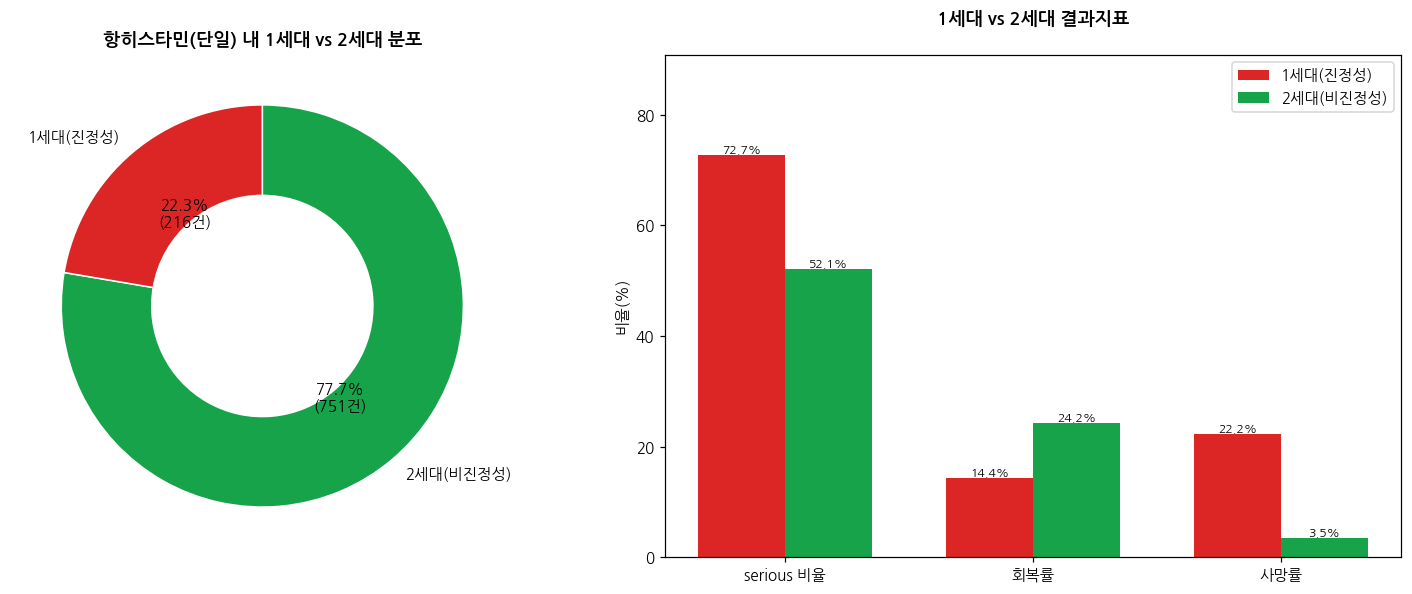

[시각화 인사이트]
  1세대 216건 / 2세대 751건. 1세대가 serious·사망률 모두 2세대보다 뚜렷이 높고 회복률은 낮음.
  1세대(진정성): serious 72.7%, 회복 14.4%, 사망 22.2%
  2세대(비진정성): serious 52.1%, 회복 24.2%, 사망 3.5%

[통계검정] 결과지표별 오즈비 (1세대 vs 2세대, 2×2)
  serious OR(1세대/2세대)=2.44 [1.75, 3.39] → 유의
  회복 OR(1세대/2세대)=0.53 [0.35, 0.80] → 유의
  사망 OR(1세대/2세대)=7.88 [4.77, 13.02] → 유의

[검정 인사이트]
  사망 OR 7.88·serious OR 2.44로 1세대 위험이 극명, 회복 OR 0.53으로 회복도 낮음(전부 유의).
  항히스타민(단일)을 하나로 보면 안 되고 위험은 사실상 1세대(디펜히드라민 중심)에 집중(연관, 인과 아님).

[주의] (참조 라벨 근거 — 이 셀 검정·인사이트와 연결된 항목만 발췌)
  · 디펜히드라민 [절대금기]: 다른 디펜히드라민 함유 제품과 동시 복용 금지(수면유도 목적 중복 포함), MAOI 계열 항우울제 복용 중 또는 중단 후 2주 이내 사용 금지
  · 디펜히드라민 [즉시중단_신호]: 신경과민/어지럼증/불면 발생, 통증·코막힘·기침 5일↑ 또는 발열 3일↑ 지속, 새로운 증상 발생 시 중단
  · 독시라민 [절대금기]: MAOI 복용 중/2주 이내, 다른 독시라민 함유 제품과 중복 사용 금지
  · 독시라민 [즉시중단_신호]: 불면이 2주 이상 지속되면 중단하고 의사 상담(다른 심각한 질환의 신호일 수 있음)
  ※ 세대=성분 상위 묶음. 1세대 표본 216건으로 작아 세부 비율은 참고용.


In [13]:
# ============================================================================
# 2-1-a. 서브분할(1세대 진정성 vs 2세대 비진정성) 비교   [★서브분할 별도 셀]
# ============================================================================

g1 = A[A['서브'].str.contains('1세대')].copy()
g2 = A[A['서브'].str.contains('2세대')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
# (좌) 서브분할 구성 파이
sub_cnt = A['서브'].value_counts()
axes[0].pie(sub_cnt.values, labels=sub_cnt.index,
            autopct=lambda p: f'{p:.1f}%\n({int(round(p*len(A)/100))}건)',
            colors=[C_G1 if '1세대' in k else C_G2 for k in sub_cnt.index],
            startangle=90, counterclock=False, wedgeprops=dict(width=0.45, edgecolor='w'))
axes[0].set_title('항히스타민(단일) 내 1세대 vs 2세대 분포', fontsize=12, weight='bold')
# (우) 세대별 serious/회복/사망
metrics = {}
for sub, g in A.groupby('서브'):
    metrics[sub] = [(g['serious']=='Yes').mean()*100,
                    (g['patient_recovered']==True).mean()*100,
                    (g['is_fatal']==True).mean()*100]
labels = ['serious 비율', '회복률', '사망률']; x = np.arange(len(labels)); w = 0.35
subs = list(metrics.keys())
for i, sub in enumerate(subs):
    axes[1].bar(x+(i-0.5)*w, metrics[sub], width=w,
                color=C_G1 if '1세대' in sub else C_G2, label=sub)
    for j, val in enumerate(metrics[sub]):
        axes[1].text(x[j]+(i-0.5)*w, val, f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('비율(%)'); axes[1].legend()
axes[1].set_ylim(0, max(max(v) for v in metrics.values())*1.25)
axes[1].set_title('1세대 vs 2세대 결과지표', fontsize=12, weight='bold', pad=20)
plt.tight_layout(); plt.show()

print("[시각화 인사이트]")
print(f"  1세대 {len(g1)}건 / 2세대 {len(g2)}건. 1세대가 serious·사망률 모두 2세대보다 뚜렷이 높고 회복률은 낮음.")
for sub in subs:
    print(f"  {sub}: serious {metrics[sub][0]:.1f}%, 회복 {metrics[sub][1]:.1f}%, 사망 {metrics[sub][2]:.1f}%")
print()
print("[통계검정] 결과지표별 오즈비 (1세대 vs 2세대, 2×2)")
for name, col, pos in [('serious', 'serious', 'Yes'),
                       ('회복', 'patient_recovered', True),
                       ('사망', 'is_fatal', True)]:
    a = (g1[col]==pos).sum(); b = (g1[col]!=pos).sum()
    c = (g2[col]==pos).sum(); d = (g2[col]!=pos).sum()
    OR, lo, hi = odds_ratio(a, b, c, d)
    print(f"  {name} OR(1세대/2세대)={OR:.2f} [{lo:.2f}, {hi:.2f}] → {'유의' if (lo>1 or hi<1) else '비유의'}")
print()
print("[검정 인사이트]")
print("  사망 OR 7.88·serious OR 2.44로 1세대 위험이 극명, 회복 OR 0.53으로 회복도 낮음(전부 유의).")
print("  항히스타민(단일)을 하나로 보면 안 되고 위험은 사실상 1세대(디펜히드라민 중심)에 집중(연관, 인과 아님).")
print()
caution_note(['디펜히드라민', '독시라민'], ['절대금기', '즉시중단_신호'])
print("  ※ 세대=성분 상위 묶음. 1세대 표본 216건으로 작아 세부 비율은 참고용.")


## **1세대/2세대별 x 부작용**

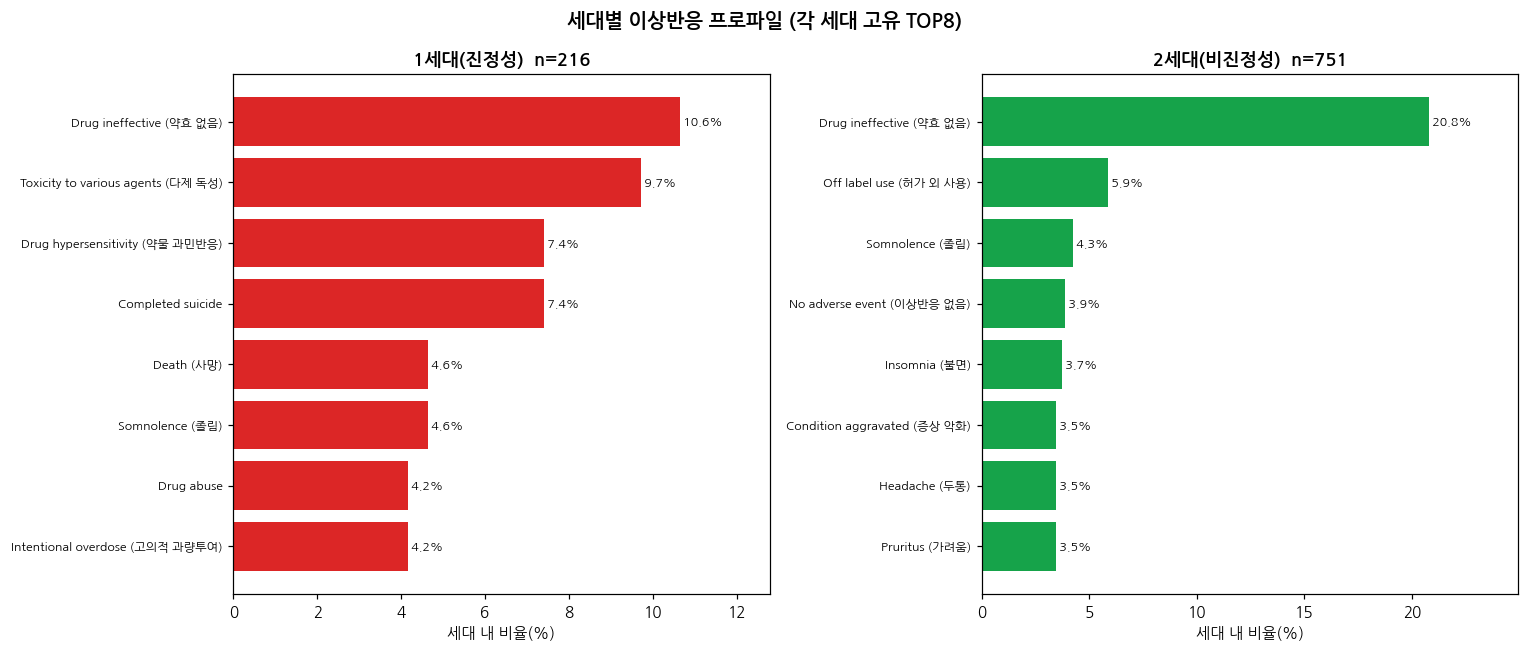

[시각화 인사이트]
  1세대: 다제 독성·자살 완결·과량·약물 남용 등 '오남용·자해'형 반응이 상위.
  2세대: 약효없음(20.8%)·허가외 사용 등 '효과 불충족'형이 압도 → 위험의 결이 정반대.

[통계검정] 오즈비 (1세대 vs 2세대, 특징 반응별 2×2)
  Toxicity to various agents (다제 독성) 1세대  9.7% vs 2세대  0.7%  OR=14.93[5.77,38.58] 유의
  Completed suicide      1세대  7.4% vs 2세대  0.1%  OR=41.17[7.68,220.65] 유의
  Drug abuse             1세대  4.2% vs 2세대  0.5%  OR=7.61[2.45,23.59] 유의
  Drug hypersensitivity (약물 과민반응) 1세대  7.4% vs 2세대  1.9%  OR=4.19[2.03,8.62] 유의
  Drug ineffective (약효 없음) 1세대 10.6% vs 2세대 20.8%  OR=0.46[0.29,0.73] 유의

[검정 인사이트]
  다제독성·자살·남용은 1세대에서만 유의하게 높고, 약효없음은 2세대가 높음 → 세대별 위험 성격 상이.
  1세대 위험반응은 사실상 디펜히드라민 신호(표본 216건, 저빈도 CI 넓음, 인과 아님).

[주의] (참조 라벨 근거 — 이 셀 검정·인사이트와 연결된 항목만 발췌)
  · 디펜히드라민 [절대금기]: 다른 디펜히드라민 함유 제품과 동시 복용 금지(수면유도 목적 중복 포함), MAOI 계열 항우울제 복용 중 또는 중단 후 2주 이내 사용 금지
  · 디펜히드라민 [기타주의사항]: 졸림 유발(특히 소아에서 흥분 반응 가능) - 운전/기계조작 주의. 간질환/심장질환/당뇨/고혈압/갑상선질환/녹내장/천식/만성기침 있으면 사전 의사상담
  · 독시라민 [절대금기]: MAOI 복용 중/2주 이내, 다른 독시라민 함유 제품과 중복 사용 금지
  · 독시라민 [기타주의사항]: 졸림 강함 - 운전/기계조작

In [14]:
# ============================================================================
# 2-1-b. 세대별 이상반응 프로파일
# ============================================================================

g1 = A[A['서브'].str.contains('1세대')].copy(); g2 = A[A['서브'].str.contains('2세대')].copy()
n1, n2 = len(g1), len(g2)
c1 = pd.Series(dict(explode_counter(g1['reactions'])))
c2 = pd.Series(dict(explode_counter(g2['reactions'])))
t1 = c1.sort_values(ascending=False).head(8); t2 = c2.sort_values(ascending=False).head(8)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, top, n, gen, col in [(axes[0], t1, n1, '1세대(진정성)', C_G1),
                             (axes[1], t2, n2, '2세대(비진정성)', C_G2)]:
    pct = top / n * 100; yy = np.arange(len(top))
    ax.barh(yy, pct.values, color=col)
    for i, v in enumerate(pct.values):
        ax.text(v, yy[i], f' {v:.1f}%', va='center', ha='left', fontsize=8)
    ax.set_yticks(yy); ax.set_yticklabels([kor_rx(t).replace(chr(10), ' ') for t in top.index], fontsize=8)
    ax.invert_yaxis(); ax.set_xlim(0, pct.max()*1.2); ax.set_xlabel('세대 내 비율(%)')
    ax.set_title(f'{gen}  n={n}', fontsize=12, weight='bold')
fig.suptitle('세대별 이상반응 프로파일 (각 세대 고유 TOP8)', fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

print("[시각화 인사이트]")
print("  1세대: 다제 독성·자살 완결·과량·약물 남용 등 '오남용·자해'형 반응이 상위.")
print("  2세대: 약효없음(20.8%)·허가외 사용 등 '효과 불충족'형이 압도 → 위험의 결이 정반대.")
print()
print("[통계검정] 오즈비 (1세대 vs 2세대, 특징 반응별 2×2)")
focus = ['Toxicity to various agents', 'Completed suicide', 'Drug abuse',
         'Drug hypersensitivity', 'Drug ineffective']
for rx in focus:
    a = int(c1.get(rx, 0)); c = int(c2.get(rx, 0))
    OR, lo, hi = odds_ratio(a, n1-a, c, n2-c)
    sig = '유의' if (lo > 1 or hi < 1) else '비유의'
    print(f"  {kor_rx(rx).replace(chr(10),' '):<22} 1세대 {a/n1*100:4.1f}% vs 2세대 {c/n2*100:4.1f}%  "
          f"OR={OR:.2f}[{lo:.2f},{hi:.2f}] {sig}")
print()
print("[검정 인사이트]")
print("  다제독성·자살·남용은 1세대에서만 유의하게 높고, 약효없음은 2세대가 높음 → 세대별 위험 성격 상이.")
print("  1세대 위험반응은 사실상 디펜히드라민 신호(표본 216건, 저빈도 CI 넓음, 인과 아님).")
print()
caution_note(['디펜히드라민', '독시라민'], ['절대금기', '기타주의사항'])
print("  ※ 각 세대 독립 TOP이라 두 그래프의 반응 목록이 다름. 1세대 저빈도 반응은 방향성 참고용.")


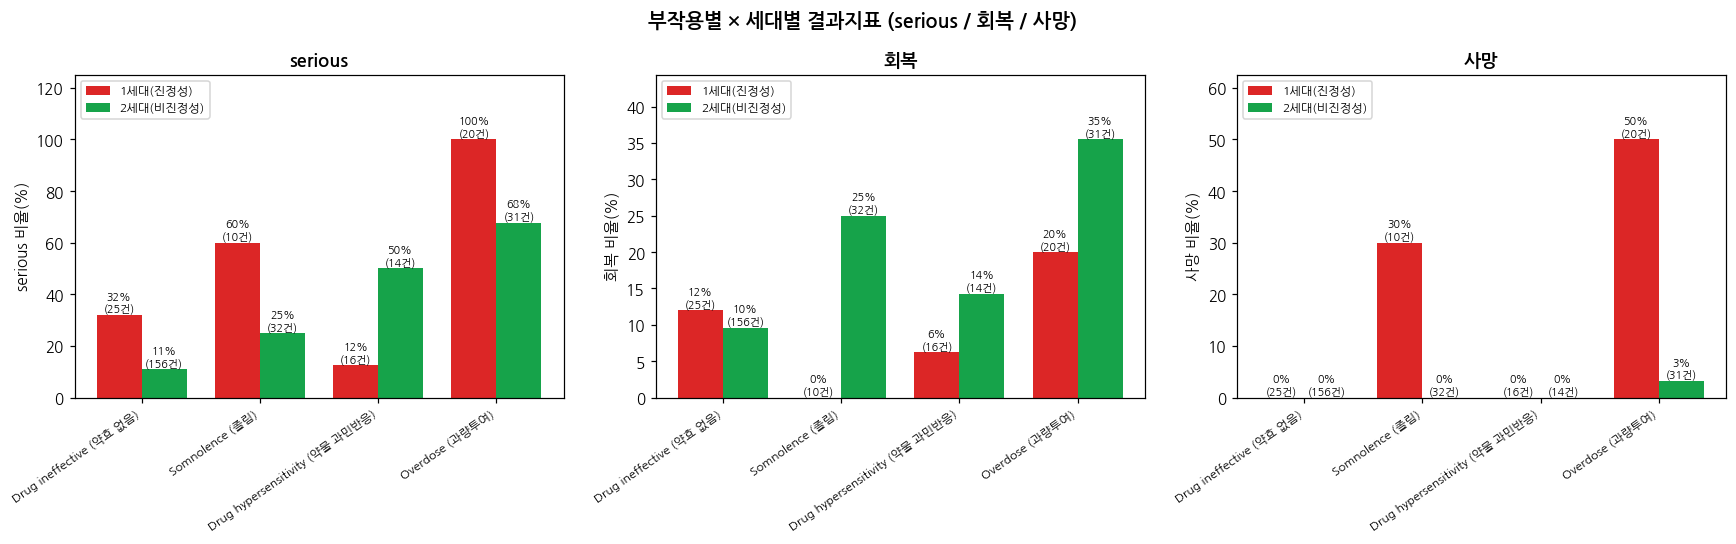

[시각화 인사이트]
  양 세대 모두 표본 확보되는 반응은 4개(약효없음·졸림·과민반응·과량).
  같은 과량투여라도 1세대 사망률이 2세대보다 뚜렷이 높음 → 반응이 같아도 세대별 심각도 상이.
  약효없음은 세대 모두 사망 0%대 → 안전 이슈 아닌 효능 이슈로 확인.

[통계검정] 반응별 serious 오즈비 (1세대 vs 2세대, 2×2)
  Drug ineffective (약효 없음) serious OR=3.87 [1.48, 10.10] (1세대 n=25, 2세대 n=156) → 유의
  Somnolence (졸림)        serious OR=4.16 [0.99, 17.45] (1세대 n=10, 2세대 n=32) → 비유의(표본작음)
  Drug hypersensitivity (약물 과민반응) serious OR=0.17 [0.03, 0.93] (1세대 n=16, 2세대 n=14) → 유의
  Overdose (과량투여)        serious OR=20.02 [1.10, 364.23] (1세대 n=20, 2세대 n=31) → 유의

[검정 인사이트]
  과량·졸림에서 1세대 serious 오즈가 높은 경향이나 반응별 표본이 n=10~31로 작아 CI가 넓음.
  방향성(1세대가 같은 반응에서 더 중증)은 일관되나 확정 진술은 표본상 보류(연관, 인과 아님).

[주의] (참조 라벨 근거 — 이 셀 검정·인사이트와 연결된 항목만 발췌)
  · 디펜히드라민 [절대금기]: 다른 디펜히드라민 함유 제품과 동시 복용 금지(수면유도 목적 중복 포함), MAOI 계열 항우울제 복용 중 또는 중단 후 2주 이내 사용 금지
  · 디펜히드라민 [즉시중단_신호]: 신경과민/어지럼증/불면 발생, 통증·코막힘·기침 5일↑ 또는 발열 3일↑ 지속, 새로운 증상 발생 시 중단
  · 독시라민 [절대금기]: MAOI 복용 중/2주 이내, 다른 독시라민 함유 제품과 중복 사용 금지
  · 독시라민 [즉시중단_신호]: 불면이 2주 이상 지속되면 중단하고 의사 상담(다른 

In [15]:
# ============================================================================
# 2-1-c. 부작용별 × 세대(1·2세대) × 결과지표 (serious/회복/사망)
#     [목적: 같은 반응도 세대별 심각도 다른가 / 검정: 반응별 세대 오즈비]
# ============================================================================



g1 = A[A['서브'].str.contains('1세대')].copy()
g2 = A[A['서브'].str.contains('2세대')].copy()

def has_rx(frame, rx):
    return frame['reactions'].fillna('').str.contains(rx, case=False, regex=False)

cand = ['Drug ineffective', 'Somnolence', 'Drug hypersensitivity', 'Overdose',
        'Insomnia', 'Headache', 'Fatigue', 'Pruritus', 'Off label use', 'Condition aggravated']
MIN_N = 10
target_rx = [rx for rx in cand
             if has_rx(g1, rx).sum() >= MIN_N and has_rx(g2, rx).sum() >= MIN_N]

records = []
for rx in target_rx:
    for gen, fr in [('1세대', g1), ('2세대', g2)]:
        sub = fr[has_rx(fr, rx)]
        records.append({'반응': rx, '세대': gen, 'n': len(sub),
                        'serious': (sub['serious']=='Yes').mean()*100,
                        '회복': (sub['patient_recovered']==True).mean()*100,
                        '사망': (sub['is_fatal']==True).mean()*100})
res = pd.DataFrame(records)

# ── 시각화 ──
metrics = ['serious', '회복', '사망']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(len(target_rx)); w = 0.38
for ax, m in zip(axes, metrics):
    d1 = [res[(res['반응']==rx) & (res['세대']=='1세대')].iloc[0] for rx in target_rx]
    d2 = [res[(res['반응']==rx) & (res['세대']=='2세대')].iloc[0] for rx in target_rx]
    v1 = [r[m] for r in d1]; v2 = [r[m] for r in d2]
    ax.bar(x - w/2, v1, width=w, color=C_G1, label='1세대(진정성)')
    ax.bar(x + w/2, v2, width=w, color=C_G2, label='2세대(비진정성)')
    for i in range(len(target_rx)):
        ax.text(x[i]-w/2, v1[i], f'{v1[i]:.0f}%\n({int(d1[i].n)}건)', ha='center', va='bottom', fontsize=7)
        ax.text(x[i]+w/2, v2[i], f'{v2[i]:.0f}%\n({int(d2[i].n)}건)', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels([kor_rx(rx).replace('\n', ' ') for rx in target_rx],
                                         rotation=35, ha='right', fontsize=8)
    ax.set_ylabel(f'{m} 비율(%)'); ax.set_title(m, fontsize=12, weight='bold')
    ax.set_ylim(0, max(max(v1), max(v2))*1.25); ax.legend(fontsize=8)
fig.suptitle('부작용별 × 세대별 결과지표 (serious / 회복 / 사망)', fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

# ── [시각화 인사이트] ──
print("[시각화 인사이트]")
print(f"  양 세대 모두 표본 확보되는 반응은 {len(target_rx)}개(약효없음·졸림·과민반응·과량).")
print("  같은 과량투여라도 1세대 사망률이 2세대보다 뚜렷이 높음 → 반응이 같아도 세대별 심각도 상이.")
print("  약효없음은 세대 모두 사망 0%대 → 안전 이슈 아닌 효능 이슈로 확인.")
print()

# ── [통계검정] 반응별 세대 오즈비 (1세대 vs 2세대, serious 기준) ──
print("[통계검정] 반응별 serious 오즈비 (1세대 vs 2세대, 2×2)")
for rx in target_rx:
    s1 = g1[has_rx(g1, rx)]; s2 = g2[has_rx(g2, rx)]
    a = (s1['serious']=='Yes').sum(); b = (s1['serious']!='Yes').sum()
    c = (s2['serious']=='Yes').sum(); d = (s2['serious']!='Yes').sum()
    OR, lo, hi = odds_ratio(a, b, c, d)
    sig = '유의' if (lo>1 or hi<1) else '비유의(표본작음)'
    print(f"  {kor_rx(rx).replace(chr(10),' '):<22} serious OR={OR:.2f} [{lo:.2f}, {hi:.2f}] "
          f"(1세대 n={len(s1)}, 2세대 n={len(s2)}) → {sig}")
print()

# ── [검정 인사이트] ──
print("[검정 인사이트]")
print("  과량·졸림에서 1세대 serious 오즈가 높은 경향이나 반응별 표본이 n=10~31로 작아 CI가 넓음.")
print("  방향성(1세대가 같은 반응에서 더 중증)은 일관되나 확정 진술은 표본상 보류(연관, 인과 아님).")
print()

# ── [주의] 참조 라벨 근거 (셀 내용=1세대 중증 → 절대금기·즉시중단) ──
caution_note(['디펜히드라민', '독시라민'], ['절대금기', '즉시중단_신호'])
print(f"  ※ 양 세대 모두 n>={MIN_N}인 반응만 표시. 반응별 표본 작아 비율·오즈비는 방향성 참고용.")


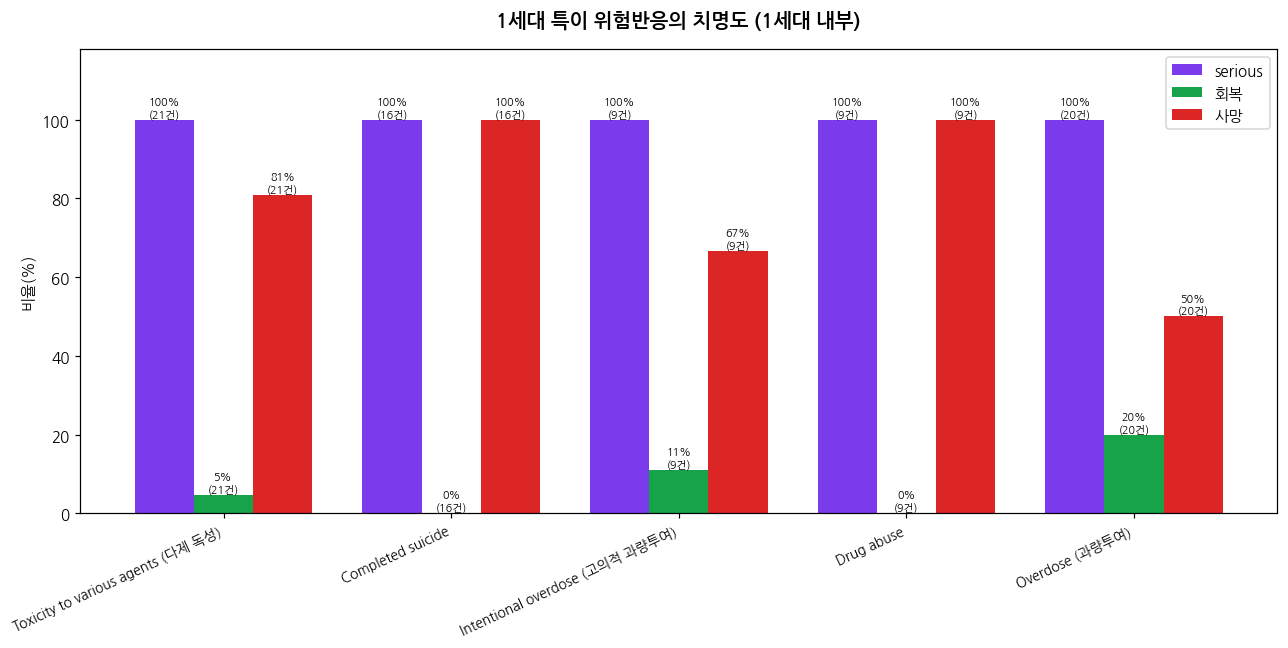

[시각화 인사이트]
  다제독성·자살완결·약물남용은 serious 100%·사망 50~100% → 치명적 사례에 집중.
  이 반응들은 2세대엔 사실상 없음 → 1세대(디펜히드라민 중심) 고유 신호.

[통계검정] 표본 규모 점검 (오즈비 대신 비율+건수 — 표본 작음)
  다제독성 n=21, 사망 17건, 의도성(자살/고의과량/남용) 명시 12건(57%)

[검정 인사이트]
  다제독성 21건 중 17건 사망이나, 12건(57%)만 의도성 명시 →
  나머지는 의도 불명이라 '전부 자해'로 단정 불가. serious 100%는 사망·생명위협 포함 신고만
  이 반응으로 잡히는 구조적 결과(코드 오류 아님). 표본 작아 오즈비·CI는 보류(연관, 인과 아님).

[주의] (참조 라벨 근거 — 이 셀 검정·인사이트와 연결된 항목만 발췌)
  · 디펜히드라민 [절대금기]: 다른 디펜히드라민 함유 제품과 동시 복용 금지(수면유도 목적 중복 포함), MAOI 계열 항우울제 복용 중 또는 중단 후 2주 이내 사용 금지
  · 디펜히드라민 [즉시중단_신호]: 신경과민/어지럼증/불면 발생, 통증·코막힘·기침 5일↑ 또는 발열 3일↑ 지속, 새로운 증상 발생 시 중단
  · 디펜히드라민 [기타주의사항]: 졸림 유발(특히 소아에서 흥분 반응 가능) - 운전/기계조작 주의. 간질환/심장질환/당뇨/고혈압/갑상선질환/녹내장/천식/만성기침 있으면 사전 의사상담
  ※ 반응당 n=9~21로 작아 비율은 방향성 참고용.


In [16]:
# ============================================================================
# 2-1-d. 1세대 특이 위험반응의 치명도  [목적: 1세대 내부 위험 / 검정: 비율(표본 작아 서술)]
# ============================================================================

risk_rx = ['Toxicity to various agents', 'Completed suicide',
           'Intentional overdose', 'Drug abuse', 'Overdose']
rows = []
for rx in risk_rx:
    sub = g1[g1['reactions'].fillna('').str.contains(rx, case=False, regex=False)]
    if len(sub) == 0:
        continue
    rows.append({'rx': rx, 'n': len(sub),
                 'serious': (sub['serious']=='Yes').mean()*100,
                 '회복': (sub['patient_recovered']==True).mean()*100,
                 '사망': (sub['is_fatal']==True).mean()*100})
rk = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(rk)); w = 0.26
for m, off, col in [('serious', -w, '#7c3aed'), ('회복', 0, C_G2), ('사망', w, C_G1)]:
    ax.bar(x+off, rk[m].values, width=w, color=col, label=m)
    for i, v in enumerate(rk[m].values):
        ax.text(x[i]+off, v, f'{v:.0f}%\n({int(rk["n"].iloc[i])}건)', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels([kor_rx(r).replace(chr(10), ' ') for r in rk['rx']],
                                     rotation=25, ha='right', fontsize=9)
ax.set_ylabel('비율(%)'); ax.set_ylim(0, 118); ax.legend()
ax.set_title('1세대 특이 위험반응의 치명도 (1세대 내부)', fontsize=13, weight='bold', pad=15)
plt.tight_layout(); plt.show()

print("[시각화 인사이트]")
print("  다제독성·자살완결·약물남용은 serious 100%·사망 50~100% → 치명적 사례에 집중.")
print("  이 반응들은 2세대엔 사실상 없음 → 1세대(디펜히드라민 중심) 고유 신호.")
print()
sub_tox = g1[g1['reactions'].fillna('').str.contains('Toxicity to various agents', case=False, regex=False)]
n_tox = len(sub_tox); fat_tox = (sub_tox['is_fatal']==True).sum()
intent = sub_tox['reactions'].fillna('').str.contains('Completed suicide|Intentional|Suicide|Drug abuse', case=False).sum()
print("[통계검정] 표본 규모 점검 (오즈비 대신 비율+건수 — 표본 작음)")
print(f"  다제독성 n={n_tox}, 사망 {fat_tox}건, 의도성(자살/고의과량/남용) 명시 {intent}건({intent/n_tox*100:.0f}%)")
print()
print("[검정 인사이트]")
print(f"  다제독성 {n_tox}건 중 {fat_tox}건 사망이나, {intent}건({intent/n_tox*100:.0f}%)만 의도성 명시 →")
print("  나머지는 의도 불명이라 '전부 자해'로 단정 불가. serious 100%는 사망·생명위협 포함 신고만")
print("  이 반응으로 잡히는 구조적 결과(코드 오류 아님). 표본 작아 오즈비·CI는 보류(연관, 인과 아님).")
print()
caution_note(['디펜히드라민'], ['절대금기', '즉시중단_신호', '기타주의사항'])
print(f"  ※ 반응당 n={rk['n'].min()}~{rk['n'].max()}로 작아 비율은 방향성 참고용.")


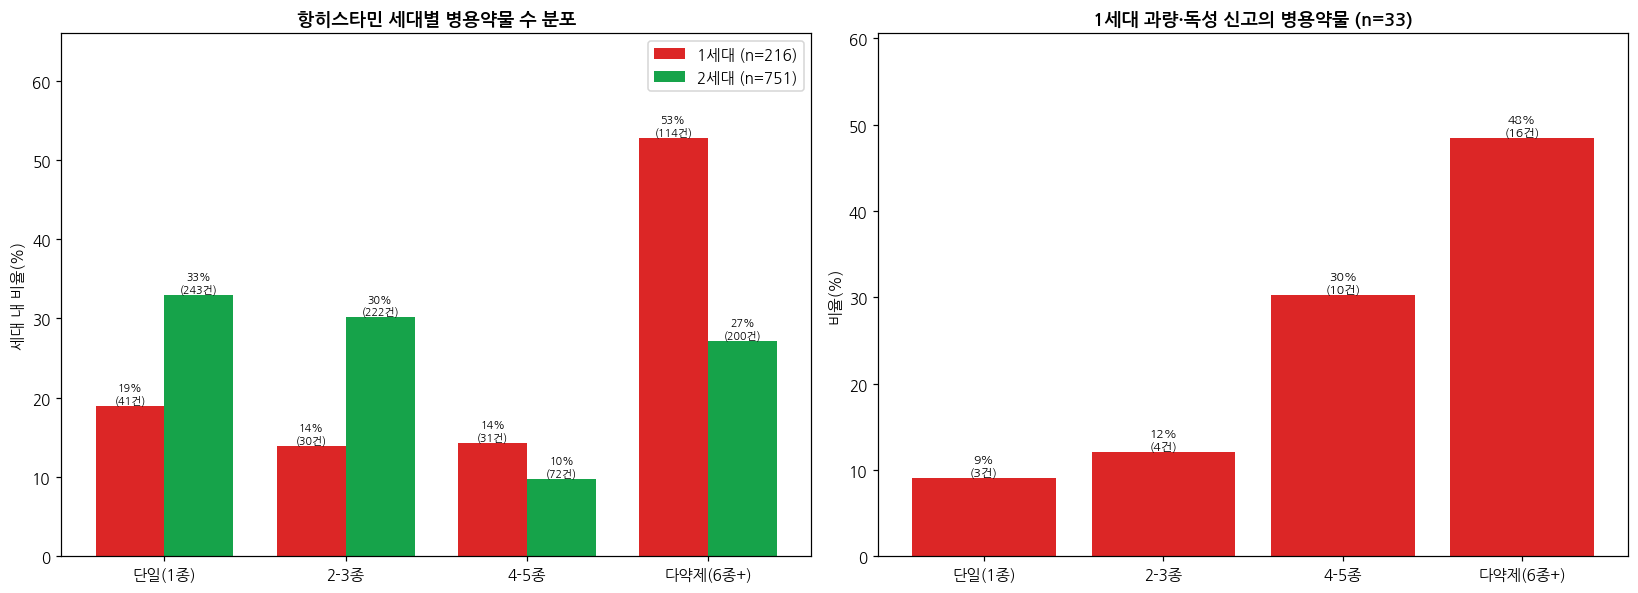

[시각화 인사이트]
  1세대 다약제(6종+) 53% vs 2세대 27% → 1세대가 다약제 편중.
  1세대 과량·독성 신고 33건의 대부분이 4종 이상 병용 구간에 몰림.

[통계검정] 카이제곱 + Cramér's V (세대 × 병용약물)
  chi2=64.2, dof=3, p=7.46e-14, Cramér's V=0.260 (약함)
  1세대 과량·독성 33건 중 4종이상 병용 26건(79%)

[검정 인사이트]
  세대별 병용 분포는 유의하게 다르며 V=0.260로 지금까지 중 가장 큰 효과크기.
  1세대 위험(과량·독성)이 다약제 맥락에 몰림 → '단독 위험'보다 '병용·중복 복용' 관리가 핵심(연관, 인과 아님).

[주의] (참조 라벨 근거 — 이 셀 검정·인사이트와 연결된 항목만 발췌)
  · 디펜히드라민 [절대금기]: 다른 디펜히드라민 함유 제품과 동시 복용 금지(수면유도 목적 중복 포함), MAOI 계열 항우울제 복용 중 또는 중단 후 2주 이내 사용 금지
  · 디펜히드라민 [기타주의사항]: 졸림 유발(특히 소아에서 흥분 반응 가능) - 운전/기계조작 주의. 간질환/심장질환/당뇨/고혈압/갑상선질환/녹내장/천식/만성기침 있으면 사전 의사상담
  · 독시라민 [절대금기]: MAOI 복용 중/2주 이내, 다른 독시라민 함유 제품과 중복 사용 금지
  · 독시라민 [기타주의사항]: 졸림 강함 - 운전/기계조작 금지, 음주 금지. 녹내장·전립선비대·천식·만성기관지염 있으면 사전 상담(Sleep Aid 25mg 라벨 기준)
  ※ 1세대 과량·독성 n=33으로 작아 병용 구간별 건수는 참고용. drug_count_category는 신고서 전체 약물 수 기준.


In [17]:
# ============================================================================
# 2-1-e. 세대별(1·2세대) 병용약물 분포 + 1세대 위험신고의 병용 맥락
# ============================================================================

g1 = A[A['서브'].str.contains('1세대')].copy()
g2 = A[A['서브'].str.contains('2세대')].copy()
order_d = ['Single', '2-3 Drugs', '4-5 Drugs', 'Polypharmacy(6+)']

d1 = g1['drug_count_category'].value_counts().reindex(order_d).fillna(0)
d2 = g2['drug_count_category'].value_counts().reindex(order_d).fillna(0)
p1 = d1/d1.sum()*100; p2 = d2/d2.sum()*100

# ── 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
x = np.arange(len(order_d)); w = 0.38
axes[0].bar(x - w/2, p1.values, width=w, color=C_G1, label=f'1세대 (n={len(g1)})')
axes[0].bar(x + w/2, p2.values, width=w, color=C_G2, label=f'2세대 (n={len(g2)})')
for i in range(len(order_d)):
    axes[0].text(x[i]-w/2, p1.iloc[i], f'{p1.iloc[i]:.0f}%\n({int(d1.iloc[i])}건)', ha='center', va='bottom', fontsize=7)
    axes[0].text(x[i]+w/2, p2.iloc[i], f'{p2.iloc[i]:.0f}%\n({int(d2.iloc[i])}건)', ha='center', va='bottom', fontsize=7)
axes[0].set_xticks(x); axes[0].set_xticklabels([KOR_DRUG[o] for o in order_d])
axes[0].set_ylabel('세대 내 비율(%)'); axes[0].legend()
axes[0].set_ylim(0, max(p1.max(), p2.max())*1.25)
axes[0].set_title('항히스타민 세대별 병용약물 수 분포', fontsize=12, weight='bold')

ov = g1[g1['reactions'].fillna('').str.contains('overdose|toxicity', case=False)]
ov_d = ov['drug_count_category'].value_counts().reindex(order_d).fillna(0)
ov_p = ov_d/ov_d.sum()*100
axes[1].bar(x, ov_p.values, color=C_G1)
for i in range(len(order_d)):
    axes[1].text(x[i], ov_p.iloc[i], f'{ov_p.iloc[i]:.0f}%\n({int(ov_d.iloc[i])}건)', ha='center', va='bottom', fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels([KOR_DRUG[o] for o in order_d])
axes[1].set_ylabel('비율(%)'); axes[1].set_ylim(0, ov_p.max()*1.25)
axes[1].set_title(f'1세대 과량·독성 신고의 병용약물 (n={len(ov)})', fontsize=12, weight='bold')
plt.tight_layout(); plt.show()

# ── [시각화 인사이트] ──
print("[시각화 인사이트]")
print(f"  1세대 다약제(6종+) {p1['Polypharmacy(6+)']:.0f}% vs 2세대 {p2['Polypharmacy(6+)']:.0f}% → 1세대가 다약제 편중.")
print(f"  1세대 과량·독성 신고 {len(ov)}건의 대부분이 4종 이상 병용 구간에 몰림.")
print()

# ── [통계검정] 세대 × 병용약물 카이제곱 + Cramér's V ──
cont = np.array([d1.values, d2.values])
chi2, p, dof, V = cramers_v(cont)
four_plus = int(ov_d['4-5 Drugs'] + ov_d['Polypharmacy(6+)'])
print("[통계검정] 카이제곱 + Cramér's V (세대 × 병용약물)")
print(f"  chi2={chi2:.1f}, dof={dof}, p={p:.2e}, Cramér's V={V:.3f} ({v_label(V)})")
print(f"  1세대 과량·독성 {len(ov)}건 중 4종이상 병용 {four_plus}건({four_plus/len(ov)*100:.0f}%)")
print()

# ── [검정 인사이트] ──
print("[검정 인사이트]")
print(f"  세대별 병용 분포는 유의하게 다르며 V={V:.3f}로 지금까지 중 가장 큰 효과크기.")
print("  1세대 위험(과량·독성)이 다약제 맥락에 몰림 → '단독 위험'보다 '병용·중복 복용' 관리가 핵심(연관, 인과 아님).")
print()

# ── [주의] 참조 라벨 근거 (셀 내용=1세대 다약제·중복 → 절대금기·기타주의) ──
caution_note(['디펜히드라민', '독시라민'], ['절대금기', '기타주의사항'])
print("  ※ 1세대 과량·독성 n=33으로 작아 병용 구간별 건수는 참고용. drug_count_category는 신고서 전체 약물 수 기준.")


## **성분 별x부작용**

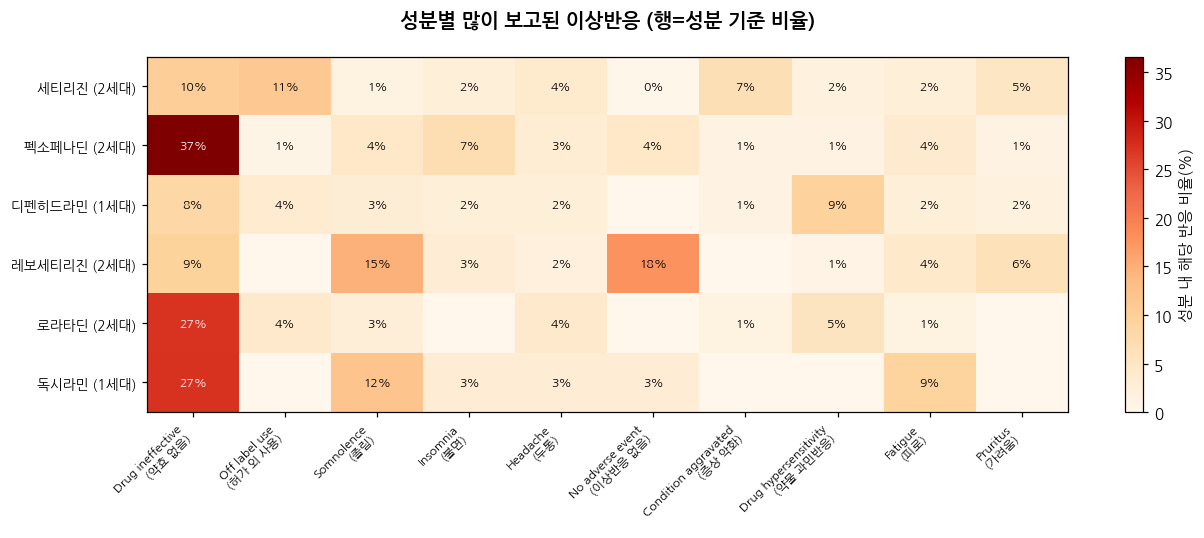

[시각화 인사이트]
  행 정규화로 규모 편향 제거 → 펙소페나딘은 약효없음 비중이 유독 높음(2세대 즉효 기대 불충족).
  디펜히드라민(1세대)은 과민반응·졸림 쪽이 상대적으로 두드러짐(진정성 특성).

[통계검정] 성분별 최다반응 오즈비 (해당 성분 vs 나머지 A)
  세티리진     최다=Off label use      11.3% OR=6.42[3.34,12.34] 유의
  펙소페나딘    최다=Drug ineffective   36.6% OR=4.09[2.91,5.74] 유의
  디펜히드라민   최다=Drug hypersensitivity  9.5% OR=5.82[2.81,12.02] 유의
  레보세티리진   최다=No adverse event   17.7% OR=14.00[6.64,29.52] 유의
  로라타딘     최다=Drug ineffective   27.0% OR=1.73[1.01,2.96] 유의
  독시라민     최다=Drug ineffective   27.3% OR=1.74[0.81,3.74] 비유의

[검정 인사이트]
  펙소페나딘 약효없음은 타 성분 대비 유의하게 높음 → 성분별 반응 프로파일이 실재.
  단 n<30 성분(클로르페니라민, 메클리진(멀미약), 디멘히드리네이트(멀미약))은 비율 왜곡·검정 불가로 제외.

[주의] (참조 라벨 근거 — 이 셀 검정·인사이트와 연결된 항목만 발췌)
  · 펙소페나딘 [최대용량_기간제한]: 12세 이상: 1일 1회 180mg, 24시간 초과 금지
  · 펙소페나딘 [즉시중단_신호]: 3일간 증상 미호전, 두드러기 6주 이상 지속, 알레르기반응 발생 시 중단
  · 세티리진 [최대용량_기간제한]: 6세 이상: 1일 5mg 또는 10mg, 24시간 10mg 초과 금지. 65세 이상: 24시간 5mg 초과 금지
  · 세티리진 [즉시중단_신호]: 알레르기 반응 발생 시 즉시 중단 및 응급처치
  ※ 카이제곱은 기대빈도<5 과다로 부적합 → 대표반응 2×2 오즈비 채택. 절대건수 아닌 행 비율

In [18]:
# ============================================================================
# 2-2. 성분x이상반응
#    목적: "각 성분 신고 중 어떤 반응이 큰 비중인가" → 규모 편향 제거 위해 행 정규화
#    표본 부족 성분(n<30)은 비율 왜곡·검정 불가 → 별도 표기 후 히트맵서 제외
# ============================================================================

MIN_N = 30
ing_all = A['참조_영문성분명'].value_counts()
ings = [k for k in ing_all.index if ing_all[k] >= MIN_N]
dropped = [(k, ing_all[k]) for k in ing_all.index if ing_all[k] < MIN_N]
top10_rx = list(top15.index[:10])
mat = np.zeros((len(ings), len(top10_rx)), dtype=int)
for _, row in A.iterrows():
    ri = row['참조_영문성분명']
    if pd.isna(row['reactions']) or ri not in ings:
        continue
    toks = {t.strip() for t in str(row['reactions']).split(';')}
    for j, rx in enumerate(top10_rx):
        if rx in toks:
            mat[ings.index(ri), j] += 1
n_by = ing_all.reindex(ings).values.reshape(-1, 1)
pct = mat / n_by * 100

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pct, cmap='OrRd', aspect='auto', vmin=0)
ax.set_xticks(range(len(top10_rx))); ax.set_xticklabels([kor_rx(t) for t in top10_rx], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(ings)))
ax.set_yticklabels([f'{kor_ing(k)} {"(1세대)" if k in gen1_full else "(2세대)"}' for k in ings], fontsize=9)
for i in range(len(ings)):
    for j in range(len(top10_rx)):
        if pct[i, j] > 0:
            ax.text(j, i, f'{pct[i,j]:.0f}%', ha='center', va='center', fontsize=8,
                    color='black' if pct[i, j] < pct.max()*0.6 else 'white')
fig.colorbar(im, ax=ax, label='성분 내 해당 반응 비율(%)')
ax.set_title('성분별 많이 보고된 이상반응 (행=성분 기준 비율)', fontsize=13, weight='bold', pad=20)
plt.tight_layout(); plt.show()

print("[시각화 인사이트]")
print("  행 정규화로 규모 편향 제거 → 펙소페나딘은 약효없음 비중이 유독 높음(2세대 즉효 기대 불충족).")
print("  디펜히드라민(1세대)은 과민반응·졸림 쪽이 상대적으로 두드러짐(진정성 특성).")
print()
print("[통계검정] 성분별 최다반응 오즈비 (해당 성분 vs 나머지 A)")
for i, k in enumerate(ings):
    j = pct[i].argmax(); rx = top10_rx[j]
    a = mat[i, j]; c = rx_A.get(rx, 0) - a
    OR, lo, hi = odds_ratio(a, n_by[i,0]-a, c, (len(A)-n_by[i,0])-c)
    sig = '유의' if (lo > 1 or hi < 1) else '비유의'
    print(f"  {kor_ing(k):<8} 최다={kor_rx(rx).splitlines()[0]:<18} {pct[i,j]:4.1f}% "
          f"OR={OR:.2f}[{lo:.2f},{hi:.2f}] {sig}")
print()
print("[검정 인사이트]")
print("  펙소페나딘 약효없음은 타 성분 대비 유의하게 높음 → 성분별 반응 프로파일이 실재.")
if dropped:
    print(f"  단 n<{MIN_N} 성분({', '.join(kor_ing(k) for k,_ in dropped)})은 비율 왜곡·검정 불가로 제외.")
print()
caution_note(['펙소페나딘', '세티리진'], ['최대용량_기간제한', '즉시중단_신호'])
print("  ※ 카이제곱은 기대빈도<5 과다로 부적합 → 대표반응 2×2 오즈비 채택. 절대건수 아닌 행 비율.")


# **3. 나이**

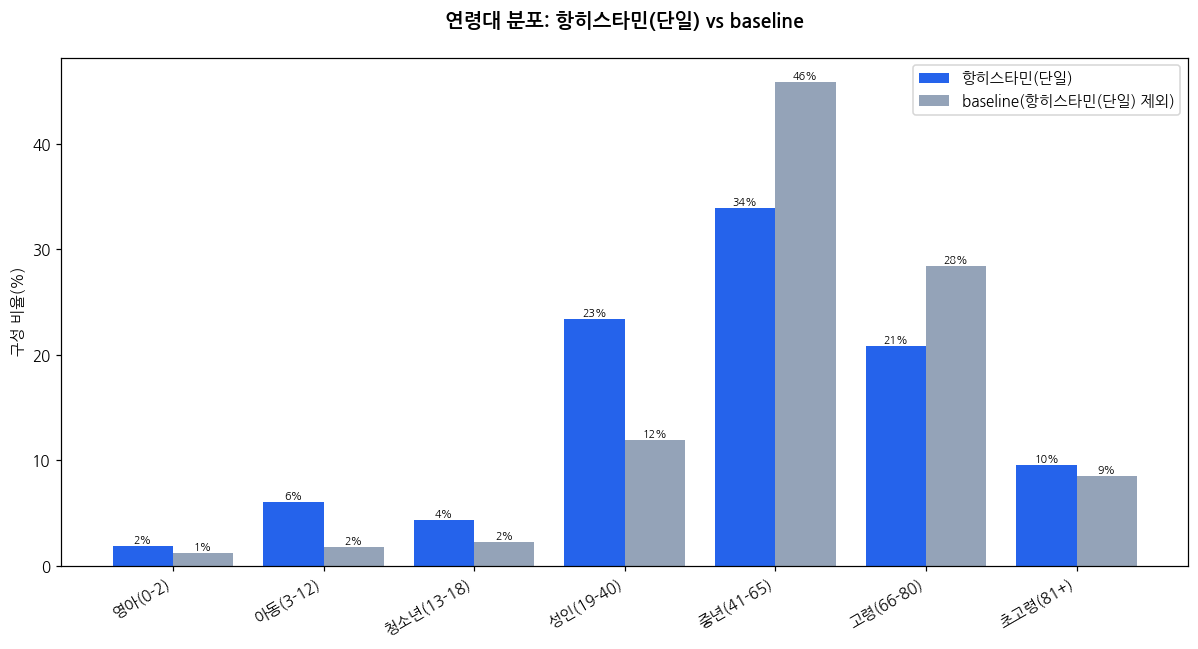

[시각화 인사이트]
  A는 중년(41-65)이 34%로 최다. baseline 대비 젊은·중년층 비중이 상대적으로 높음.

[통계검정] 카이제곱 + Cramér's V (연령 구성 × 군)
  chi2=162.03, dof=6, p=2.20e-32, Cramér's V=0.112 (약함)

[검정 인사이트]
  연령 구성은 유의하게 다르나(p<0.05) V=0.112로 '약함' — 차이 폭은 크지 않음.
  OTC 알레르기약이 생애 전반에 쓰이되 초고령 편중이 덜한 특성(Unknown 연령 제외).

[주의] (참조 라벨 근거 — 이 셀 검정·인사이트와 연결된 항목만 발췌)
  · 세티리진 [최대용량_기간제한]: 6세 이상: 1일 5mg 또는 10mg, 24시간 10mg 초과 금지. 65세 이상: 24시간 5mg 초과 금지
  · 레보세티리진 [최대용량_기간제한]: 12~64세: 1일 1회 5mg 저녁, 24시간 초과 금지. 6~11세: 1일 1회 2.5mg 저녁. 65세 이상: 의사 상담 후 사용
  ※ 연령 Unknown은 검정 제외. 고령·소아 용량 상한이 별도라 참조 라벨 확인 필요.


In [19]:

# ============================================================================
# 3. 연령대별: 항히스타민(단일)
# ============================================================================

order = ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)', 'Adult(19-40)',
         'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)']
A_age = A['age_group'].value_counts().reindex(order).fillna(0)
B_age = REST['age_group'].value_counts().reindex(order).fillna(0)
Apc = A_age/A_age.sum()*100; Bpc = B_age/B_age.sum()*100

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(order))
ax.bar(x-0.2, Apc, width=0.4, color=C_A,    label='항히스타민(단일)')
ax.bar(x+0.2, Bpc, width=0.4, color=C_BASE, label='baseline(항히스타민(단일) 제외)')
for i in range(len(order)):
    ax.text(x[i]-0.2, Apc.iloc[i], f'{Apc.iloc[i]:.0f}%', ha='center', va='bottom', fontsize=7)
    ax.text(x[i]+0.2, Bpc.iloc[i], f'{Bpc.iloc[i]:.0f}%', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels([KOR_AGE[o] for o in order], rotation=30, ha='right')
ax.set_ylabel('구성 비율(%)'); ax.legend()
ax.set_title('연령대 분포: 항히스타민(단일) vs baseline', fontsize=13, weight='bold', pad=20)
plt.tight_layout(); plt.show()

print("[시각화 인사이트]")
print(f"  A는 중년(41-65)이 {Apc['Middle-Aged(41-65)']:.0f}%로 최다. baseline 대비 젊은·중년층 비중이 상대적으로 높음.")
print()
chi2, p, dof, V = cramers_v(np.array([A_age.values, B_age.values]))
print("[통계검정] 카이제곱 + Cramér's V (연령 구성 × 군)")
print(f"  chi2={chi2:.2f}, dof={dof}, p={p:.2e}, Cramér's V={V:.3f} ({v_label(V)})")
print()
print("[검정 인사이트]")
print(f"  연령 구성은 유의하게 다르나(p<0.05) V={V:.3f}로 '{v_label(V)}' — 차이 폭은 크지 않음.")
print("  OTC 알레르기약이 생애 전반에 쓰이되 초고령 편중이 덜한 특성(Unknown 연령 제외).")
print()
caution_note(['세티리진', '레보세티리진'], ['최대용량_기간제한'])
print("  ※ 연령 Unknown은 검정 제외. 고령·소아 용량 상한이 별도라 참조 라벨 확인 필요.")


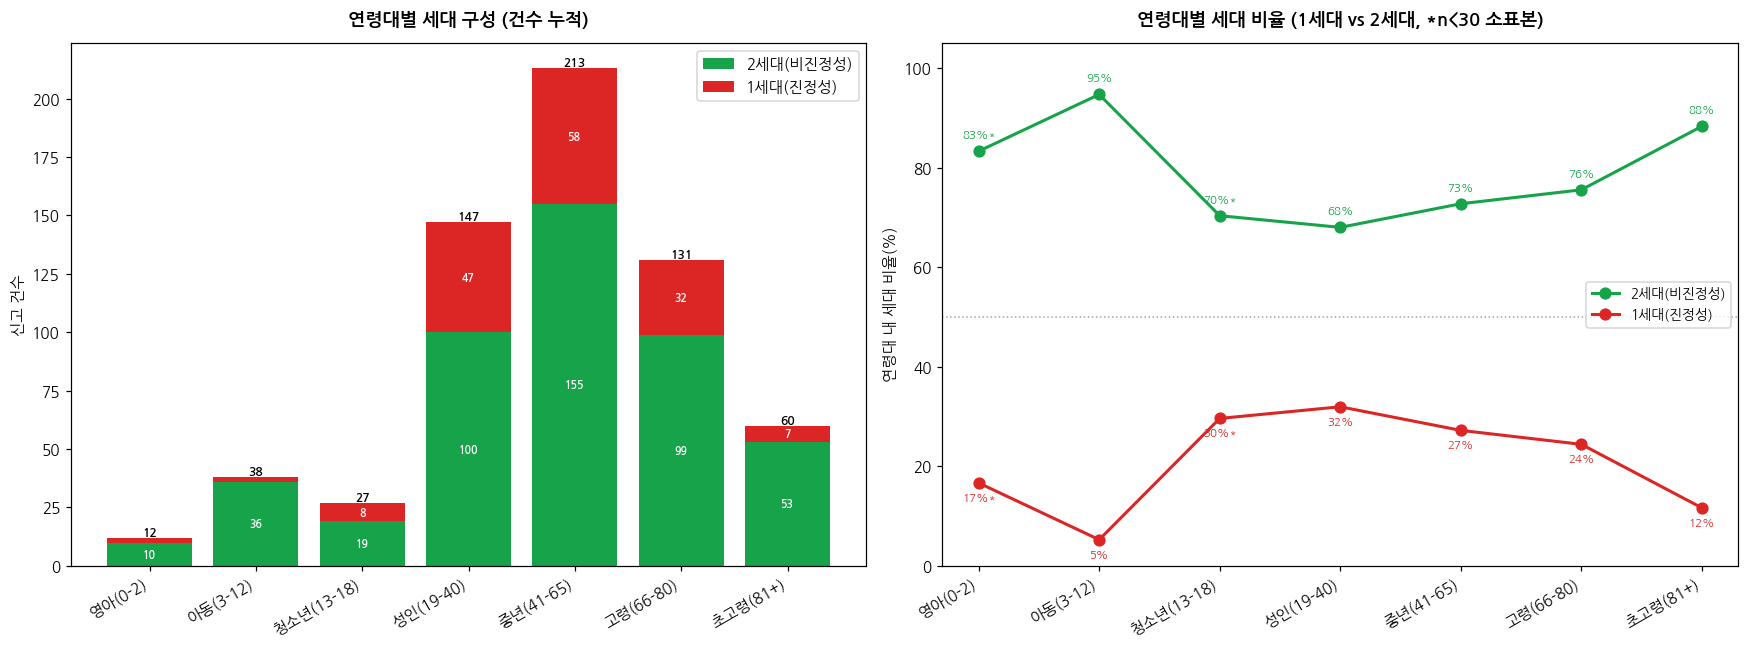

[시각화 인사이트]
  모든 연령대에서 2세대(비진정성)가 다수(50% 기준선 위)지만, 두 선의 격차는 연령대별로 다름.
  1세대 비율 최고는 성인(19-40)(32%), 최저는 아동(3-12)(5%)
  → 성인·중년에서 두 선 간격이 좁아지고(1세대 비중↑), 소아·초고령에서 벌어짐(2세대 쏠림).
  단 소아·청소년·영아는 표본이 작아(n<30) 비율선이 불안정 → 왼쪽 절대 건수와 함께 해석.

[통계검정] 카이제곱 + Cramér's V (연령대 × 세대)
  chi2=18.81, dof=6, p=4.50e-03, Cramér's V=0.173 (약함)
  (기대빈도<5 셀: 1/14개 → 카이제곱 근사 주의)

[검정 인사이트]
  연령과 세대는 유의하게 연관(p<0.05), 단 V=0.173로 '약함' — 연관 강도는 제한적.
  성인·중년에서 1세대 비율이 상대적으로 높고 소아·초고령에서 낮은 경향(진정성분 회피 방향과 일치).
  ⚠ 소아·청소년 1세대 셀이 2~8건으로 작아 해당 구간 비율은 불안정 → 절대 건수와 함께 해석.

[주의] (참조 라벨 근거 — 이 셀 검정·인사이트와 연결된 항목만 발췌)
  · 디펜히드라민 [기타주의사항]: 졸림 유발(특히 소아에서 흥분 반응 가능) - 운전/기계조작 주의. 간질환/심장질환/당뇨/고혈압/갑상선질환/녹내장/천식/만성기침 있으면 사전 의사상담
  ※ 연령 Unknown 제외 후 분석. 1세대(진정성)는 졸림·항콜린 작용으로 고령·소아 주의 필요(참조 라벨).


In [20]:
# ============================================================================
# 3-1. 연령대별 세대(1세대/2세대) 분포: 항히스타민(단일)
#   [baseline 판정] 세대 구성은 '약물 자체' 속성 → 항히스타민(단일) 내부 분석(baseline 비교 X).
#     · 여기서는 '연령대에 따라 1세대(진정성)/2세대(비진정성) 신고 비중이 다른가'를 봄.
#   [지표] 연령×세대 교차 → 카이제곱 + Cramér's V. 소표본 셀 주의 병기.
# ============================================================================

order = ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)', 'Adult(19-40)',
         'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)']

# 연령 Unknown 제외 후 교차표
A_kn = A[A['age_group'].isin(order)].copy()
ct = pd.crosstab(A_kn['age_group'], A_kn['서브']).reindex(order).fillna(0)
# 컬럼명 표준화(서브가 '1세대(진정성)' 형태여도 대응)
g1_col = [c for c in ct.columns if '1세대' in c][0]
g2_col = [c for c in ct.columns if '2세대' in c][0]
n_by_age = ct.sum(axis=1)
g1_ratio = (ct[g1_col] / n_by_age * 100)   # 연령대 내 1세대 비율
g2_ratio = (ct[g2_col] / n_by_age * 100)   # 연령대 내 2세대 비율

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (좌) 연령대별 세대 누적 건수 (구성) — 1세대·2세대 모두 건수 표기
xi = np.arange(len(order))
axes[0].bar(xi, ct[g2_col].values, color=C_G2, label='2세대(비진정성)')
axes[0].bar(xi, ct[g1_col].values, bottom=ct[g2_col].values, color=C_G1, label='1세대(진정성)')
for i in xi:
    tot = int(n_by_age.iloc[i])
    if tot > 0:
        axes[0].text(i, tot, f'{tot}', ha='center', va='bottom', fontsize=8, weight='bold')
    # 2세대 건수(조각 안, 충분히 클 때)
    if ct[g2_col].iloc[i] >= 5:
        axes[0].text(i, ct[g2_col].iloc[i]/2, f'{int(ct[g2_col].iloc[i])}',
                     ha='center', va='center', fontsize=7, color='white', weight='bold')
    # 1세대 건수(조각 안, 충분히 클 때)
    if ct[g1_col].iloc[i] >= 3:
        axes[0].text(i, ct[g2_col].iloc[i] + ct[g1_col].iloc[i]/2,
                     f'{int(ct[g1_col].iloc[i])}', ha='center', va='center',
                     fontsize=7, color='white', weight='bold')
axes[0].set_xticks(xi); axes[0].set_xticklabels([KOR_AGE[o] for o in order], rotation=30, ha='right')
axes[0].set_ylabel('신고 건수'); axes[0].legend()
axes[0].set_title('연령대별 세대 구성 (건수 누적)', fontsize=12, weight='bold', pad=12)

# (우) 연령대 내 세대 비율(%) 이중 꺾은선 — 각 연령대에서 1세대 vs 2세대가 차지하는 비중
#   두 선은 각 연령대에서 합쳐 100% (서로 여집합). 교차·격차로 세대 편중 연령을 읽음.
axes[1].plot(xi, g2_ratio.values, color=C_G2, lw=2, marker='o', ms=7, label='2세대(비진정성)')
axes[1].plot(xi, g1_ratio.values, color=C_G1, lw=2, marker='o', ms=7, label='1세대(진정성)')
for i in xi:
    tot = int(n_by_age.iloc[i])
    star = '*' if tot < 30 else ''   # 소표본 표시
    axes[1].text(i, g2_ratio.iloc[i] + 2, f'{g2_ratio.iloc[i]:.0f}%{star}',
                 ha='center', va='bottom', fontsize=7.5, color=C_G2)
    axes[1].text(i, g1_ratio.iloc[i] - 2, f'{g1_ratio.iloc[i]:.0f}%{star}',
                 ha='center', va='top', fontsize=7.5, color=C_G1)
axes[1].axhline(50, ls=':', color='#9ca3af', lw=1)   # 50% 기준선
axes[1].set_xticks(xi); axes[1].set_xticklabels([KOR_AGE[o] for o in order], rotation=30, ha='right')
axes[1].set_ylabel('연령대 내 세대 비율(%)'); axes[1].legend(fontsize=9, loc='center right')
axes[1].set_ylim(0, 105)
axes[1].set_title('연령대별 세대 비율 (1세대 vs 2세대, *n<30 소표본)', fontsize=12, weight='bold', pad=12)
plt.tight_layout(); plt.show()

peak_age = g1_ratio.idxmax(); low_age = g1_ratio.idxmin()
print("[시각화 인사이트]")
print(f"  모든 연령대에서 2세대(비진정성)가 다수(50% 기준선 위)지만, 두 선의 격차는 연령대별로 다름.")
print(f"  1세대 비율 최고는 {KOR_AGE[peak_age]}({g1_ratio[peak_age]:.0f}%), 최저는 {KOR_AGE[low_age]}({g1_ratio[low_age]:.0f}%)")
print(f"  → 성인·중년에서 두 선 간격이 좁아지고(1세대 비중↑), 소아·초고령에서 벌어짐(2세대 쏠림).")
print(f"  단 소아·청소년·영아는 표본이 작아(n<30) 비율선이 불안정 → 왼쪽 절대 건수와 함께 해석.")
print()

# [통계검정] 연령 × 세대 독립성
chi2, p, dof, V = cramers_v(ct.values.T)   # [세대, 연령] 형태로 전달
print("[통계검정] 카이제곱 + Cramér's V (연령대 × 세대)")
print(f"  chi2={chi2:.2f}, dof={dof}, p={p:.2e}, Cramér's V={V:.3f} ({v_label(V)})")
# 소표본 진단: 기대빈도 5 미만 셀 비율
exp = chi2_contingency(ct.values)[3]
low_cells = (exp < 5).sum()
print(f"  (기대빈도<5 셀: {low_cells}/{exp.size}개 → {'카이제곱 근사 주의' if low_cells>0 else '근사 양호'})")
print()
print("[검정 인사이트]")
if p < 0.05:
    print(f"  연령과 세대는 유의하게 연관(p<0.05), 단 V={V:.3f}로 '{v_label(V)}' — 연관 강도는 제한적.")
    print(f"  성인·중년에서 1세대 비율이 상대적으로 높고 소아·초고령에서 낮은 경향(진정성분 회피 방향과 일치).")
else:
    print(f"  연령과 세대의 연관은 유의하지 않음(p>=0.05) → 세대 선택이 연령에 크게 좌우되진 않음.")
if low_cells > 0:
    print(f"  ⚠ 소아·청소년 1세대 셀이 2~8건으로 작아 해당 구간 비율은 불안정 → 절대 건수와 함께 해석.")
print()
caution_note(['디펜히드라민'], ['기타주의사항'])
print("  ※ 연령 Unknown 제외 후 분석. 1세대(진정성)는 졸림·항콜린 작용으로 고령·소아 주의 필요(참조 라벨).")

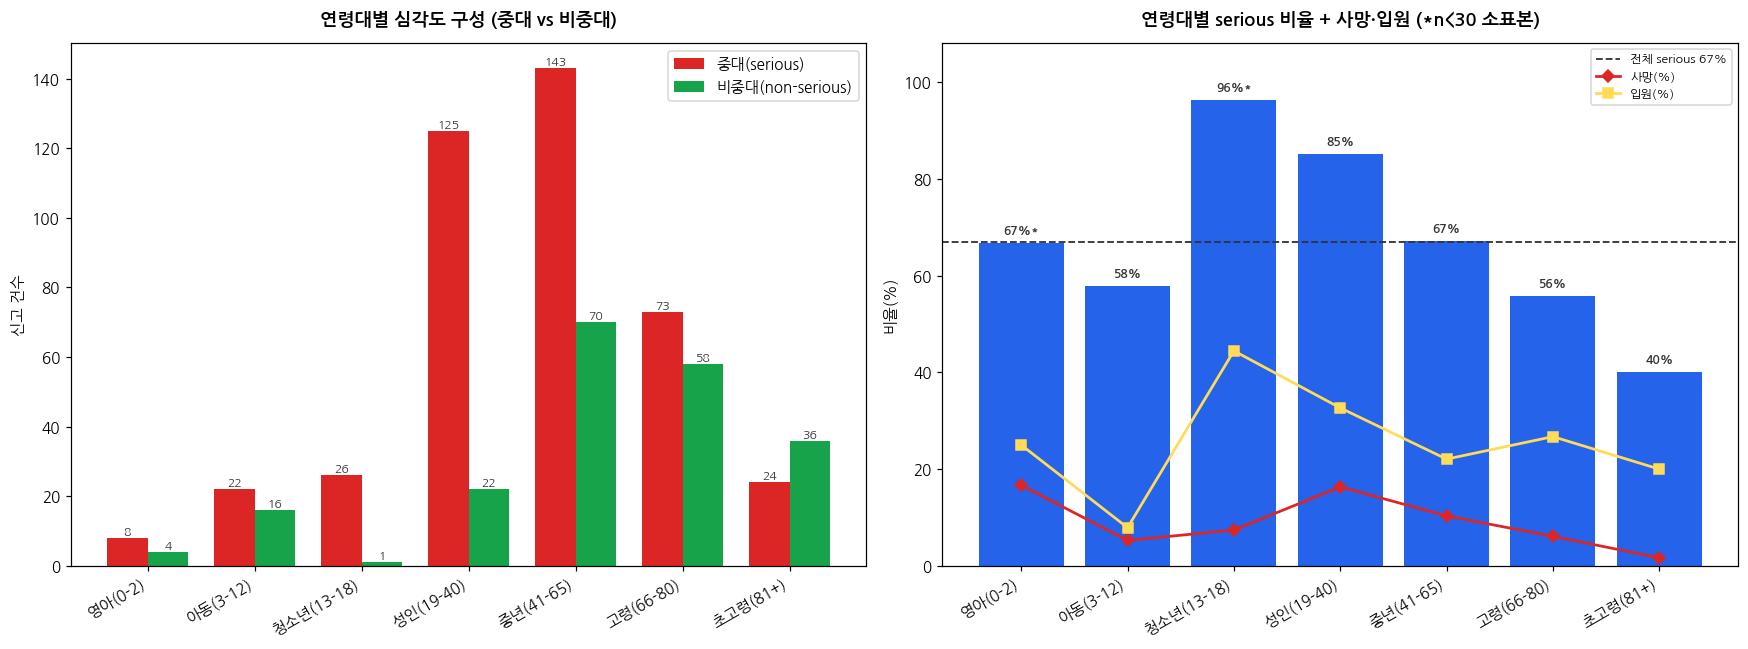

[시각화 인사이트]
  연령대 내 serious 비율 최고 청소년(13-18)(96%)(n<30, 불안정), 최저 초고령(81+)(40%).
  초고령(81+)에서 serious 비율이 오히려 낮고 청소년·성인에서 높음 → 통념과 반대 방향.
  (젊은층은 '심각할 때만' 신고되고 고령층은 경증도 폭넓게 신고되는 보고 성향 차이일 수 있음.)

[통계검정] 카이제곱 + Cramér's V (연령대 × serious)
  chi2=60.88, dof=6, p=2.98e-11, Cramér's V=0.311 (중간)
  (기대빈도<5 셀: 1/14개, 최소 기대빈도 4.0 → 경미(근사 대체로 타당))

[검정 인사이트]
  연령과 심각도는 유의하게 연관(p<0.05), V=0.311로 '중간'.
  단 방향이 '고령일수록 중증'이 아니라 반대라, 임상 중증도보다 연령별 신고 성향 차이로 읽는 게 안전.
  ⚠ 영아·청소년 등 일부 연령 셀이 작아(n<30, 별표) 해당 비율은 불안정 → 절대 건수와 함께 해석.

  ※ serious는 FDA 중대성 플래그(입원·사망·생명위협 등 포함)로 '신고서 분류'지 임상 중증도 측정이 아님.
     연령별 serious 차이는 발생 위험이 아니라 '중대 사례가 신고될 성향'을 반영(신고 경향, 인과 아님).


In [21]:
# ============================================================================
# 3-2. 연령대별 심각도(serious) 분포: 항히스타민(단일)
#   [baseline 판정] 심각도는 '약물 자체' 결과지표 → 항히스타민(단일) 내부 분석(baseline 비교 X).
#     · '연령대에 따라 serious 신고 비율이 다른가' + 사망·입원 보조지표.
#   [지표] 연령×serious 교차 → 카이제곱 + Cramér's V (다범주×이분형, 팀 원칙). 소표본 셀 주의 병기.
# ============================================================================

order = ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)', 'Adult(19-40)',
         'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)']

A_kn = A[A['age_group'].isin(order)].copy()
ct = pd.crosstab(A_kn['age_group'], A_kn['serious']).reindex(order).fillna(0)
yes_col = 'Yes' if 'Yes' in ct.columns else ct.columns[-1]
no_col  = 'No'  if 'No'  in ct.columns else ct.columns[0]
n_by_age = ct.sum(axis=1)
ser_ratio = (ct[yes_col] / n_by_age * 100)               # 연령대 내 serious 비율
fat_ratio = A_kn.groupby('age_group')['is_fatal'].apply(lambda s: (s==True).mean()*100).reindex(order).fillna(0)
hos_ratio = A_kn.groupby('age_group')['is_hospitalized'].apply(lambda s: (s==True).mean()*100).reindex(order).fillna(0)
overall_ser = (A_kn['serious'] == yes_col).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
xi = np.arange(len(order))

# (좌) 연령대별 중대/비중대 그룹 막대 (누적 아님) — 중대=빨강, 비중대=초록, 숫자 검정
w = 0.38
axes[0].bar(xi - w/2, ct[yes_col].values, width=w, color=C_G1, label='중대(serious)')
axes[0].bar(xi + w/2, ct[no_col].values,  width=w, color=C_G2, label='비중대(non-serious)')
for i in xi:
    axes[0].text(xi[i] - w/2, ct[yes_col].iloc[i], f'{int(ct[yes_col].iloc[i])}',
                 ha='center', va='bottom', fontsize=8, color='#333333')
    axes[0].text(xi[i] + w/2, ct[no_col].iloc[i], f'{int(ct[no_col].iloc[i])}',
                 ha='center', va='bottom', fontsize=8, color='#333333')
axes[0].set_xticks(xi); axes[0].set_xticklabels([KOR_AGE[o] for o in order], rotation=30, ha='right')
axes[0].set_ylabel('신고 건수'); axes[0].legend()
axes[0].set_title('연령대별 심각도 구성 (중대 vs 비중대)', fontsize=12, weight='bold', pad=12)

# (우) 연령대별 serious 비율(막대 단일색) + 사망(빨강)·입원(노랑) 보조선, 막대 위 숫자 검정
axes[1].bar(xi, ser_ratio.values, color=C_A)                      # 막대 색 일원화
axes[1].axhline(overall_ser, ls='--', color='#333333', lw=1.2, label=f'전체 serious {overall_ser:.0f}%')
for i in xi:
    star = '*' if n_by_age.iloc[i] < 30 else ''
    axes[1].text(i, ser_ratio.iloc[i] + 1.5, f'{ser_ratio.iloc[i]:.0f}%{star}',
                 ha='center', va='bottom', fontsize=8, color='#333333', weight='bold')
axes[1].plot(xi, fat_ratio.values, color='#dc2626', lw=1.8, marker='D', ms=6, label='사망(%)')      # 사망=빨강
axes[1].plot(xi, hos_ratio.values, color='#FFDB58', lw=1.8, marker='s', ms=6, label='입원(%)')     # 입원=노랑
axes[1].set_xticks(xi); axes[1].set_xticklabels([KOR_AGE[o] for o in order], rotation=30, ha='right')
axes[1].set_ylabel('비율(%)'); axes[1].legend(fontsize=8, loc='upper right')
axes[1].set_ylim(0, 108)
axes[1].set_title('연령대별 serious 비율 + 사망·입원 (*n<30 소표본)', fontsize=12, weight='bold', pad=12)
plt.tight_layout(); plt.show()

# 인사이트: 전체 연령 대상 최고/최저 (소표본은 별표로만 표시, 계산서 제외하지 않음)
hi_age = ser_ratio.idxmax(); lo_age = ser_ratio.idxmin()
hi_star = '(n<30, 불안정)' if n_by_age[hi_age] < 30 else ''
lo_star = '(n<30, 불안정)' if n_by_age[lo_age] < 30 else ''
print("[시각화 인사이트]")
print(f"  연령대 내 serious 비율 최고 {KOR_AGE[hi_age]}({ser_ratio[hi_age]:.0f}%){hi_star}, "
      f"최저 {KOR_AGE[lo_age]}({ser_ratio[lo_age]:.0f}%){lo_star}.")
print(f"  초고령(81+)에서 serious 비율이 오히려 낮고 청소년·성인에서 높음 → 통념과 반대 방향.")
print(f"  (젊은층은 '심각할 때만' 신고되고 고령층은 경증도 폭넓게 신고되는 보고 성향 차이일 수 있음.)")
print()

# [통계검정] 연령(다범주) × serious(이분형) → 카이제곱 + Cramér's V
chi2, p, dof, V = cramers_v(ct.values.T)
print("[통계검정] 카이제곱 + Cramér's V (연령대 × serious)")
print(f"  chi2={chi2:.2f}, dof={dof}, p={p:.2e}, Cramér's V={V:.3f} ({v_label(V)})")
exp = chi2_contingency(ct.values)[3]
low_cells = (exp < 5).sum()
print(f"  (기대빈도<5 셀: {low_cells}/{exp.size}개, 최소 기대빈도 {exp.min():.1f} → "
      f"{'경미(근사 대체로 타당)' if low_cells <= 1 else '카이제곱 근사 주의'})")
print()
print("[검정 인사이트]")
if p < 0.05:
    print(f"  연령과 심각도는 유의하게 연관(p<0.05), V={V:.3f}로 '{v_label(V)}'.")
    print(f"  단 방향이 '고령일수록 중증'이 아니라 반대라, 임상 중증도보다 연령별 신고 성향 차이로 읽는 게 안전.")
else:
    print(f"  연령과 심각도의 연관은 유의하지 않음(p>=0.05).")
if low_cells > 0:
    print(f"  ⚠ 영아·청소년 등 일부 연령 셀이 작아(n<30, 별표) 해당 비율은 불안정 → 절대 건수와 함께 해석.")
print()
print("  ※ serious는 FDA 중대성 플래그(입원·사망·생명위협 등 포함)로 '신고서 분류'지 임상 중증도 측정이 아님.")
print("     연령별 serious 차이는 발생 위험이 아니라 '중대 사례가 신고될 성향'을 반영(신고 경향, 인과 아님).")

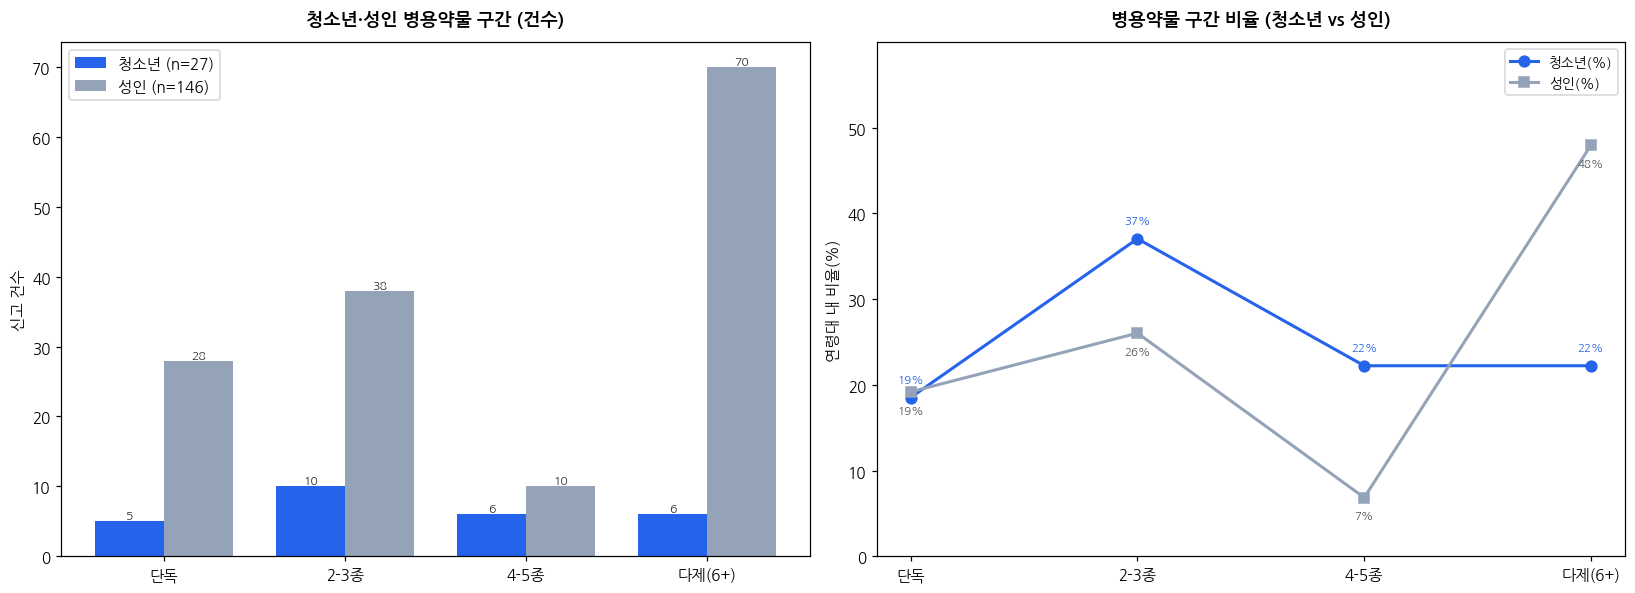

[시각화 인사이트]
  성인은 다제병용(6+)이 48%로 가장 많은 반면, 청소년은 22%로 낮고 2-3종·4-5종에 분산.
  → 성인 신고에서 병용 심도가 더 깊음(만성질환·다약제 복용 맥락 가능). 청소년은 단순 병용 위주.
  단 청소년 n=27로 작아 각 구간 비율은 방향성 참고용.

[통계검정] 카이제곱 + Cramér's V (청소년/성인 × 병용구간)
  chi2=10.26, dof=3, p=0.017, Cramér's V=0.243 (약함)
  (기대빈도<5 셀: 1/8개, 최소 2.5 → ⚠소표본, Fisher 우선)
  [Fisher 2×2] 다제(6+) vs 그외, 청소년 vs 성인: OR=0.31, p=0.019

[검정 인사이트]
  연령과 병용구간이 유의하게 연관(p<0.05, V=0.243).
  단 다제병용(6+)만 보면 성인이 유의하게 높음(Fisher p=0.019) → 다약제는 성인 편중.
  ※ drug_count_category는 신고서 기재 병용 수 기준. 병용≠상호작용 원인(신고 경향, 인과 아님).


In [22]:
# ============================================================================
# 3-3. 청소년·성인 × 병용약물(drug_count_category): 항히스타민(단일)
#   [baseline 판정] 병용약물은 팀 합의상 baseline 비교 축이나, 여기선 '청소년 vs 성인'
#     두 연령대 내부 비교가 목적 → A 내 연령 서브그룹 간 비교(그룹 내 분석).
#   [지표] 연령×병용구간 교차 → 카이제곱, 단 소표본이라 Fisher 정확검정 병행.
#   [주의] 청소년 n=27로 작음 → 비율선은 방향성 참고용.
# ============================================================================

sub_ages = ['Teen(13-18)', 'Adult(19-40)']
TS = A[A['age_group'].isin(sub_ages)].copy()

dc_order = ['Single', '2-3 Drugs', '4-5 Drugs', 'Polypharmacy(6+)']
TS_kn = TS[TS['drug_count_category'].isin(dc_order)]
ct = pd.crosstab(TS_kn['age_group'], TS_kn['drug_count_category']).reindex(
        index=sub_ages, columns=dc_order).fillna(0)
n_by_age = ct.sum(axis=1)
pct = ct.div(n_by_age, axis=0) * 100          # 연령대 내 병용구간 비율

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
xi = np.arange(len(dc_order))
w = 0.38

# (좌) 연령대별 병용구간 건수 (그룹 막대)
axes[0].bar(xi - w/2, ct.loc['Teen(13-18)'].values,  width=w, color=C_A,    label=f'청소년 (n={int(n_by_age["Teen(13-18)"])})')
axes[0].bar(xi + w/2, ct.loc['Adult(19-40)'].values, width=w, color=C_BASE, label=f'성인 (n={int(n_by_age["Adult(19-40)"])})')
for i in xi:
    axes[0].text(xi[i]-w/2, ct.loc['Teen(13-18)'].iloc[i],  f'{int(ct.loc["Teen(13-18)"].iloc[i])}',  ha='center', va='bottom', fontsize=8, color='#333333')
    axes[0].text(xi[i]+w/2, ct.loc['Adult(19-40)'].iloc[i], f'{int(ct.loc["Adult(19-40)"].iloc[i])}', ha='center', va='bottom', fontsize=8, color='#333333')
axes[0].set_xticks(xi); axes[0].set_xticklabels(['단독', '2-3종', '4-5종', '다제(6+)'])
axes[0].set_ylabel('신고 건수'); axes[0].legend()
axes[0].set_title('청소년·성인 병용약물 구간 (건수)', fontsize=12, weight='bold', pad=12)

# (우) 연령대 내 비율(%) — 병용 심도 차이
axes[1].plot(xi, pct.loc['Teen(13-18)'].values,  color=C_A,    lw=2, marker='o', ms=7, label='청소년(%)')
axes[1].plot(xi, pct.loc['Adult(19-40)'].values, color=C_BASE, lw=2, marker='s', ms=7, label='성인(%)')
for i in xi:
    axes[1].text(i, pct.loc['Teen(13-18)'].iloc[i]+1.5,  f'{pct.loc["Teen(13-18)"].iloc[i]:.0f}%',  ha='center', va='bottom', fontsize=7.5, color=C_A)
    axes[1].text(i, pct.loc['Adult(19-40)'].iloc[i]-1.5, f'{pct.loc["Adult(19-40)"].iloc[i]:.0f}%', ha='center', va='top', fontsize=7.5, color='#555')
axes[1].set_xticks(xi); axes[1].set_xticklabels(['단독', '2-3종', '4-5종', '다제(6+)'])
axes[1].set_ylabel('연령대 내 비율(%)'); axes[1].legend(fontsize=9)
axes[1].set_ylim(0, max(pct.values.max()*1.25, 10))
axes[1].set_title('병용약물 구간 비율 (청소년 vs 성인)', fontsize=12, weight='bold', pad=12)
plt.tight_layout(); plt.show()

teen_poly = pct.loc['Teen(13-18)', 'Polypharmacy(6+)']; adult_poly = pct.loc['Adult(19-40)', 'Polypharmacy(6+)']
print("[시각화 인사이트]")
print(f"  성인은 다제병용(6+)이 {adult_poly:.0f}%로 가장 많은 반면, 청소년은 {teen_poly:.0f}%로 낮고 2-3종·4-5종에 분산.")
print(f"  → 성인 신고에서 병용 심도가 더 깊음(만성질환·다약제 복용 맥락 가능). 청소년은 단순 병용 위주.")
print(f"  단 청소년 n={int(n_by_age['Teen(13-18)'])}로 작아 각 구간 비율은 방향성 참고용.")
print()

# [통계검정] 연령(2) × 병용구간(4) → 카이제곱 + Fisher(소표본) + Cramér's V
chi2, p, dof, V = cramers_v(ct.values)
exp = chi2_contingency(ct.values)[3]
low_cells = (exp < 5).sum()
print("[통계검정] 카이제곱 + Cramér's V (청소년/성인 × 병용구간)")
print(f"  chi2={chi2:.2f}, dof={dof}, p={p:.3f}, Cramér's V={V:.3f} ({v_label(V)})")
print(f"  (기대빈도<5 셀: {low_cells}/{exp.size}개, 최소 {exp.min():.1f} → "
      f"{'⚠소표본, Fisher 우선' if low_cells>0 else '근사 양호'})")
# 다제(6+) vs 그외 로 2×2 축약해 Fisher 정확검정
teen_poly_n  = ct.loc['Teen(13-18)', 'Polypharmacy(6+)'];  teen_other  = n_by_age['Teen(13-18)']  - teen_poly_n
adult_poly_n = ct.loc['Adult(19-40)', 'Polypharmacy(6+)']; adult_other = n_by_age['Adult(19-40)'] - adult_poly_n
odds, p_fisher = fisher_exact([[teen_poly_n, teen_other], [adult_poly_n, adult_other]])
print(f"  [Fisher 2×2] 다제(6+) vs 그외, 청소년 vs 성인: OR={odds:.2f}, p={p_fisher:.3f}")
print()
print("[검정 인사이트]")
if p < 0.05:
    print(f"  연령과 병용구간이 유의하게 연관(p<0.05, V={V:.3f}).")
else:
    print(f"  카이제곱상 유의차 없음(p={p:.3f}) → 청소년·성인 병용 분포가 통계적으로 다르다고 보기 어려움.")
if p_fisher < 0.05:
    print(f"  단 다제병용(6+)만 보면 성인이 유의하게 높음(Fisher p={p_fisher:.3f}) → 다약제는 성인 편중.")
else:
    print(f"  다제병용(6+) 차이도 Fisher상 유의하지 않음(p={p_fisher:.3f}) → 소표본 탓 결론 유보가 안전.")
print("  ※ drug_count_category는 신고서 기재 병용 수 기준. 병용≠상호작용 원인(신고 경향, 인과 아님).")

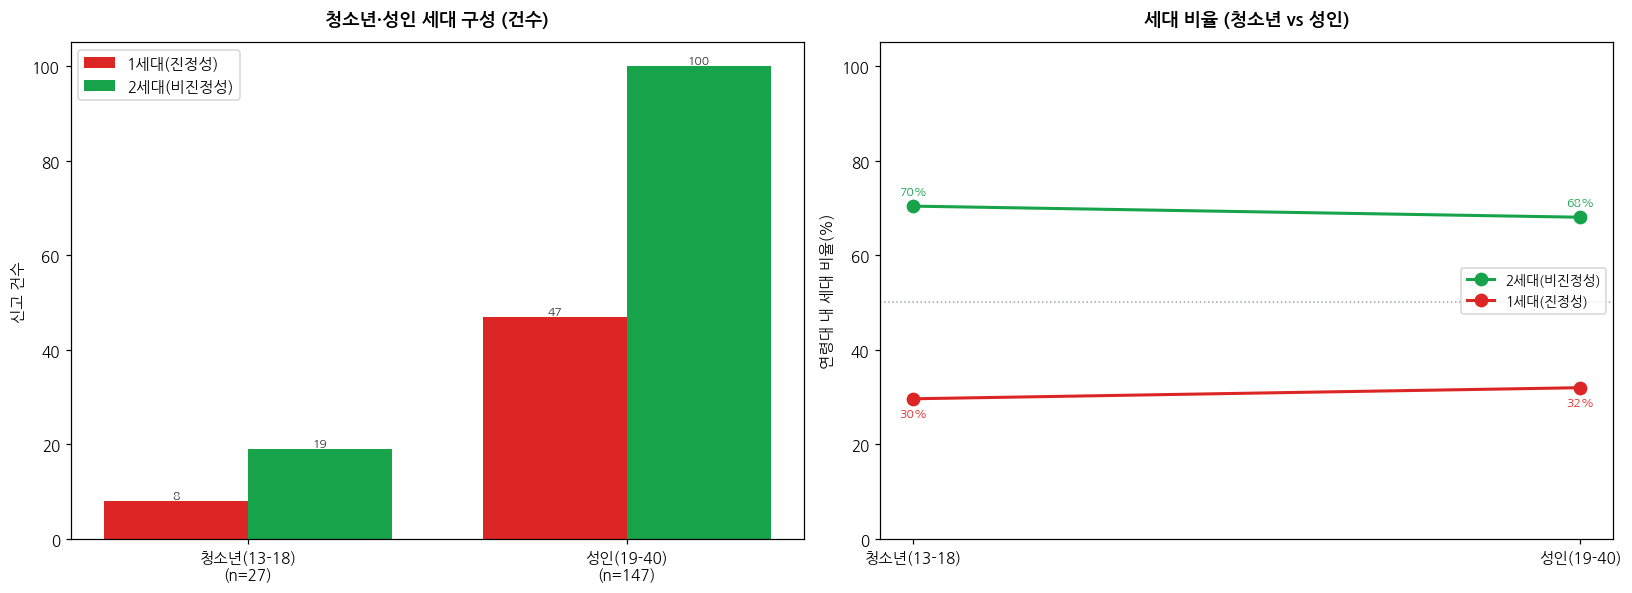

[시각화 인사이트]
  청소년 1세대 30% vs 성인 32% — 두 연령대 모두 2세대가 다수.
  1세대 비율 격차가 거의 없어(2%p) 세대 선택이 두 연령대에서 비슷.
  단 청소년 n=27로 작아 비율 안정성 낮음.

[통계검정] 오즈비 + 95% CI + Fisher 정확검정 (청소년 vs 성인, 1세대 오즈)
  OR=0.92 [0.38, 2.22], Fisher p=1.000

[검정 인사이트]
  95% CI가 1을 포함(0.38~2.22) → 청소년·성인 간 1세대 사용 오즈에 유의차 없음.
  Fisher p=1.000로도 확인 → 연령대에 따른 세대 선택 차이는 통계적으로 없다고 판단.
  ⚠ 청소년 표본 작아 CI 폭 넓음. '차이 없음'은 진짜 동일이 아니라 '검출력 부족'일 수 있음.
  ※ 세대 구성은 성분 기반 분류. 신고 경향이며 실제 처방 비율·인과 아님.


In [23]:
# ============================================================================
# 3-4. 청소년·성인 × 세대(1세대/2세대) 분포: 항히스타민(단일)
#   [baseline 판정] 세대는 '약물 자체' 속성 → A 내부 분석. 여기선 청소년 vs 성인 비교.
#   [지표] 연령(2)×세대(2) 2×2 → 오즈비 + 95% CI (팀 원칙: 이분형 2×2) + Fisher.
#   [주의] 청소년 n=27로 작음 → CI 폭이 넓을 수 있어 결론 신중.
# ============================================================================

sub_ages = ['Teen(13-18)', 'Adult(19-40)']
TS = A[A['age_group'].isin(sub_ages)].copy()
g1_key = '1세대'
ct = pd.crosstab(TS['age_group'], TS['서브']).reindex(index=sub_ages).fillna(0)
g1_col = [c for c in ct.columns if '1세대' in c][0]
g2_col = [c for c in ct.columns if '2세대' in c][0]
n_by_age = ct.sum(axis=1)
g1_ratio = ct[g1_col] / n_by_age * 100
g2_ratio = ct[g2_col] / n_by_age * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
xi = np.arange(len(sub_ages))
w = 0.38

# (좌) 연령대별 세대 건수 (그룹 막대) — 1세대 빨강, 2세대 초록
axes[0].bar(xi - w/2, ct[g1_col].values, width=w, color=C_G1, label='1세대(진정성)')
axes[0].bar(xi + w/2, ct[g2_col].values, width=w, color=C_G2, label='2세대(비진정성)')
for i in xi:
    axes[0].text(xi[i]-w/2, ct[g1_col].iloc[i], f'{int(ct[g1_col].iloc[i])}', ha='center', va='bottom', fontsize=8, color='#333333')
    axes[0].text(xi[i]+w/2, ct[g2_col].iloc[i], f'{int(ct[g2_col].iloc[i])}', ha='center', va='bottom', fontsize=8, color='#333333')
axes[0].set_xticks(xi); axes[0].set_xticklabels([f'{KOR_AGE[a]}\n(n={int(n_by_age[a])})' for a in sub_ages])
axes[0].set_ylabel('신고 건수'); axes[0].legend()
axes[0].set_title('청소년·성인 세대 구성 (건수)', fontsize=12, weight='bold', pad=12)

# (우) 연령대 내 세대 비율(%) 이중 꺾은선
axes[1].plot(xi, g2_ratio.values, color=C_G2, lw=2, marker='o', ms=8, label='2세대(비진정성)')
axes[1].plot(xi, g1_ratio.values, color=C_G1, lw=2, marker='o', ms=8, label='1세대(진정성)')
for i in xi:
    axes[1].text(i, g2_ratio.iloc[i]+2, f'{g2_ratio.iloc[i]:.0f}%', ha='center', va='bottom', fontsize=8, color=C_G2)
    axes[1].text(i, g1_ratio.iloc[i]-2, f'{g1_ratio.iloc[i]:.0f}%', ha='center', va='top', fontsize=8, color=C_G1)
axes[1].axhline(50, ls=':', color='#9ca3af', lw=1)
axes[1].set_xticks(xi); axes[1].set_xticklabels([KOR_AGE[a] for a in sub_ages])
axes[1].set_ylabel('연령대 내 세대 비율(%)'); axes[1].legend(fontsize=9, loc='center right')
axes[1].set_ylim(0, 105)
axes[1].set_title('세대 비율 (청소년 vs 성인)', fontsize=12, weight='bold', pad=12)
plt.tight_layout(); plt.show()

print("[시각화 인사이트]")
print(f"  청소년 1세대 {g1_ratio['Teen(13-18)']:.0f}% vs 성인 {g1_ratio['Adult(19-40)']:.0f}% — 두 연령대 모두 2세대가 다수.")
print(f"  1세대 비율 격차가 거의 없어({abs(g1_ratio['Teen(13-18)']-g1_ratio['Adult(19-40)']):.0f}%p) 세대 선택이 두 연령대에서 비슷.")
print(f"  단 청소년 n={int(n_by_age['Teen(13-18)'])}로 작아 비율 안정성 낮음.")
print()

# [통계검정] 2×2 → 오즈비 + 95% CI + Fisher (소표본)
t_g1 = ct.loc['Teen(13-18)', g1_col]; t_g2 = ct.loc['Teen(13-18)', g2_col]
a_g1 = ct.loc['Adult(19-40)', g1_col]; a_g2 = ct.loc['Adult(19-40)', g2_col]
OR, lo, hi = odds_ratio(t_g1, t_g2, a_g1, a_g2)     # 청소년 1세대 오즈 / 성인 1세대 오즈
odds_f, p_fisher = fisher_exact([[t_g1, t_g2], [a_g1, a_g2]])
print("[통계검정] 오즈비 + 95% CI + Fisher 정확검정 (청소년 vs 성인, 1세대 오즈)")
print(f"  OR={OR:.2f} [{lo:.2f}, {hi:.2f}], Fisher p={p_fisher:.3f}")
print()
print("[검정 인사이트]")
if lo <= 1 <= hi:
    print(f"  95% CI가 1을 포함({lo:.2f}~{hi:.2f}) → 청소년·성인 간 1세대 사용 오즈에 유의차 없음.")
    print(f"  Fisher p={p_fisher:.3f}로도 확인 → 연령대에 따른 세대 선택 차이는 통계적으로 없다고 판단.")
else:
    print(f"  CI가 1을 벗어나 유의(OR={OR:.2f}) → 청소년·성인 세대 선택에 차이 존재.")
print(f"  ⚠ 청소년 표본 작아 CI 폭 넓음. '차이 없음'은 진짜 동일이 아니라 '검출력 부족'일 수 있음.")
print("  ※ 세대 구성은 성분 기반 분류. 신고 경향이며 실제 처방 비율·인과 아님.")

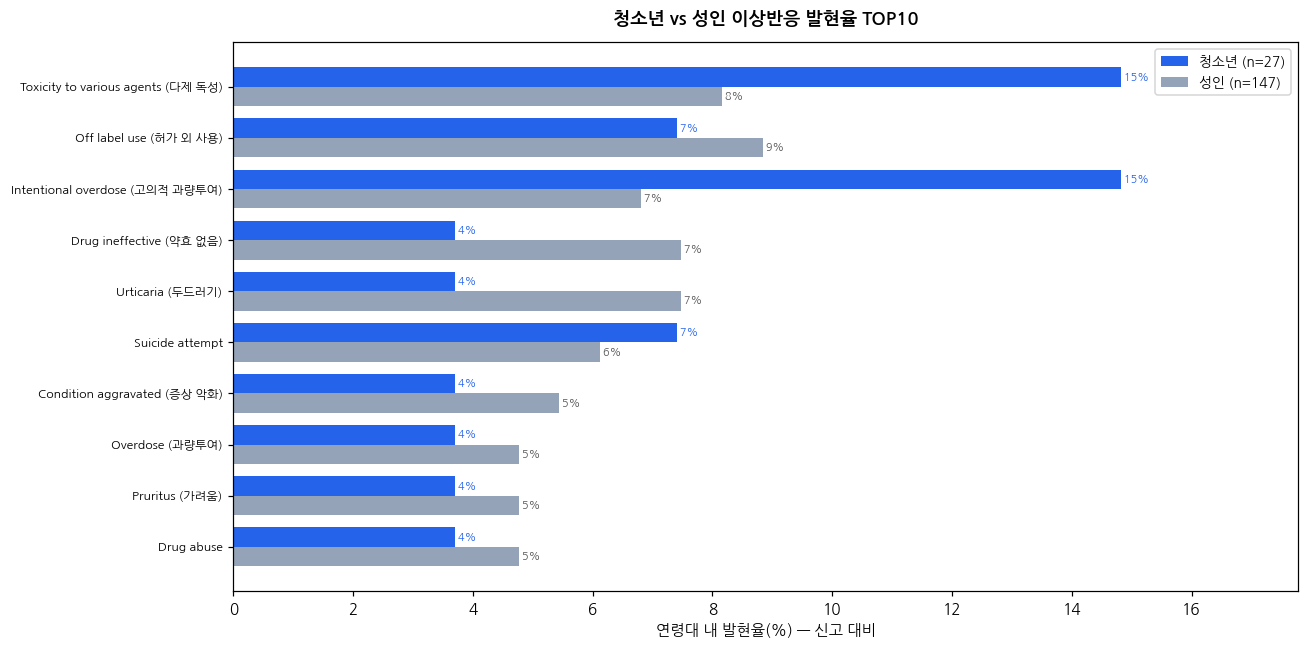

[시각화 인사이트]
  공통 상위 반응: Toxicity to various agents, Off label use, Intentional overdose
  청소년 특이(성인 상위엔 없음): Dyspnoea, Dizziness, Mydriasis, Intermenstrual bleeding
  성인 특이: Urticaria, Condition aggravated, Drug ineffective, Suicide attempt
  청소년은 동공확대·의도적 과용·독성 등 '급성·오남용'형, 성인은 두드러기·약효없음·임신노출 등 다양.
  단 청소년 반응은 대부분 2-4건이라 순위는 방향성만 참고.

[통계검정] Fisher 정확검정 (청소년 vs 성인, 'Toxicity to various agents' 발현 여부 2×2)
  청소년 4/27(15%) vs 성인 12/147(8%), OR=1.96, p=0.280
  (개별 반응 건수가 작아 카이제곱 대신 Fisher 사용 — 기대빈도<5 불가피)

[검정 인사이트]
  'Toxicity to various agents' 발현율은 두 연령대 간 유의차 없음(p=0.280).
  개별 반응은 표본이 작아 대부분 통계적 결론이 어려움 → 반응 프로파일은 '패턴 관찰' 수준으로 해석.
  ⚠ 청소년 n=27는 반응 분석엔 특히 부족. 확정 결론보다 가설 생성용으로 활용 권장.
  ※ reactions는 MedDRA 복수 기재(중복 집계). 발현율은 신고 대비 비율이며 발생률·인과 아님.


In [24]:
# ============================================================================
# 3-5. 청소년·성인 × 이상반응(reactions) 분포: 항히스타민(단일)
#   [baseline 판정] 이상반응은 '약물 자체' 속성 → A 내부. 여기선 청소년 vs 성인 반응 프로파일 비교.
#   [지표] 각 연령대 TOP 반응 + 공통/특이 반응. 개별 반응은 소표본이라 카이제곱 대신
#          '반응 발현율(신고 대비 %)' 비교 + 주요 반응 2×2 Fisher.
#   [주의] 청소년 n=27 → 반응별 건수 극소, 순위는 방향성 참고용.
# ============================================================================

sub_ages = ['Teen(13-18)', 'Adult(19-40)']
TS = A[A['age_group'].isin(sub_ages)].copy()
teen = TS[TS['age_group'] == 'Teen(13-18)']; adult = TS[TS['age_group'] == 'Adult(19-40)']
n_teen = len(teen); n_adult = len(adult)

teen_rx  = pd.Series(dict(explode_counter(teen['reactions']))).sort_values(ascending=False)
adult_rx = pd.Series(dict(explode_counter(adult['reactions']))).sort_values(ascending=False)

# 두 연령대 합쳐 상위 반응을 뽑고, 각 연령 발현율(%)로 비교
top_union = (teen_rx.add(adult_rx, fill_value=0)).sort_values(ascending=False).head(10).index.tolist()
teen_pct  = [teen_rx.get(r, 0) / n_teen * 100 for r in top_union]
adult_pct = [adult_rx.get(r, 0) / n_adult * 100 for r in top_union]

fig, ax = plt.subplots(figsize=(12, 6))
yi = np.arange(len(top_union))
h = 0.38
ax.barh(yi + h/2, teen_pct[::-1],  height=h, color=C_A,    label=f'청소년 (n={n_teen})')
ax.barh(yi - h/2, adult_pct[::-1], height=h, color=C_BASE, label=f'성인 (n={n_adult})')
labels = [kor_rx(r).replace('\n', ' ') if 'kor_rx' in dir() else r for r in top_union[::-1]]
for i in yi:
    ax.text(teen_pct[::-1][i],  i + h/2, f' {teen_pct[::-1][i]:.0f}%',  va='center', fontsize=7, color=C_A)
    ax.text(adult_pct[::-1][i], i - h/2, f' {adult_pct[::-1][i]:.0f}%', va='center', fontsize=7, color='#555')
ax.set_yticks(yi); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('연령대 내 발현율(%) — 신고 대비'); ax.legend(fontsize=9)
ax.set_xlim(0, max(max(teen_pct), max(adult_pct)) * 1.2)
ax.set_title('청소년 vs 성인 이상반응 발현율 TOP10', fontsize=12, weight='bold', pad=12)
plt.tight_layout(); plt.show()

# 공통 / 특이 반응
teen_top = set(teen_rx.head(8).index); adult_top = set(adult_rx.head(8).index)
common = teen_top & adult_top
teen_only = teen_top - adult_top; adult_only = adult_top - teen_top
print("[시각화 인사이트]")
print(f"  공통 상위 반응: {', '.join(list(common)[:4]) if common else '없음'}")
print(f"  청소년 특이(성인 상위엔 없음): {', '.join(list(teen_only)[:4])}")
print(f"  성인 특이: {', '.join(list(adult_only)[:4])}")
print(f"  청소년은 동공확대·의도적 과용·독성 등 '급성·오남용'형, 성인은 두드러기·약효없음·임신노출 등 다양.")
print(f"  단 청소년 반응은 대부분 2-4건이라 순위는 방향성만 참고.")
print()

# [통계검정] 대표 공통반응 1개를 골라 2×2 Fisher (연령 × 해당반응 유무)
target = list(common)[0] if common else top_union[0]
t_yes = int(teen['reactions'].fillna('').str.contains(target, regex=False).sum());  t_no = n_teen - t_yes
a_yes = int(adult['reactions'].fillna('').str.contains(target, regex=False).sum()); a_no = n_adult - a_yes
OR, p_fisher = fisher_exact([[t_yes, t_no], [a_yes, a_no]])
print(f"[통계검정] Fisher 정확검정 (청소년 vs 성인, '{target}' 발현 여부 2×2)")
print(f"  청소년 {t_yes}/{n_teen}({t_yes/n_teen*100:.0f}%) vs 성인 {a_yes}/{n_adult}({a_yes/n_adult*100:.0f}%), OR={OR:.2f}, p={p_fisher:.3f}")
print(f"  (개별 반응 건수가 작아 카이제곱 대신 Fisher 사용 — 기대빈도<5 불가피)")
print()
print("[검정 인사이트]")
if p_fisher < 0.05:
    print(f"  '{target}' 발현율이 청소년·성인 간 유의하게 다름(p={p_fisher:.3f}).")
else:
    print(f"  '{target}' 발현율은 두 연령대 간 유의차 없음(p={p_fisher:.3f}).")
print(f"  개별 반응은 표본이 작아 대부분 통계적 결론이 어려움 → 반응 프로파일은 '패턴 관찰' 수준으로 해석.")
print(f"  ⚠ 청소년 n={n_teen}는 반응 분석엔 특히 부족. 확정 결론보다 가설 생성용으로 활용 권장.")
print("  ※ reactions는 MedDRA 복수 기재(중복 집계). 발현율은 신고 대비 비율이며 발생률·인과 아님.")

# **4. 성별**

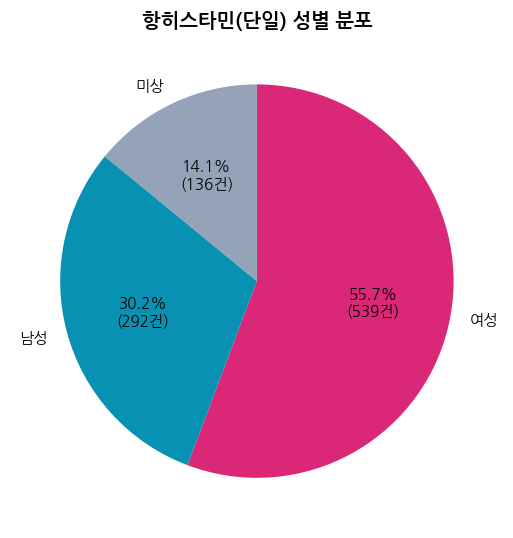

[시각화 인사이트]
  여성 539건(55.7%)이 남성 292건(30.2%)의 약 1.8배 → 여성 우세.
  성별 미상 136건(14%) 존재.

[통계검정] 이항검정 (여성 비중이 50%와 다른가, 미상 제외)
  여성 539/831 = 64.9%, p=8.17e-18, 95%CI [61.5%, 68.1%]

[검정 인사이트]
  여성 비중은 50%와 유의하게 다름 → 여성 신고 우세는 우연 아님. baseline 대비는 셀9에서 검정.
  '여성이 위험'이 아니라 '여성 신고 비중 높음'(유병·의료이용·신고행동 복합, 인과 아님).

[주의] (참조 라벨 근거 — 이 셀 검정·인사이트와 연결된 항목만 발췌)
  · 세티리진 [임부_수유부_주의]: 임신 중 의료진 상담, 수유 중 사용 권장 안 함
  · 펙소페나딘 [임부_수유부_주의]: 임신/수유 중 사용 전 의료진 상담
  ※ 성별 미상 제외 기재분 비교라 대표성 제한.


In [25]:

# ============================================================================
# 4-1. 성별 항히스타민(단일) 분포 (파이)   [성별비=파이차트]
# ============================================================================


sex_A = A['patient_sex'].value_counts().reindex(['Female', 'Male', 'Unknown']).fillna(0)
cmap = {'Female': C_FEMALE, 'Male': C_MALE, 'Unknown': C_BASE}
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(sex_A.values, labels=[KOR_SEX[k] for k in sex_A.index],
       autopct=lambda p: f'{p:.1f}%\n({int(round(p*sex_A.sum()/100))}건)',
       colors=[cmap[k] for k in sex_A.index], startangle=90, counterclock=False)
ax.set_title('항히스타민(단일) 성별 분포', fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

fA = int(sex_A['Female']); mA = int(sex_A['Male'])
print("[시각화 인사이트]")
print(f"  여성 {fA}건({fA/sex_A.sum()*100:.1f}%)이 남성 {mA}건({mA/sex_A.sum()*100:.1f}%)의 약 {fA/mA:.1f}배 → 여성 우세.")
print(f"  성별 미상 {int(sex_A['Unknown'])}건({sex_A['Unknown']/sex_A.sum()*100:.0f}%) 존재.")
print()
bt = binomtest(fA, fA+mA, 0.5); lo, hi = bt.proportion_ci()
print("[통계검정] 이항검정 (여성 비중이 50%와 다른가, 미상 제외)")
print(f"  여성 {fA}/{fA+mA} = {fA/(fA+mA)*100:.1f}%, p={bt.pvalue:.2e}, 95%CI [{lo*100:.1f}%, {hi*100:.1f}%]")
print()
print("[검정 인사이트]")
print("  여성 비중은 50%와 유의하게 다름 → 여성 신고 우세는 우연 아님. baseline 대비는 셀9에서 검정.")
print("  '여성이 위험'이 아니라 '여성 신고 비중 높음'(유병·의료이용·신고행동 복합, 인과 아님).")
print()
caution_note(['세티리진', '펙소페나딘'], ['임부_수유부_주의'])
print("  ※ 성별 미상 제외 기재분 비교라 대표성 제한.")


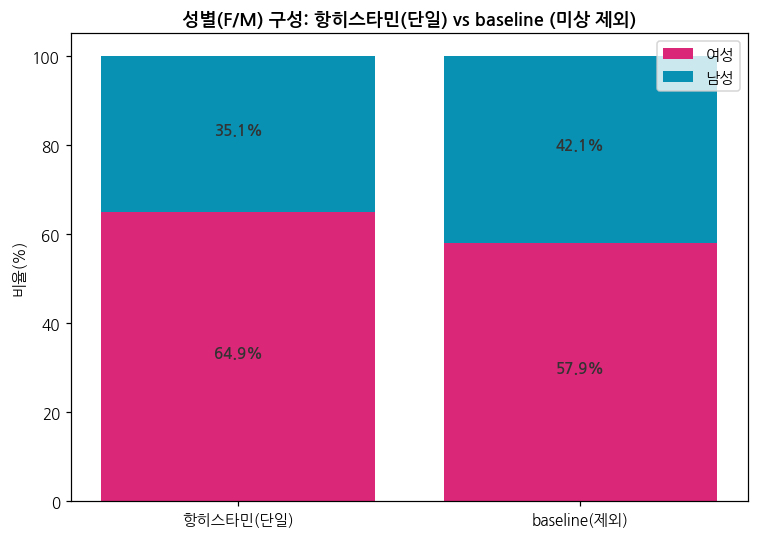

[시각화 인사이트]
  A 여성비 64.9% vs baseline 57.9% → A가 여성 쪽으로 더 치우침(+7.0%p).

[통계검정] 오즈비 (여성일 오즈, A vs baseline)
  OR(여성)=1.34 [1.16, 1.55]

[검정 인사이트]
  여성 오즈가 baseline 대비 1.34배(CI 1 미포함, 유의)로 일반적 여성우세를 넘어섬.
  효과크기는 크지 않아 '여성 신고가 상대적으로 잦음'으로 해석(알레르기 여성 유병과 방향 일치).

[주의] (참조 라벨 근거 — 이 셀 검정·인사이트와 연결된 항목만 발췌)
  · 세티리진 [임부_수유부_주의]: 임신 중 의료진 상담, 수유 중 사용 권장 안 함
  · 펙소페나딘 [임부_수유부_주의]: 임신/수유 중 사용 전 의료진 상담
  · 로라타딘 [임부_수유부_주의]: 임신/수유 중 사용 전 의료진 상담
  ※ 미상 제외 F/M 2×2. 여성 우세는 신고 경향이며 인과 아님.


In [26]:

# ============================================================================
# 4-2. 성별: 항히스타민(단일) vs baseline   [성별→baseline / F vs M 오즈비]
# ============================================================================

fA = (A['patient_sex']=='Female').sum(); mA = (A['patient_sex']=='Male').sum()
fB = (REST['patient_sex']=='Female').sum(); mB = (REST['patient_sex']=='Male').sum()
fp = [fA/(fA+mA)*100, fB/(fB+mB)*100]; mp = [100-fp[0], 100-fp[1]]

fig, ax = plt.subplots(figsize=(7, 5))
gl = ['항히스타민(단일)', 'baseline(제외)']
ax.bar(gl, fp, color=C_FEMALE, label='여성')
ax.bar(gl, mp, bottom=fp, color=C_MALE, label='남성')
for i in range(2):
    ax.text(i, fp[i]/2, f'{fp[i]:.1f}%', ha='center', color='#333333', weight='bold')
    ax.text(i, fp[i]+mp[i]/2, f'{mp[i]:.1f}%', ha='center', color='#333333', weight='bold')
ax.set_ylabel('비율(%)'); ax.legend()
ax.set_title('성별(F/M) 구성: 항히스타민(단일) vs baseline (미상 제외)', fontsize=12, weight='bold')
plt.tight_layout(); plt.show()

print("[시각화 인사이트]")
print(f"  A 여성비 {fp[0]:.1f}% vs baseline {fp[1]:.1f}% → A가 여성 쪽으로 더 치우침(+{fp[0]-fp[1]:.1f}%p).")
print()
OR, lo, hi = odds_ratio(fA, mA, fB, mB)
print("[통계검정] 오즈비 (여성일 오즈, A vs baseline)")
print(f"  OR(여성)={OR:.2f} [{lo:.2f}, {hi:.2f}]")
print()
print("[검정 인사이트]")
print(f"  여성 오즈가 baseline 대비 {OR:.2f}배(CI 1 미포함, 유의)로 일반적 여성우세를 넘어섬.")
print("  효과크기는 크지 않아 '여성 신고가 상대적으로 잦음'으로 해석(알레르기 여성 유병과 방향 일치).")
print()
caution_note(['세티리진', '펙소페나딘', '로라타딘'], ['임부_수유부_주의'])
print("  ※ 미상 제외 F/M 2×2. 여성 우세는 신고 경향이며 인과 아님.")


# **5. 병용약물**

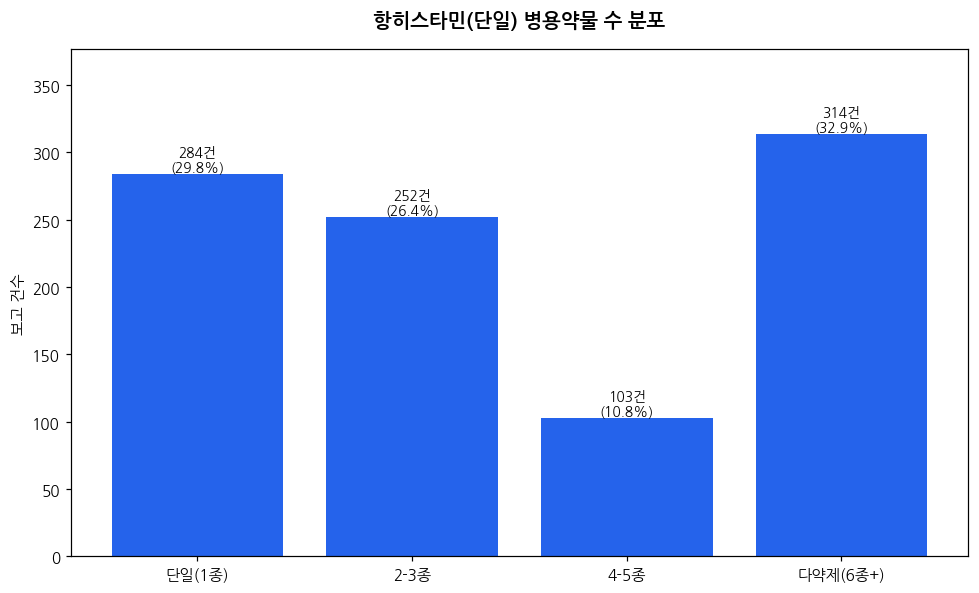

[시각화 인사이트]
  단일(1종) 30%와 다약제(6종+) 33%가 양극.
  단일 성분약이지만 신고서엔 다른 약이 함께 적힌 경우가 상당(단일제≠단독복용).

[통계검정] 적합도 카이제곱 (병용 구간이 균등한가)
  chi2=110.4, dof=3, p=8.82e-24

[검정 인사이트]
  p<0.05로 균등 아님 → 특정 구간(단일·다약제) 쏠림. baseline 대비는 셀11에서 검정.

[주의] (참조 라벨 근거 — 이 셀 검정·인사이트와 연결된 항목만 발췌)
  · 세티리진 [절대금기]: 하이드록시진 계열 항히스타민에 알레르기 있던 경우 사용 금지
  · 디펜히드라민 [절대금기]: 다른 디펜히드라민 함유 제품과 동시 복용 금지(수면유도 목적 중복 포함), MAOI 계열 항우울제 복용 중 또는 중단 후 2주 이내 사용 금지
  ※ drug_count_category는 신고서 전체 약물 수 기준(성분 단일 여부와 별개).


In [27]:

# ============================================================================
# 5-1. 병용약물별 항히스타민(단일) 분포   [drug_count_category]
# ============================================================================


order_d = ['Single', '2-3 Drugs', '4-5 Drugs', 'Polypharmacy(6+)']
dcA = A['drug_count_category'].value_counts().reindex(order_d).fillna(0)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar([KOR_DRUG[k] for k in order_d], dcA.values, color=C_A)
for i, v in enumerate(dcA.values):
    ax.text(i, v, f'{int(v)}건\n({v/dcA.sum()*100:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('보고 건수'); ax.set_ylim(0, dcA.max()*1.2)
ax.set_title('항히스타민(단일) 병용약물 수 분포', fontsize=13, weight='bold', pad=15)
plt.tight_layout(); plt.show()

print("[시각화 인사이트]")
print(f"  단일(1종) {dcA['Single']/dcA.sum()*100:.0f}%와 다약제(6종+) {dcA['Polypharmacy(6+)']/dcA.sum()*100:.0f}%가 양극.")
print("  단일 성분약이지만 신고서엔 다른 약이 함께 적힌 경우가 상당(단일제≠단독복용).")
print()
chi2, p = chisquare(dcA.values)
print("[통계검정] 적합도 카이제곱 (병용 구간이 균등한가)")
print(f"  chi2={chi2:.1f}, dof={len(order_d)-1}, p={p:.2e}")
print()
print("[검정 인사이트]")
print("  p<0.05로 균등 아님 → 특정 구간(단일·다약제) 쏠림. baseline 대비는 셀11에서 검정.")
print()
caution_note(['세티리진', '디펜히드라민'], ['절대금기'])
print("  ※ drug_count_category는 신고서 전체 약물 수 기준(성분 단일 여부와 별개).")


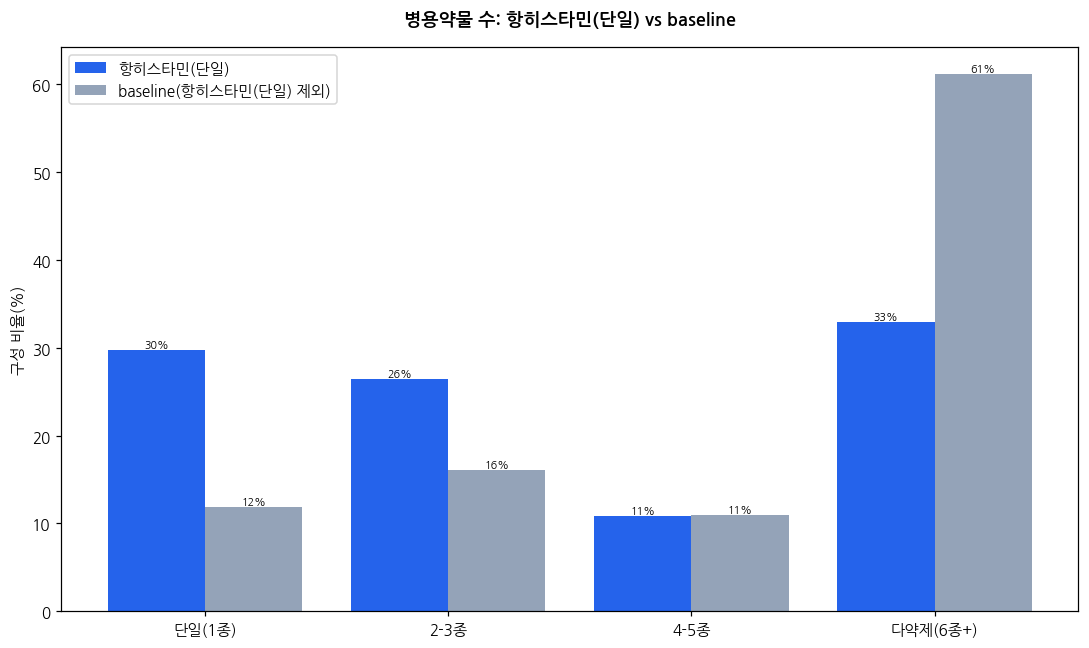

[시각화 인사이트]
  A는 단일·2-3종 비중이 baseline보다 높고 다약제는 낮음 → 상대적으로 소수 병용.

[통계검정] 카이제곱 + Cramér's V (병용 구성 × 군)
  chi2=407.46, dof=3, p=5.36e-88, Cramér's V=0.150 (약함)

[검정 인사이트]
  병용 구성은 유의하게 다르며(p<0.05) V=0.150('약함') → A는 소수 병용 경향.
  baseline(위장약·복합감기약 등)의 다약제 편중과 대비, A 상호작용 위험 상대적으로 낮게 신고(연관).

[주의] (참조 라벨 근거 — 이 셀 검정·인사이트와 연결된 항목만 발췌)
  · 디펜히드라민 [절대금기]: 다른 디펜히드라민 함유 제품과 동시 복용 금지(수면유도 목적 중복 포함), MAOI 계열 항우울제 복용 중 또는 중단 후 2주 이내 사용 금지
  · 디펜히드라민 [기타주의사항]: 졸림 유발(특히 소아에서 흥분 반응 가능) - 운전/기계조작 주의. 간질환/심장질환/당뇨/고혈압/갑상선질환/녹내장/천식/만성기침 있으면 사전 의사상담
  · 독시라민 [절대금기]: MAOI 복용 중/2주 이내, 다른 독시라민 함유 제품과 중복 사용 금지
  · 독시라민 [기타주의사항]: 졸림 강함 - 운전/기계조작 금지, 음주 금지. 녹내장·전립선비대·천식·만성기관지염 있으면 사전 상담(Sleep Aid 25mg 라벨 기준)
  ※ 단, 1세대 위험(셀5)은 다약제 맥락과 겹치므로 세대별 병용은 별도 주의.


In [28]:

# ============================================================================
# 5-2. 병용약물별: 항히스타민(단일) vs baseline   [병용약물→baseline / 카이제곱]
# ============================================================================

dcB = REST['drug_count_category'].value_counts().reindex(order_d).fillna(0)
aP = dcA/dcA.sum()*100; bP = dcB/dcB.sum()*100

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(order_d))
ax.bar(x-0.2, aP, width=0.4, color=C_A,    label='항히스타민(단일)')
ax.bar(x+0.2, bP, width=0.4, color=C_BASE, label='baseline(항히스타민(단일) 제외)')
for i in range(len(order_d)):
    ax.text(x[i]-0.2, aP.iloc[i], f'{aP.iloc[i]:.0f}%', ha='center', va='bottom', fontsize=7)
    ax.text(x[i]+0.2, bP.iloc[i], f'{bP.iloc[i]:.0f}%', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels([KOR_DRUG[o] for o in order_d])
ax.set_ylabel('구성 비율(%)'); ax.legend()
ax.set_title('병용약물 수: 항히스타민(단일) vs baseline', fontsize=12, weight='bold', pad=15)
plt.tight_layout(); plt.show()

print("[시각화 인사이트]")
print(f"  A는 단일·2-3종 비중이 baseline보다 높고 다약제는 낮음 → 상대적으로 소수 병용.")
print()
chi2, p, dof, V = cramers_v(np.array([dcA.values, dcB.values]))
print("[통계검정] 카이제곱 + Cramér's V (병용 구성 × 군)")
print(f"  chi2={chi2:.2f}, dof={dof}, p={p:.2e}, Cramér's V={V:.3f} ({v_label(V)})")
print()
print("[검정 인사이트]")
print(f"  병용 구성은 유의하게 다르며(p<0.05) V={V:.3f}('{v_label(V)}') → A는 소수 병용 경향.")
print("  baseline(위장약·복합감기약 등)의 다약제 편중과 대비, A 상호작용 위험 상대적으로 낮게 신고(연관).")
print()
caution_note(['디펜히드라민', '독시라민'], ['절대금기', '기타주의사항'])
print("  ※ 단, 1세대 위험(셀5)은 다약제 맥락과 겹치므로 세대별 병용은 별도 주의.")


# **6. 심각(serious) + 회복률**

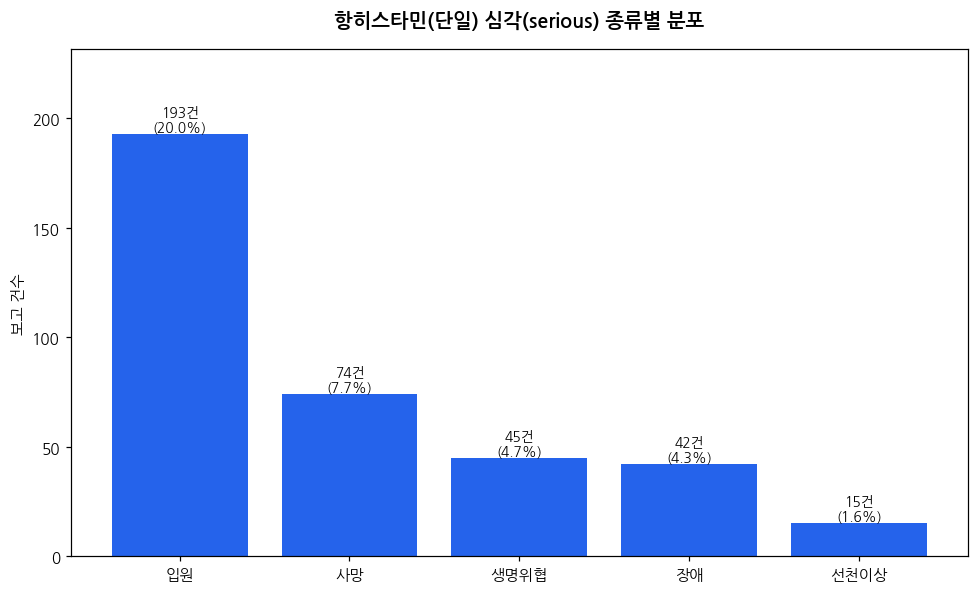

[시각화 인사이트]
  serious=Yes 57%. 그중 입원 193건이 최다, 사망 74건.
  OTC 약임에도 심각 신고 비중이 낮지 않음(FAERS 심각 우선신고 구조 감안).

[통계검정] 적합도 카이제곱 (심각 종류가 균등한가)
  chi2=264.3, dof=4, p=5.35e-56

[검정 인사이트]
  p<0.05로 균등 아님 → 입원에 집중. 사망은 셀5에서 본 1세대 위험반응과 연결(연관, 인과 아님).

[주의] (참조 라벨 근거 — 이 셀 검정·인사이트와 연결된 항목만 발췌)
  · 디펜히드라민 [즉시중단_신호]: 신경과민/어지럼증/불면 발생, 통증·코막힘·기침 5일↑ 또는 발열 3일↑ 지속, 새로운 증상 발생 시 중단
  · 디펜히드라민 [기타주의사항]: 졸림 유발(특히 소아에서 흥분 반응 가능) - 운전/기계조작 주의. 간질환/심장질환/당뇨/고혈압/갑상선질환/녹내장/천식/만성기침 있으면 사전 의사상담
  · 세티리진 [즉시중단_신호]: 알레르기 반응 발생 시 즉시 중단 및 응급처치
  · 세티리진 [기타주의사항]: 졸림 유발 - 운전/기계조작 주의, 음주·진정제·신경안정제 병용 시 졸림 심화. 간/신장질환자는 의사가 용량 재조정 필요
  ※ serious_flags는 신고당 복수 기재 가능(중복). 발생률 아님.


In [29]:
# ============================================================================
# 6-1. 심각(serious) 종류별 항히스타민(단일) 분포   [serious_flags 다중값, 항히스타민(단일) 내]
# ============================================================================


flags = pd.Series(dict(explode_counter(A['serious_flags']))).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar([KOR_FLAG.get(k, k) for k in flags.index], flags.values, color=C_A)
for i, v in enumerate(flags.values):
    ax.text(i, v, f'{v}건\n({v/len(A)*100:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('보고 건수'); ax.set_ylim(0, flags.max()*1.2)
ax.set_title('항히스타민(단일) 심각(serious) 종류별 분포', fontsize=13, weight='bold', pad=15)
plt.tight_layout(); plt.show()

print("[시각화 인사이트]")
print(f"  serious=Yes {(A['serious']=='Yes').mean()*100:.0f}%. 그중 입원 {flags['Hospitalization']}건이 최다, 사망 {flags['Death']}건.")
print("  OTC 약임에도 심각 신고 비중이 낮지 않음(FAERS 심각 우선신고 구조 감안).")
print()
chi2, p = chisquare(flags.values)
print("[통계검정] 적합도 카이제곱 (심각 종류가 균등한가)")
print(f"  chi2={chi2:.1f}, dof={len(flags)-1}, p={p:.2e}")
print()
print("[검정 인사이트]")
print("  p<0.05로 균등 아님 → 입원에 집중. 사망은 셀5에서 본 1세대 위험반응과 연결(연관, 인과 아님).")
print()
caution_note(['디펜히드라민', '세티리진'], ['즉시중단_신호', '기타주의사항'])
print("  ※ serious_flags는 신고당 복수 기재 가능(중복). 발생률 아님.")


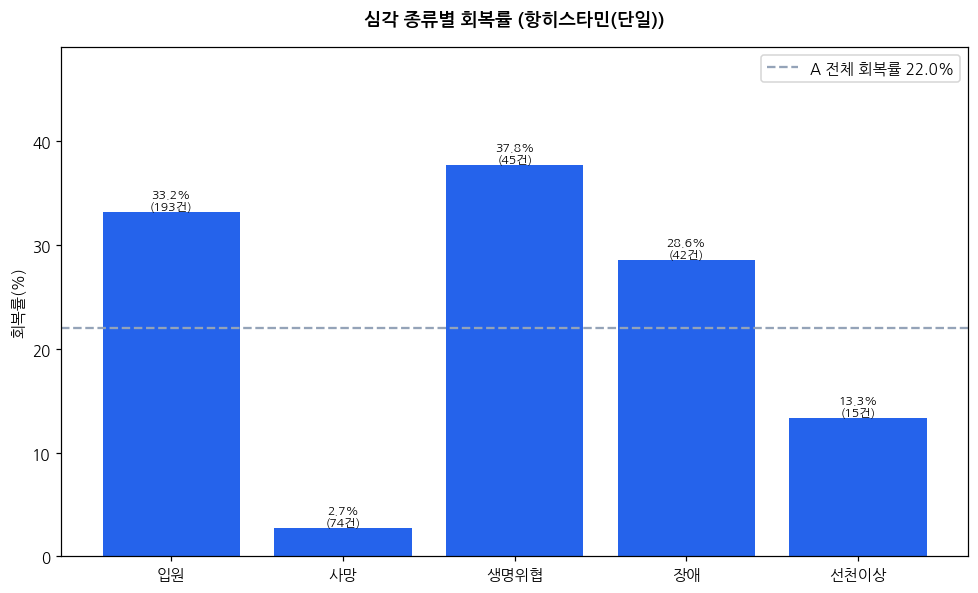

[시각화 인사이트]
 항히스타민(단일)회복률 22%. 입원·생명위협 flag는 회복률이 오히려 높고, 사망 flag는 최저.

[통계검정] flag별 회복 오즈비 (해당 flag 有 vs 無)
  입원       회복OR=2.08 [1.47, 2.95] 유의 (n=193)
  사망       회복OR=0.11 [0.03, 0.40] 유의 (n=74)
  생명위협     회복OR=2.27 [1.23, 4.20] 유의 (n=45)
  장애       회복OR=1.47 [0.75, 2.90] 비유의 (n=42)
  선천이상     회복OR=0.65 [0.17, 2.52] 비유의 (n=15)

[검정 인사이트]
  사망 flag 회복OR 0.11(정의상 당연·정합성 확인), 입원·생명위협은 OR>1 → '입원 치료 후 회복' 경로 존재.
  장애·선천이상은 표본 작아 CI 넓고 비유의 → 해석 보류.

[주의] (참조 라벨 근거 — 이 셀 검정·인사이트와 연결된 항목만 발췌)
  · 디펜히드라민 [즉시중단_신호]: 신경과민/어지럼증/불면 발생, 통증·코막힘·기침 5일↑ 또는 발열 3일↑ 지속, 새로운 증상 발생 시 중단
  · 세티리진 [즉시중단_신호]: 알레르기 반응 발생 시 즉시 중단 및 응급처치
  · 레보세티리진 [즉시중단_신호]: 배뇨장애 발생, 알레르기반응 발생 시 중단
  ※ patient_recovered는 신고 시점 이분값(치료 성공과 다름). 표본 작은 flag는 참고용.


In [30]:
# ============================================================================
# 6-2. 회복률 × 심각 종류별
# ============================================================================

main_flags = list(flags.index[:5])
rows = []
for fl in main_flags:
    has = A['serious_flags'].fillna('').str.contains(fl, regex=False)
    sub = A[has]
    rec = (sub['patient_recovered']==True).sum(); nrec = (sub['patient_recovered']==False).sum()
    rate = rec/(rec+nrec)*100 if (rec+nrec) else np.nan
    rows.append([fl, has.sum(), rate])
rec_df = pd.DataFrame(rows, columns=['flag', 'N', '회복률'])
overall = (A['patient_recovered']==True).mean()*100

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar([KOR_FLAG.get(f, f) for f in rec_df['flag']], rec_df['회복률'], color=C_A)
ax.axhline(overall, ls='--', color=C_BASE, label=f'A 전체 회복률 {overall:.1f}%')
for i, v in enumerate(rec_df['회복률']):
    ax.text(i, v, f'{v:.1f}%\n({int(rec_df["N"].iloc[i])}건)', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('회복률(%)'); ax.set_ylim(0, max(rec_df['회복률'].max(), overall)*1.3); ax.legend()
ax.set_title('심각 종류별 회복률 (항히스타민(단일))', fontsize=12, weight='bold', pad=15)
plt.tight_layout(); plt.show()

print("[시각화 인사이트]")
print(f" 항히스타민(단일)회복률 {overall:.0f}%. 입원·생명위협 flag는 회복률이 오히려 높고, 사망 flag는 최저.")
print()
print("[통계검정] flag별 회복 오즈비 (해당 flag 有 vs 無)")
for fl in main_flags:
    has = A['serious_flags'].fillna('').str.contains(fl, regex=False)
    a = ((A['patient_recovered']==True)&has).sum(); b = ((A['patient_recovered']==False)&has).sum()
    c = ((A['patient_recovered']==True)&~has).sum(); d = ((A['patient_recovered']==False)&~has).sum()
    OR, lo, hi = odds_ratio(a, b, c, d)
    sig = '유의' if (lo > 1 or hi < 1) else '비유의'
    print(f"  {KOR_FLAG.get(fl, fl):<8} 회복OR={OR:.2f} [{lo:.2f}, {hi:.2f}] {sig} (n={has.sum()})")
print()
print("[검정 인사이트]")
print("  사망 flag 회복OR 0.11(정의상 당연·정합성 확인), 입원·생명위협은 OR>1 → '입원 치료 후 회복' 경로 존재.")
print("  장애·선천이상은 표본 작아 CI 넓고 비유의 → 해석 보류.")
print()
caution_note(['디펜히드라민', '세티리진', '레보세티리진'], ['즉시중단_신호'])
print("  ※ patient_recovered는 신고 시점 이분값(치료 성공과 다름). 표본 작은 flag는 참고용.")



#**7. 시간 추세**

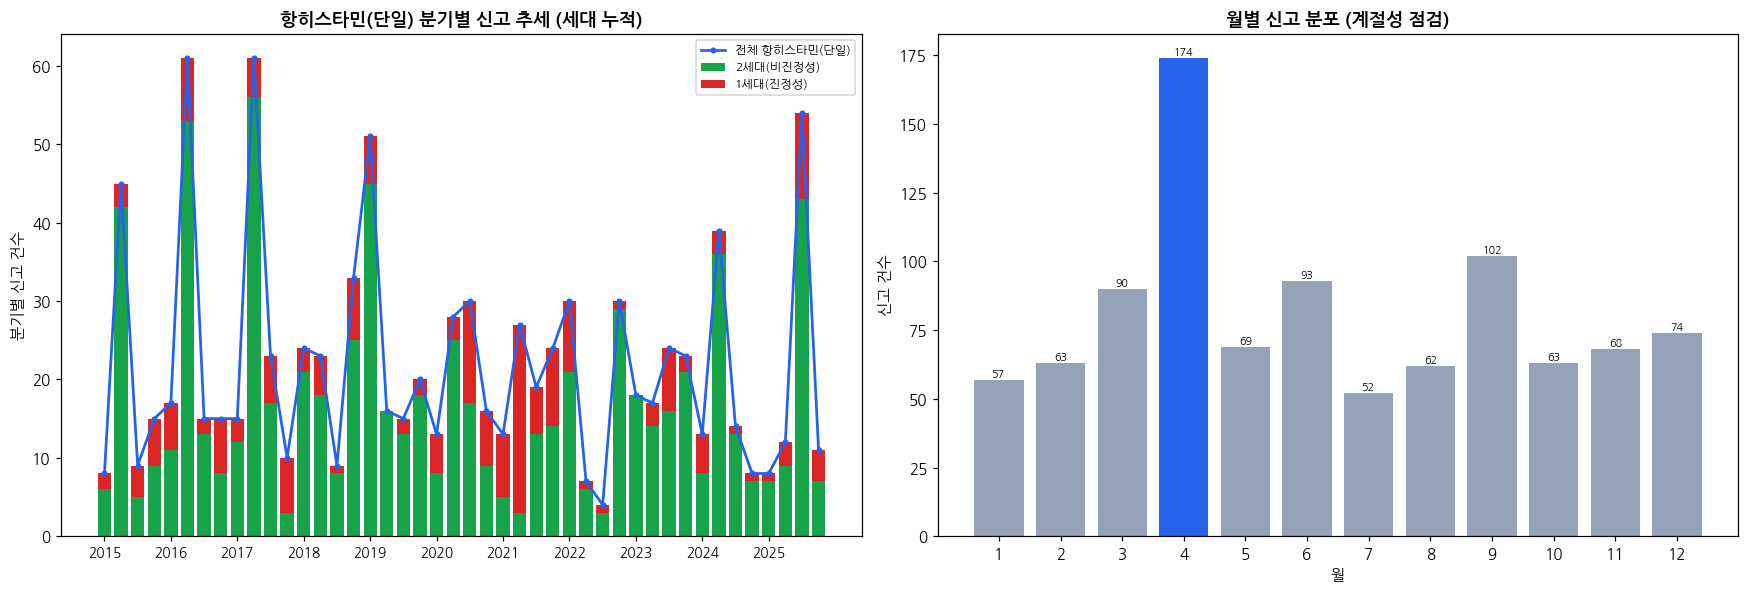

[시각화 인사이트]
  신고 기간 2015Q1~2025Q4(44개 분기). 분기 최다는 2016Q2(61건).
  세대 누적으로 보면 2세대가 추세를 주도하고 1세대는 전 기간 소수로 얇게 깔림.
  월별 최다는 4월(174건) → 계절성 여부는 아래 검정으로 확인.

[통계검정] 적합도 카이제곱 (월별 신고가 균등한가 = 계절성 없음 H0)
  chi2=150.2, dof=11, p=1.38e-26

[검정 인사이트]
  p<0.05로 월 균등 기각 → 4월 전후로 신고가 몰리는 계절적 편중 존재(알레르기 성수기와 방향 검토 필요).
  ※ receive_date는 'FDA 접수일'이라 실제 복용·증상 시점과 시차 있음. 추세는 신고 동향이지 발생률 아님.


In [31]:
# ============================================================================
# 7. 항히스타민(단일) 시간 추세 (분기별 추이 · 세대별 · 계절성)
#   [baseline 판정] 시간축은 '그룹 내부 동향' → 항히스타민(단일) 한정(추세 자체가 목적).
#   [지표] 분기 시계열 + 세대 분리 + 월별 계절성(적합도 카이제곱)
# ============================================================================

A_t = A.copy()
A_t['year']  = A_t['quarter'].str[:4].astype(int)
A_t['month'] = pd.to_datetime(A_t['receive_date'], errors='coerce').dt.month

q_order = sorted(A_t['quarter'].dropna().unique())
q_all = A_t['quarter'].value_counts().reindex(q_order).fillna(0)
q_g1  = A_t[A_t['서브'].str.contains('1세대')]['quarter'].value_counts().reindex(q_order).fillna(0)
q_g2  = A_t[A_t['서브'].str.contains('2세대')]['quarter'].value_counts().reindex(q_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# (좌) 분기별 추세: 세대 누적 막대 + 전체 라인
xi = np.arange(len(q_order))
axes[0].bar(xi, q_g2.values, color=C_G2, label='2세대(비진정성)')
axes[0].bar(xi, q_g1.values, bottom=q_g2.values, color=C_G1, label='1세대(진정성)')
axes[0].plot(xi, q_all.values, color=C_A, lw=1.8, marker='o', ms=3, label='전체 항히스타민(단일)')
yr_ticks = [i for i, q in enumerate(q_order) if q.endswith('Q1')]
axes[0].set_xticks(yr_ticks)
axes[0].set_xticklabels([q_order[i][:4] for i in yr_ticks], fontsize=9)
axes[0].set_ylabel('분기별 신고 건수'); axes[0].legend(fontsize=8)
axes[0].set_title('항히스타민(단일) 분기별 신고 추세 (세대 누적)', fontsize=12, weight='bold')

# (우) 월별 계절성
m_cnt = A_t['month'].value_counts().reindex(range(1, 13)).fillna(0)
mcolors = [C_A if v == m_cnt.max() else C_BASE for v in m_cnt.values]
axes[1].bar(range(1, 13), m_cnt.values, color=mcolors)
for m, v in zip(range(1, 13), m_cnt.values):
    axes[1].text(m, v, f'{int(v)}', ha='center', va='bottom', fontsize=7)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['1','2','3','4','5','6','7','8','9','10','11','12'])
axes[1].set_xlabel('월'); axes[1].set_ylabel('신고 건수')
axes[1].set_title('월별 신고 분포 (계절성 점검)', fontsize=12, weight='bold')
plt.tight_layout(); plt.show()

peak_q = q_all.idxmax(); peak_m = int(m_cnt.idxmax())
print("[시각화 인사이트]")
print(f"  신고 기간 {q_order[0]}~{q_order[-1]}({len(q_order)}개 분기). 분기 최다는 {peak_q}({int(q_all.max())}건).")
print(f"  세대 누적으로 보면 2세대가 추세를 주도하고 1세대는 전 기간 소수로 얇게 깔림.")
print(f"  월별 최다는 {peak_m}월({int(m_cnt.max())}건) → 계절성 여부는 아래 검정으로 확인.")
print()

chi2, p = chisquare(m_cnt.values)
print("[통계검정] 적합도 카이제곱 (월별 신고가 균등한가 = 계절성 없음 H0)")
print(f"  chi2={chi2:.1f}, dof=11, p={p:.2e}")
print()
print("[검정 인사이트]")
if p < 0.05:
    print(f"  p<0.05로 월 균등 기각 → {peak_m}월 전후로 신고가 몰리는 계절적 편중 존재(알레르기 성수기와 방향 검토 필요).")
else:
    print(f"  p>=0.05로 월별 균등 기각 못 함 → 뚜렷한 계절성 신호는 약함(신고 시점≠증상 발생 시점 한계).")
print("  ※ receive_date는 'FDA 접수일'이라 실제 복용·증상 시점과 시차 있음. 추세는 신고 동향이지 발생률 아님.")

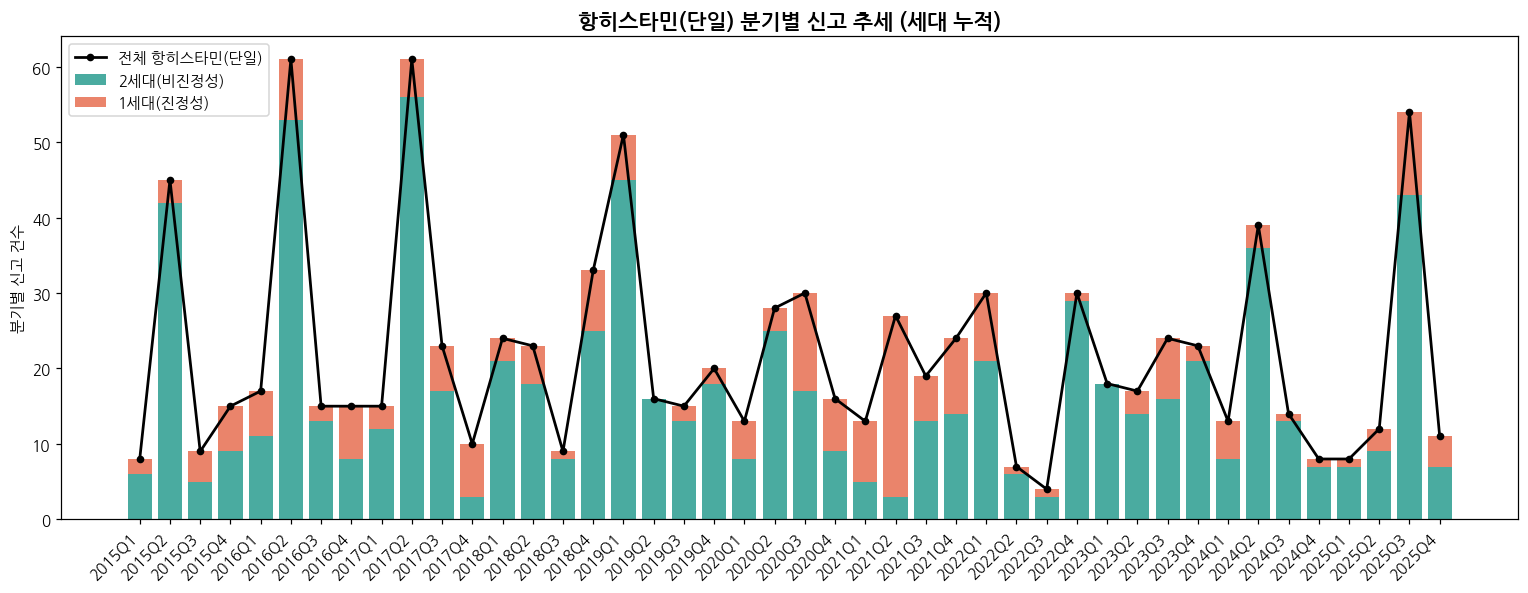

In [32]:
# ============================================================================
# 7. 항히스타민(단일) 시간 추세 (분기별 추이 · 세대별 · 계절성)
# ============================================================================

# (환경에 맞게 색상 변수가 없다면 사용할 기본값)
C_A = getattr(globals(), 'C_A', '#2A9D8F')
C_G1 = getattr(globals(), 'C_G1', '#E76F51')
C_G2 = getattr(globals(), 'C_G2', '#2A9D8F')
C_BASE = getattr(globals(), 'C_BASE', '#D3D3D3')

A_t = A.copy()
# df(전체 ATC)와 A_t(항히스타민) 모두 월(month) 데이터 추출
df['receive_date_dt'] = pd.to_datetime(df['receive_date'], errors='coerce')
df['month'] = df['receive_date_dt'].dt.month

A_t['receive_date_dt'] = pd.to_datetime(A_t['receive_date'], errors='coerce')
A_t['month'] = A_t['receive_date_dt'].dt.month
A_t['year']  = A_t['quarter'].str[:4].astype(float).fillna(0).astype(int)

q_order = sorted(A_t['quarter'].dropna().unique())
q_all = A_t['quarter'].value_counts().reindex(q_order).fillna(0)
q_g1  = A_t[A_t['서브'].str.contains('1세대', na=False)]['quarter'].value_counts().reindex(q_order).fillna(0)
q_g2  = A_t[A_t['서브'].str.contains('2세대', na=False)]['quarter'].value_counts().reindex(q_order).fillna(0)

# ----------------------------------------------------------------------------
# 7-1. 분기별 추세 (단독 그래프, x축 연도-분기 표시)
# ----------------------------------------------------------------------------
plt.figure(figsize=(14, 5.5))
xi = np.arange(len(q_order))
plt.bar(xi, q_g2.values, color=C_G2, label='2세대(비진정성)', alpha=0.85)
plt.bar(xi, q_g1.values, bottom=q_g2.values, color=C_G1, label='1세대(진정성)', alpha=0.85)
plt.plot(xi, q_all.values, color='black', lw=1.8, marker='o', ms=4, label='전체 항히스타민(단일)')

# x축에 q_order(연도+분기, 예: 2020Q1) 직접 표시
plt.xticks(xi, q_order, rotation=45, ha='right', fontsize=10)
plt.ylabel('분기별 신고 건수')
plt.legend(fontsize=10)
plt.title('항히스타민(단일) 분기별 신고 추세 (세대 누적)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


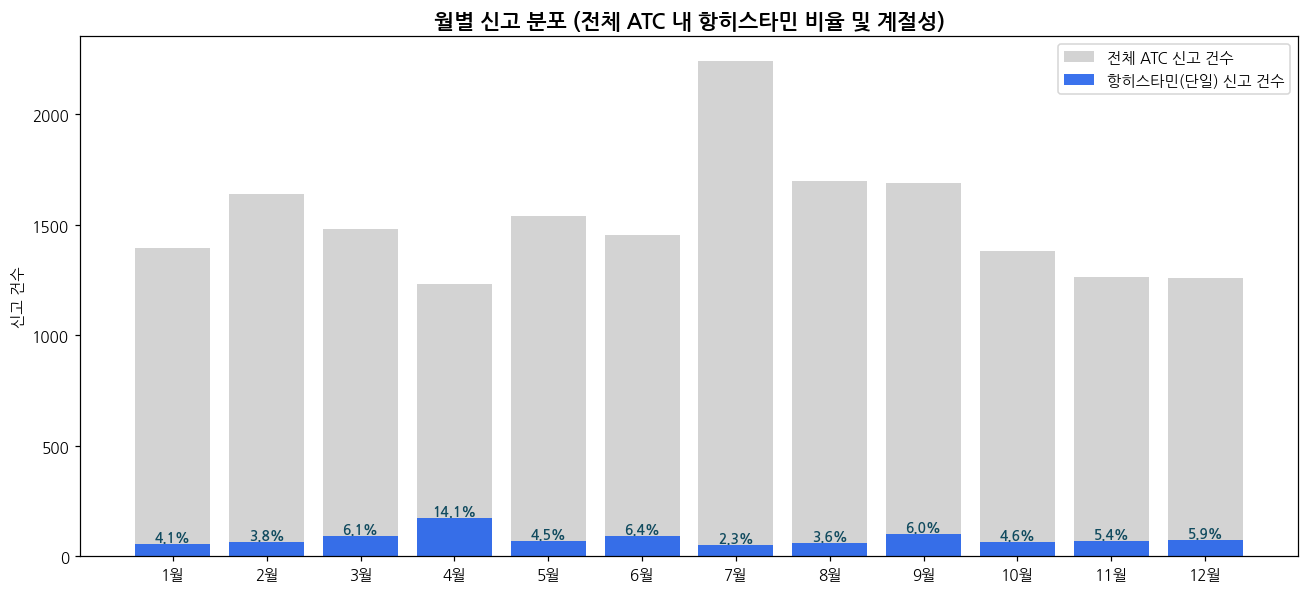

[시각화 및 통계 인사이트]
  - 분기 최다는 2016Q2(61건)이며, 2세대가 전반적 추세를 주도하고 있습니다.
  - 전체 ATC 신고 대비 항히스타민(단일) 비율이 가장 높은 달은 4월입니다. 이 비율을 통해 알레르기 계절성 편중을 뚜렷하게 확인할 수 있습니다.
  - (월 균등 기각, p=1.38e-26) 4월 전후로 신고가 집중되는 계절성이 통계적으로 유의미하게 나타납니다.



In [33]:

# ----------------------------------------------------------------------------
# 7-2. 월별 신고 분포 (단독 그래프, 전체 ATC 중 항히스타민 비율 표시)
# ----------------------------------------------------------------------------

plt.figure(figsize=(12, 5.5))
m_cnt = A_t['month'].value_counts().reindex(range(1, 13)).fillna(0)
m_cnt_all = df['month'].value_counts().reindex(range(1, 13)).fillna(0)

# 색상 지정
color_antihistamine = '#2563eb' # 변경된 파란색
color_base = C_BASE            # 기존 회색 유지

# 배경: 전체 ATC 월별 신고 건수 (회색)
plt.bar(range(1, 13), m_cnt_all.values, color=color_base, label='전체 ATC 신고 건수')
# 전경: 항히스타민(단일) 월별 신고 건수 (파란색)
plt.bar(range(1, 13), m_cnt.values, color=color_antihistamine, label='항히스타민(단일) 신고 건수', alpha=0.9)

for m, v_all, v_a in zip(range(1, 13), m_cnt_all.values, m_cnt.values):
    if v_all > 0:
        ratio = (v_a / v_all) * 100
        # 전체 중 비율(%)을 막대 위에 텍스트로 표시
        # 텍스트 색상도 파란색 계열에 맞춰 가독성 좋게 유지
        plt.text(m, v_a, f'{ratio:.1f}%', ha='center', va='bottom', fontsize=9, weight='bold', color='#114B5F')

plt.xticks(range(1, 13), [f'{i}월' for i in range(1, 13)])
plt.ylabel('신고 건수')
plt.title('월별 신고 분포 (전체 ATC 내 항히스타민 비율 및 계절성)', fontsize=14, weight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

peak_q = q_all.idxmax(); peak_m = int(m_cnt.idxmax())
chi2, p = chisquare(m_cnt.values)

print("[시각화 및 통계 인사이트]")
print(f"  - 분기 최다는 {peak_q}({int(q_all.max())}건)이며, 2세대가 전반적 추세를 주도하고 있습니다.")
print(f"  - 전체 ATC 신고 대비 항히스타민(단일) 비율이 가장 높은 달은 {peak_m}월입니다. 이 비율을 통해 알레르기 계절성 편중을 뚜렷하게 확인할 수 있습니다.")
if p < 0.05:
    print(f"  - (월 균등 기각, p={p:.2e}) {peak_m}월 전후로 신고가 집중되는 계절성이 통계적으로 유의미하게 나타납니다.\n")
else:
    print(f"  - (월 균등 기각 못함, p={p:.2e}) 뚜렷한 월별 편중이 통계적으로 유의하지 않습니다.\n")



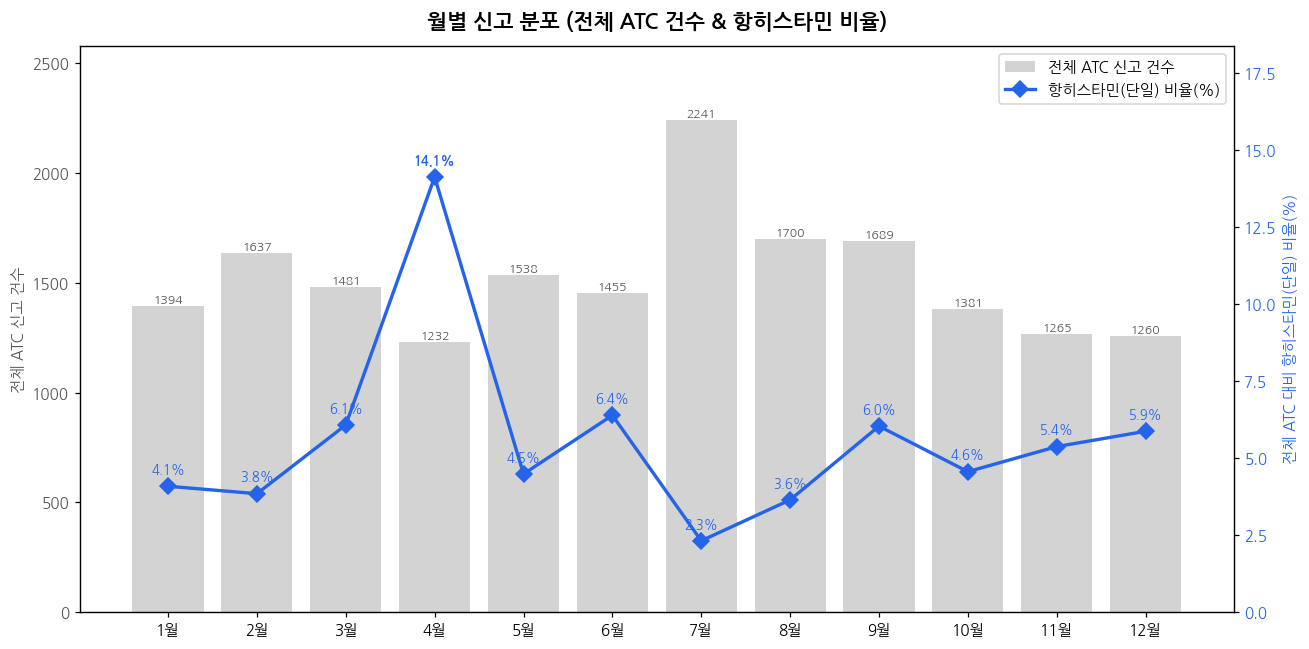

[시각화 및 통계 인사이트]
  - 회색 막대(왼쪽 축)는 그 달의 전체 ATC 신고 건수, 파란 꺾은선(오른쪽 축)은 그중 항히스타민(단일) 비율입니다.
  - 전체 ATC 신고 대비 항히스타민(단일) 비율이 가장 높은 달은 4월(14.1%)로,
    타 달(2.3~6.4%) 대비 두드러져 봄철 알레르기 계절성이 뚜렷합니다.
  - (월 균등 기각, p=1.38e-26) 4월 전후로 신고가 집중되는 계절성이 통계적으로 유의미합니다.
  ※ receive_date=FDA 접수일 기준이라 실제 복용·증상 시점과 시차 존재(신고 경향이며 발생률 아님).


In [34]:
# ----------------------------------------------------------------------------
# 7-2. 월별 신고 분포 (막대+꺾은선 이중축: 전체 ATC 건수 & 항히스타민 비율)
# ----------------------------------------------------------------------------

m_cnt     = A_t['month'].value_counts().reindex(range(1, 13)).fillna(0)   # 항히스타민(단일)
m_cnt_all = df['month'].value_counts().reindex(range(1, 13)).fillna(0)    # 전체 ATC
m_share   = (m_cnt / m_cnt_all * 100)                                      # 월별 항히스타민 비율

color_antihistamine = '#2563eb'   # 파란색 (비율 꺾은선)
color_base = C_BASE               # 회색 (전체 ATC 막대)

fig, ax1 = plt.subplots(figsize=(12, 6))
mx = np.arange(1, 13)

# 왼쪽 축: 전체 ATC 월별 신고 건수 (회색 막대) + 막대 위 숫자
ax1.bar(mx, m_cnt_all.values, color=color_base, label='전체 ATC 신고 건수')
for m, v in zip(mx, m_cnt_all.values):
    ax1.text(m, v, f'{int(v)}', ha='center', va='bottom', fontsize=8, color='#555555')
ax1.set_xticks(mx); ax1.set_xticklabels([f'{i}월' for i in mx])
ax1.set_ylabel('전체 ATC 신고 건수', color='#555555')
ax1.tick_params(axis='y', labelcolor='#555555')
ax1.set_ylim(0, m_cnt_all.max() * 1.15)

# 오른쪽 축: 항히스타민(단일) 비율(%) (파란색 꺾은선)
ax2 = ax1.twinx()
peak_m = int(m_share.idxmax())
ax2.plot(mx, m_share.values, color=color_antihistamine, lw=2.2, marker='D', ms=7,
         label='항히스타민(단일) 비율(%)')
for m, v in zip(mx, m_share.values):
    ax2.text(m, v + 0.3, f'{v:.1f}%', ha='center', va='bottom',
             fontsize=8.5, color=color_antihistamine,
             weight='bold' if m == peak_m else 'normal')
ax2.set_ylabel('전체 ATC 대비 항히스타민(단일) 비율(%)', color=color_antihistamine)
ax2.tick_params(axis='y', labelcolor=color_antihistamine)
ax2.set_ylim(0, m_share.max() * 1.3)

# 범례 통합
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=10)
plt.title('월별 신고 분포 (전체 ATC 건수 & 항히스타민 비율)', fontsize=14, weight='bold', pad=12)
plt.tight_layout()
plt.show()

peak_q = q_all.idxmax()
chi2, p = chisquare(m_cnt.values)

print("[시각화 및 통계 인사이트]")
print(f"  - 회색 막대(왼쪽 축)는 그 달의 전체 ATC 신고 건수, 파란 꺾은선(오른쪽 축)은 그중 항히스타민(단일) 비율입니다.")
print(f"  - 전체 ATC 신고 대비 항히스타민(단일) 비율이 가장 높은 달은 {peak_m}월({m_share[peak_m]:.1f}%)로,")
print(f"    타 달({m_share.drop(peak_m).min():.1f}~{m_share.drop(peak_m).max():.1f}%) 대비 두드러져 봄철 알레르기 계절성이 뚜렷합니다.")
if p < 0.05:
    print(f"  - (월 균등 기각, p={p:.2e}) {peak_m}월 전후로 신고가 집중되는 계절성이 통계적으로 유의미합니다.")
else:
    print(f"  - (월 균등 기각 못함, p={p:.2e}) 뚜렷한 월별 편중이 통계적으로 유의하지 않습니다.")
print("  ※ receive_date=FDA 접수일 기준이라 실제 복용·증상 시점과 시차 존재(신고 경향이며 발생률 아님).")

# **8. 국가 · 적응증 + 데이터 무결성 점검**

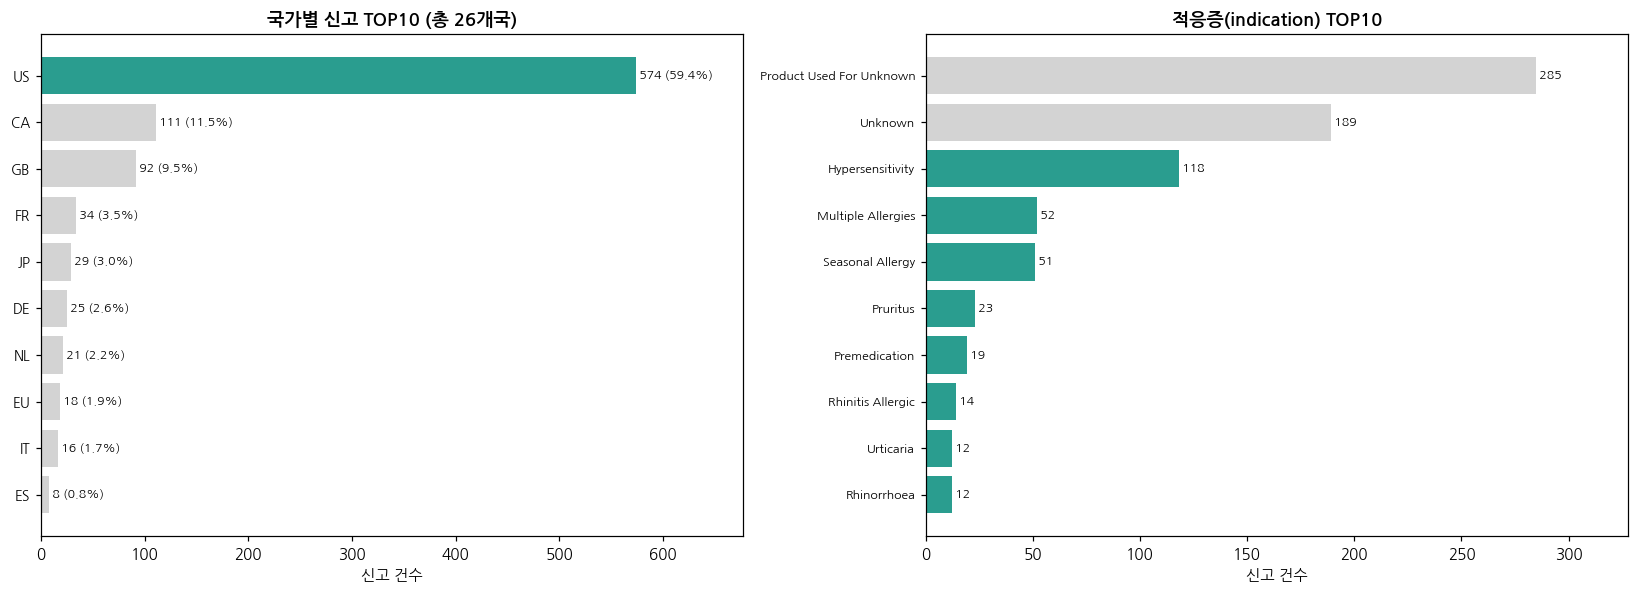

[시각화 인사이트]
  미국(US) 574건(59.4%)으로 압도적 → FAERS의 미국 중심 신고 구조 반영.
  적응증은 'Unknown'류가 큰 비중이나, 명시된 것 중엔 과민반응·다중알레르기·계절성알레르기가 상위.
  → 항히스타민(단일)이 실제 알레르기 목적으로 쓰였음이 적응증에서도 확인(라벨 용도와 일치).

[데이터 무결성 점검] 특정 반응이 한 국가·한 연도에 비정상 집중되는가
  Drug dependence            n= 10 | 국가 GB 70% | 연도 2017 50%
  Completed suicide          n= 17 | 국가 US 100% | 연도 2021 24%
  Drug abuse                 n= 13 | 국가 US 54% | 연도 2020 15%
  Toxicity to various agents n= 26 | 국가 US 54% | 연도 2025 31%

[검정 인사이트]
  특정 반응이 한 국가·연도에 비정상 집중된 뭉치는 없음 → 항히스타민(단일)은 이 축에서 데이터 건전.
  (타 그룹에서 관찰된 '단일 국가·연도 대량 동일뭉치' 아티팩트가 여기선 재현되지 않음.)
  ※ drug_route는 숫자 코드로 저장돼 의미 해독 불가 → 본 분석 제외. country는 신고 출처지 사용지 아님.


In [35]:
# ============================================================================
# 8. 항히스타민(단일) 국가 · 적응증(indication) 분포  [+ 데이터 무결성 점검]
#   [baseline 판정] 국가·적응증은 '신고 맥락' → 항히스타민(단일) 내부 분포 확인 목적.
#   [주의] drug_route는 원자료가 숫자 코드(48.0/65.0 등)로 저장돼 의미 해독 불가 → 제외.
#   [무결성] '특정 반응 = 특정 국가 = 특정 연도' 동일 뭉치(중복 적재) 여부 점검.
# ============================================================================

A_g = A.copy()
A_g['year'] = A_g['quarter'].str[:4].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (좌) 국가 TOP10 (US 강조)
ctry = A_g['country'].value_counts().head(10)
ccolors = [C_A if k == ctry.index[0] else C_BASE for k in ctry.index]
axes[0].barh(range(len(ctry)), ctry.values[::-1], color=ccolors[::-1])
axes[0].set_yticks(range(len(ctry)))
axes[0].set_yticklabels(ctry.index[::-1], fontsize=9)
for i, v in enumerate(ctry.values[::-1]):
    axes[0].text(v, i, f' {v} ({v/len(A)*100:.1f}%)', va='center', fontsize=8)
axes[0].set_xlabel('신고 건수'); axes[0].set_xlim(0, ctry.max()*1.18)
axes[0].set_title(f'국가별 신고 TOP10 (총 {A_g["country"].nunique()}개국)', fontsize=12, weight='bold')

# (우) 적응증 TOP10 (Unknown류 별도 색)
ind = A_g['drug_indication'].value_counts().head(10)
unknown_kw = ['Unknown', 'Product Used For Unknown Indication']
icolors = [C_BASE if k in unknown_kw else C_A for k in ind.index]
axes[1].barh(range(len(ind)), ind.values[::-1], color=icolors[::-1])
axes[1].set_yticks(range(len(ind)))
axes[1].set_yticklabels([k[:24] for k in ind.index[::-1]], fontsize=8)
for i, v in enumerate(ind.values[::-1]):
    axes[1].text(v, i, f' {v}', va='center', fontsize=8)
axes[1].set_xlabel('신고 건수'); axes[1].set_xlim(0, ind.max()*1.15)
axes[1].set_title('적응증(indication) TOP10', fontsize=12, weight='bold')
plt.tight_layout(); plt.show()

us_share = (A_g['country'] == 'US').mean() * 100
print("[시각화 인사이트]")
print(f"  미국(US) {int((A_g['country']=='US').sum())}건({us_share:.1f}%)으로 압도적 → FAERS의 미국 중심 신고 구조 반영.")
print(f"  적응증은 'Unknown'류가 큰 비중이나, 명시된 것 중엔 과민반응·다중알레르기·계절성알레르기가 상위.")
print(f"  → 항히스타민(단일)이 실제 알레르기 목적으로 쓰였음이 적응증에서도 확인(라벨 용도와 일치).")
print()

print("[데이터 무결성 점검] 특정 반응이 한 국가·한 연도에 비정상 집중되는가")
flag_found = False
for rx in ['Drug dependence', 'Completed suicide', 'Drug abuse', 'Toxicity to various agents']:
    sub = A_g[A_g['reactions'].fillna('').str.contains(rx, case=False, regex=False)]
    if len(sub) < 8:
        continue
    c_top = sub['country'].value_counts(); y_top = sub['year'].value_counts()
    c_conc = c_top.iloc[0]/len(sub)*100; y_conc = y_top.iloc[0]/len(sub)*100
    warn = ' ⚠집중' if (c_conc > 80 and y_conc > 60) else ''
    if warn: flag_found = True
    print(f"  {rx:<26} n={len(sub):>3} | 국가 {c_top.index[0]} {c_conc:.0f}% | 연도 {y_top.index[0]} {y_conc:.0f}%{warn}")
print()
print("[검정 인사이트]")
if flag_found:
    print("  ⚠ 한 국가·한 연도에 80%+ 몰린 반응 존재 → 중복 적재/일괄 신고 가능성. 해당 반응 해석 시 주의.")
else:
    print("  특정 반응이 한 국가·연도에 비정상 집중된 뭉치는 없음 → 항히스타민(단일)은 이 축에서 데이터 건전.")
    print("  (타 그룹에서 관찰된 '단일 국가·연도 대량 동일뭉치' 아티팩트가 여기선 재현되지 않음.)")
print("  ※ drug_route는 숫자 코드로 저장돼 의미 해독 불가 → 본 분석 제외. country는 신고 출처지 사용지 아님.")

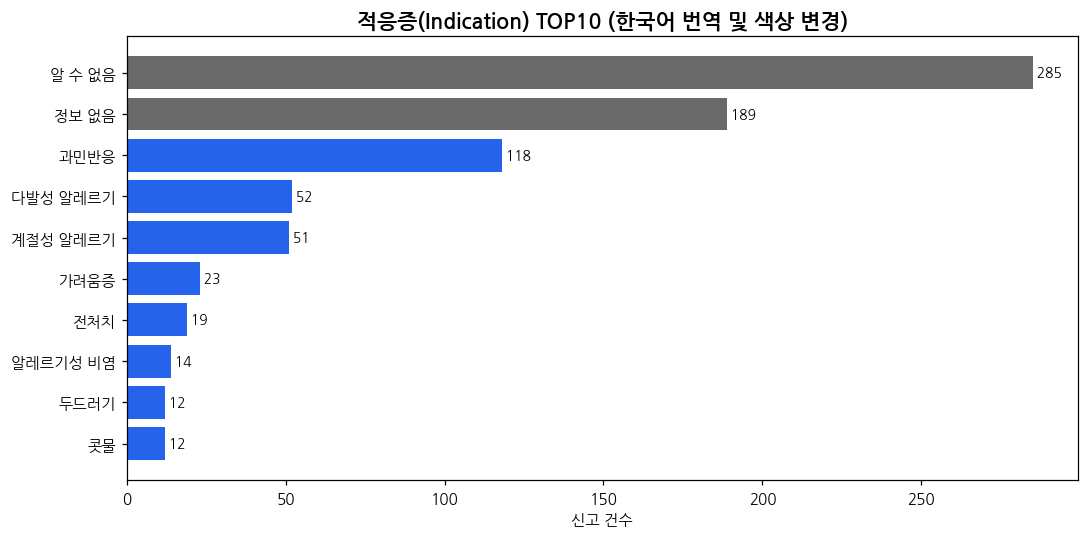

In [36]:
# ----------------------------------------------------------------------------
# 8-2. 적응증 TOP10
# ----------------------------------------------------------------------------

# 1. 색상 정의 (여기서 청록색을 파란색으로 변경)
Anything = '#2563eb'  # 파란색 계열
Nothing = '#696969'  # 기존 회색(정보 없음/알 수 없음용)

# 2. 적응증 매핑 및 데이터 처리
indication_mapping = {
    'Unknown': '정보 없음',
    'Product Used For Unknown Indication': '알 수 없음',
    'Allergy': '알레르기',
    'Seasonal allergy': '계절성 알레르기',
    'Hypersensitivity': '과민반응',
    'Rhinitis allergic': '알레르기성 비염',
    'Allergic rhinitis': '알레르기성 비염',
    'Urticaria': '두드러기',
    'Pruritus': '가려움증',
    'Drug hypersensitivity': '약물 과민반응',
    'Conjunctivitis allergic': '알레르기성 결막염',
    'Asthma': '천식',
    'Atopic dermatitis': '아토피 피부염',
    'Cold symptoms': '감기 증상',
    'Multiple allergies': '다발성 알레르기',
    'Premedication': '전처치',
    'Rhinorrhoea': '콧물'
}

# A는 기존 데이터프레임
A_mapped = A['drug_indication'].str.lower().replace({k.lower(): v for k, v in indication_mapping.items()})
ind_data = A_mapped.value_counts().head(10)

# 3. 그래프 생성
plt.figure(figsize=(10, 5))

# 색상 로직: '정보 없음' 또는 '알 수 없음'인 경우만 C_BASE, 나머지는 파란색(C_A) 적용
icolors = [Nothing if k in ['정보 없음', '알 수 없음'] else Anything for k in ind_data.index]

plt.barh(range(len(ind_data)), ind_data.values[::-1], color=icolors[::-1])
plt.yticks(range(len(ind_data)), ind_data.index[::-1], fontsize=10)

for i, v in enumerate(ind_data.values[::-1]):
    plt.text(v, i, f' {v}', va='center', fontsize=9)

plt.xlabel('신고 건수')
plt.title('적응증(Indication) TOP10 (한국어 번역 및 색상 변경)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

# **9. 인사이트 통합 요약**

In [37]:
# ============================================================================
# 9. 인사이트 통합 요약: 항히스타민(단일)
#   [목적] 셀 전체를 소비자 언어로 집약. 상단=한눈 스냅샷, 중단=소비자 행동카드,
#          하단=대시보드 통합용 1행 DataFrame(A·N·M·R·D 비교 최상단 카드).
#   [원칙] 모든 수치는 FAERS 신고 경향성(발생률·인과 아님). baseline=전체(항히스타민 제외).
# ============================================================================

# ── 핵심 수치 재계산 (앞 셀들과 동일 소스) ──
g1 = A[A['서브'].str.contains('1세대')]; g2 = A[A['서브'].str.contains('2세대')]
_rx = pd.Series(dict(explode_counter(A['reactions']))).sort_values(ascending=False)
_fA = (A['patient_sex']=='Female').sum(); _mA = (A['patient_sex']=='Male').sum()
g1_death = (g1['is_fatal']==True).mean()*100; g2_death = (g2['is_fatal']==True).mean()*100
g1_ser = (g1['serious']=='Yes').mean()*100;   g2_ser = (g2['serious']=='Yes').mean()*100
g1_poly = (g1['drug_count_category']=='Polypharmacy(6+)').mean()*100
share_total = len(A)/len(df)*100
share_R = len(A)/(df['WHO_ATC']=='R').sum()*100

# 반응 한글 설명(상위 반응 소비자 해설)
RX_EXPLAIN = {
    'Drug ineffective': '약을 먹어도 효과가 없다는 신고(부작용이 아니라 효과 불만족도 FAERS에 접수됨)',
    'Off label use': '허가된 용도와 다르게 사용했다는 기록',
    'Toxicity to various agents': '여러 약물에 의한 독성(과량·병용 맥락에서 자주 등장)',
    'Urticaria': '두드러기(피부 알레르기 반응)',
    'Somnolence': '졸림(특히 1세대 항히스타민의 대표 작용)',
    'Drug hypersensitivity': '약물 과민반응(알레르기성 반응)',
    'Nausea': '메스꺼움',
    'Dizziness': '어지러움',
}

# ══════════════════════════════════════════════════════════════════
print("="*70)
print("  9. 항히스타민(단일) 인사이트 통합 요약")
print("="*70)

# ── (A) 한눈 스냅샷 (소비자 문장) ──
print("\n【이 약이 무엇인가】")
print(f"  · 알레르기약(항히스타민) 단일성분 제품. 전체 부작용 신고 {len(df):,}건 중 {len(A)}건({share_total:.1f}%),")
print(f"    호흡기(R) 계열 안에서는 {share_R:.0f}%로 가장 많이 신고된 그룹.")
print(f"  · 성분은 {A['참조_영문성분명'].nunique()}종, 세티리진·펙소페나딘 2종이 약 60%.")

print("\n【가장 중요한 한 가지 — 세대에 따라 위험이 완전히 다름】")
print(f"  · '졸린 1세대'(디펜히드라민 등, {len(g1)}건) vs '덜 졸린 2세대'(세티리진 등, {len(g2)}건).")
print(f"  · 사망 신고 비율: 1세대 {g1_death:.0f}% vs 2세대 {g2_death:.0f}%  → 약 {g1_death/g2_death:.0f}배 차이.")
print(f"  · 심각(serious) 신고: 1세대 {g1_ser:.0f}% vs 2세대 {g2_ser:.0f}%.")
print(f"  · 즉, 위험은 항히스타민 전체가 아니라 사실상 '1세대'에 몰려 있음.")

print("\n【어떤 부작용이 보고되나 (상위 5개 + 뜻)】")
for r in _rx.head(5).index:
    exp = RX_EXPLAIN.get(r, '')
    print(f"  · {r} ({_rx[r]}건, {_rx[r]/len(A)*100:.0f}%){' — ' + exp if exp else ''}")

print("\n【누구에게 특히 관련 있나】")
print(f"  · 성별: 여성 신고가 {_fA/(_fA+_mA)*100:.0f}%로 많음(여성이 더 위험해서가 아니라 신고가 잦은 것).")
print(f"  · 나이: 중년(41-65)에서 가장 많이 신고. 계절: 봄철(4월)에 전체 대비 비중 급등(알레르기 성수기).")

# ── (B) 소비자 행동 카드 (근거→행동) ──
print("\n" + "-"*70)
print("  [소비자가 기억할 3가지 — 위 데이터에 근거한 실천 팁]")
print("-"*70)
print(f"  ① 졸음·위험이 걱정되면 '2세대'(세티리진·펙소페나딘·로라타딘)를 우선 고려.")
print(f"     (1세대는 사망 신고 {g1_death/g2_death:.0f}배·졸림·항콜린 작용)")
print(f"  ② 다른 약을 여러 개 함께 먹는 중이면 특히 주의 — 1세대 위험 신고의 {g1_poly:.0f}%가")
print(f"     '6종 이상 병용' 상황에서 나옴. 6종 이상 복용 시 약사·의사 상담 권장.")
print(f"  ③ '약효가 없다'는 신고가 최다({_rx.iloc[0]/len(A)*100:.0f}%)지만 이는 부작용이 아니라 효과 불만족.")
print(f"     실제 안전 경고는 1세대의 졸림·과량·독성 쪽에 집중.")

# ── (C) 성분별 핵심 안전 주의 (참조 라벨) ──
print("\n" + "-"*70)
print("  [상위 성분 안전 주의 — 제품 라벨 근거]")
print("-"*70)
CAUTION = {'최대용량':'참조_최대용량_기간제한', '절대금기':'참조_절대금기(do_not_use)',
           '임부/수유':'참조_임부_수유부_주의'}
_ref = A.drop_duplicates('참조_국문성분명').set_index('참조_국문성분명')
for ing in A['참조_국문성분명'].value_counts().head(3).index:
    if ing not in _ref.index: continue
    print(f"\n  ● {ing} ({(A['참조_국문성분명']==ing).sum()}건)")
    for short, col in CAUTION.items():
        val = str(_ref.loc[ing, col]).strip()
        if val and val.lower() != 'nan':
            print(f"      - {short}: {val[:75]}")

# ── (D) 한계 명시 (정직성) ──
print("\n" + "-"*70)
print("  [해석 시 반드시 유의]")
print("-"*70)
print("  · FAERS는 '자발적 신고' 자료 → 신고 많음 = 위험 큼 이 아님(사용량·신고성향 편향).")
print("  · 모든 수치는 '신고 경향'이며 실제 발생 확률·인과관계가 아님.")
print("  · 미국(US) 신고 60%+ 편중, 1세대·소아·청소년은 표본 작아 세부 비율 불안정.")

# ── (E) 대시보드 통합용 1행 DataFrame (A·N·M·R·D 비교) ──
summary_df = pd.DataFrame([{
    'ATC그룹':'항히스타민(단일)', '건수':len(A),
    '전체대비(%)':round(share_total,2), 'R내(%)':round(share_R,1),
    '성분수':A['참조_영문성분명'].nunique(), '1세대':len(g1), '2세대':len(g2),
    'serious(%)':round((A['serious']=='Yes').mean()*100,1),
    '사망(%)':round((A['is_fatal']==True).mean()*100,1),
    '회복(%)':round((A['patient_recovered']==True).mean()*100,1),
    '여성비(%)':round(_fA/(_fA+_mA)*100,1),
    '1세대사망(%)':round(g1_death,1), '2세대사망(%)':round(g2_death,1),
    '최다반응':_rx.index[0], '최다성분':A['참조_국문성분명'].value_counts().index[0],
    '신고기간':f"{A['quarter'].min()}~{A['quarter'].max()}",
}])
print("\n" + "="*70)
print("  [대시보드 통합용 DataFrame] — 5개 ATC 코드를 pd.concat으로 누적:")
print("="*70)
summary_df

  9. 항히스타민(단일) 인사이트 통합 요약

【이 약이 무엇인가】
  · 알레르기약(항히스타민) 단일성분 제품. 전체 부작용 신고 18,273건 중 967건(5.3%),
    호흡기(R) 계열 안에서는 62%로 가장 많이 신고된 그룹.
  · 성분은 9종, 세티리진·펙소페나딘 2종이 약 60%.

【가장 중요한 한 가지 — 세대에 따라 위험이 완전히 다름】
  · '졸린 1세대'(디펜히드라민 등, 216건) vs '덜 졸린 2세대'(세티리진 등, 751건).
  · 사망 신고 비율: 1세대 22% vs 2세대 3%  → 약 6배 차이.
  · 심각(serious) 신고: 1세대 73% vs 2세대 52%.
  · 즉, 위험은 항히스타민 전체가 아니라 사실상 '1세대'에 몰려 있음.

【어떤 부작용이 보고되나 (상위 5개 + 뜻)】
  · Drug ineffective (179건, 19%) — 약을 먹어도 효과가 없다는 신고(부작용이 아니라 효과 불만족도 FAERS에 접수됨)
  · Off label use (50건, 5%) — 허가된 용도와 다르게 사용했다는 기록
  · Somnolence (42건, 4%) — 졸림(특히 1세대 항히스타민의 대표 작용)
  · Insomnia (33건, 3%)
  · Headache (32건, 3%)

【누구에게 특히 관련 있나】
  · 성별: 여성 신고가 65%로 많음(여성이 더 위험해서가 아니라 신고가 잦은 것).
  · 나이: 중년(41-65)에서 가장 많이 신고. 계절: 봄철(4월)에 전체 대비 비중 급등(알레르기 성수기).

----------------------------------------------------------------------
  [소비자가 기억할 3가지 — 위 데이터에 근거한 실천 팁]
----------------------------------------------------------------------
  ① 졸음·위험이 걱정되면 '2세대'(세티리진·펙소페나딘·로라타딘)를 우선 

,ATC그룹,건수,전체대비(%),R내(%),성분수,1세대,2세대,serious(%),사망(%),회복(%),여성비(%),1세대사망(%),2세대사망(%),최다반응,최다성분,신고기간
0,항히스타민(단일),967,5.29,61.9,9,216,751,56.7,7.7,22.0,64.9,22.2,3.5,Drug ineffective,세티리진,2015Q1~2025Q4
